# Mechanistic Dynamic Interpretability for Tabular Foundation Models in Healthcare
## Myeloma Dialysis Case Study — Notebook

This notebook implements the full pipeline described in the paper:
**"Mechanistic Dynamic Interpretability for Tabular Foundation Models in Healthcare"**.

It covers: dataset preparation, Drift-Resilient TabPFN training, scalable embedding extraction,
unsupervised concept decomposition (Dictionary Learning & Sparse Autoencoders), decision-tree
rule extraction, TCAV with statistical significance testing, necessity/sufficiency ablations,
and temporal stability analysis.

## 1. Experimental Setup

### 1.1 Dataset (Myeloma) & Sampling

Imports, configuration, constants, helper functions, temporal splits,
patient selection, Monte Carlo sampling, and data validation.

In [1]:
from tqdm import tqdm
import pickle
import joblib
from scipy import stats
from scipy.stats import fisher_exact, spearmanr
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LassoCV, Lasso
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import DictionaryLearning
from torch.func import vmap, grad
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import torch
import os
import re
import time
import traceback
from dataclasses import dataclass, field
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.impute import SimpleImputer
from typing import Dict, Optional, Tuple

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ---------------- CONFIG ----------------
ROOT_DIR = Path.cwd()
ROOT_DIR_PARENT = ROOT_DIR.parent
DATA_PATH = "./free_light_chain_mortality.csv"
RESULTS_DIR = ROOT_DIR_PARENT / "tabpfn_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42
np.random.seed(RNG_SEED)

TARGET_POS_LINES = 5000
TARGET_NEG_LINES = 5000
DEFAULT_BATCH_SIZE_PREDICT = 512

# ---------------- HELPERS ----------------


def plot_bar_series(series, title="", xlabel="", ylabel="", figsize=(10, 4), rotate_xticks=False):
    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if rotate_xticks:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def build_pivot_preserve_presence(df_input, patients, years, events):
    """
    Pivot only for observed patient-year rows (no full reindex), counts of events in a year.
    Returns DataFrame indexed by (patient_id, year).
    """
    df_sub = df_input[
        df_input['patient_id'].isin(patients) &
        df_input['year'].isin(years) &
        df_input['event'].isin(events)
    ].copy()
    pivot = pd.pivot_table(
        df_sub,
        index=['patient_id', 'year'],
        columns='event',
        values='date',
        aggfunc='count',
        fill_value=0
    )
    pivot = pivot.astype(int)
    pivot = pivot.sort_index()
    return pivot


def build_pivot_for_events_fullreindex(df_input, patients, years, events):
    """
    pivot with full product reindex patient x years (In this case will be zeros in some rows).
    """
    df_sub = df_input[df_input['patient_id'].isin(patients) & df_input['year'].isin(
        years) & df_input['event'].isin(events)].copy()
    pivot = pd.pivot_table(
        df_sub,
        index=['patient_id', 'year'],
        columns='event',
        values='date',
        aggfunc='count',
        fill_value=0
    )
    full_index = pd.MultiIndex.from_product(
        [sorted(map(str, patients)), years], names=['patient_id', 'year'])
    pivot = pivot.reindex(full_index, fill_value=0).sort_index()
    return pivot


def trim_post_death_rows(pivot_df):
    """
    Remove rows patient-year where year > death_year for patients that died. Just to make sure
    """
    if 'DEATH' not in pivot_df.columns:
        return pivot_df.copy()
    death_rows = pivot_df[pivot_df['DEATH'] > 0].reset_index(
    )[['patient_id', 'year']].drop_duplicates()
    death_year_map = death_rows.groupby('patient_id')['year'].min().to_dict()
    idx = pivot_df.index.to_frame(index=False)
    mask_keep = []
    for _, r in idx.iterrows():
        pid = r['patient_id']
        yr = int(r['year'])
        dy = death_year_map.get(pid, None)
        if dy is not None and yr > dy:
            mask_keep.append(False)
        else:
            mask_keep.append(True)
    mask_keep = np.array(mask_keep, dtype=bool)
    return pivot_df.iloc[mask_keep].copy()


def select_equal_patients_with_line_cap(patients_df, target_pos_lines, target_neg_lines, rng_seed=RNG_SEED):
    """
    Select same number n of patients per class (pos/neg) attempting to respect line caps (sum of available years per class).
    Returns selected_pos, selected_neg, n_selected, pos_rows, neg_rows
    """
    pos_df = patients_df[patients_df['is_pos'] == True].copy()
    neg_df = patients_df[patients_df['is_pos'] == False].copy()

    pos_df = pos_df.sample(
        frac=1, random_state=rng_seed).reset_index(drop=True)
    neg_df = neg_df.sample(
        frac=1, random_state=rng_seed+1).reset_index(drop=True)

    pos_df['cum_rows'] = pos_df['n_avail_rows'].cumsum()
    neg_df['cum_rows'] = neg_df['n_avail_rows'].cumsum()

    max_n_possible = min(len(pos_df), len(neg_df))
    feasible_ns = []
    for n in range(1, max_n_possible+1):
        pos_rows = int(pos_df.loc[n-1, 'cum_rows'])
        neg_rows = int(neg_df.loc[n-1, 'cum_rows'])
        if pos_rows <= target_pos_lines and neg_rows <= target_neg_lines:
            feasible_ns.append((n, pos_rows, neg_rows))

    if feasible_ns:
        n_selected, pos_rows_sel, neg_rows_sel = feasible_ns[-1]
        selected_pos = pos_df['patient_id'].iloc[:n_selected].tolist()
        selected_neg = neg_df['patient_id'].iloc[:n_selected].tolist()
        return selected_pos, selected_neg, n_selected, pos_rows_sel, neg_rows_sel

    n_pos_max = int((pos_df['cum_rows'] <= target_pos_lines).sum())
    n_neg_max = int((neg_df['cum_rows'] <= target_neg_lines).sum())
    n_selected = min(n_pos_max, n_neg_max)
    if n_selected > 0:
        pos_rows_sel = int(pos_df.loc[n_selected-1, 'cum_rows'])
        neg_rows_sel = int(neg_df.loc[n_selected-1, 'cum_rows'])
        selected_pos = pos_df['patient_id'].iloc[:n_selected].tolist()
        selected_neg = neg_df['patient_id'].iloc[:n_selected].tolist()
        return selected_pos, selected_neg, n_selected, pos_rows_sel, neg_rows_sel

    pos_min = pos_df.sort_values('n_avail_rows').reset_index(drop=True)
    neg_min = neg_df.sort_values('n_avail_rows').reset_index(drop=True)
    if (not pos_min.empty) and (not neg_min.empty):
        p_row = int(pos_min.loc[0, 'n_avail_rows'])
        n_row = int(neg_min.loc[0, 'n_avail_rows'])
        if p_row <= target_pos_lines and n_row <= target_neg_lines:
            return [pos_min.loc[0, 'patient_id']], [neg_min.loc[0, 'patient_id']], 1, p_row, n_row

    return [], [], 0, 0, 0

In [2]:
df = pd.read_csv(DATA_PATH)
if 'sample.yr' in df.columns:
    df = df.rename(columns={'sample.yr': 'year'})

df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

In [3]:
feature_cols = []
for c in ['age','kappa','lambda','flc.grp','creatinine','mgus','futime']:
    if c in df.columns:
        feature_cols.append(c)

df_proc = df.copy()
if 'sex' in df_proc.columns:
    df_proc['sex_bin'] = df_proc['sex'].astype(str).str.upper().map({'F':0,'M':1})
    feature_cols = ['sex_bin'] + feature_cols

X_df = df_proc[feature_cols].copy()
y = df_proc['death'].fillna(0).astype(int).values  # ensure int 0/1

num_imputer = SimpleImputer(strategy='median')
X_df_imputed = pd.DataFrame(num_imputer.fit_transform(X_df), columns=X_df.columns, index=X_df.index)

print("Features used:", X_df_imputed.columns.tolist())
print("X shape:", X_df_imputed.shape, "y shape:", y.shape)
display(X_df_imputed.head())


Features used: ['sex_bin', 'age', 'kappa', 'lambda', 'flc.grp', 'creatinine', 'mgus', 'futime']
X shape: (7874, 8) y shape: (7874,)


,sex_bin,age,kappa,lambda,flc.grp,creatinine,mgus,futime
0,0.0,97.0,5.70,4.860,10.0,1.7,0.0,85.0
1,0.0,92.0,0.87,0.683,1.0,0.9,0.0,1281.0
2,0.0,94.0,4.36,3.850,10.0,1.4,0.0,69.0
3,0.0,92.0,2.42,2.220,9.0,1.0,0.0,115.0
4,0.0,93.0,1.32,1.690,6.0,1.1,0.0,1039.0


In [4]:
if 'year' not in df_proc.columns:
    raise RuntimeError("Column 'year' (sample.yr) not found in the dataframe.")

years_all = sorted(df_proc['year'].dropna().unique().astype(int))
print("Available years:", years_all)

TRAIN_YEAR_FRAC = 0.5
n_years = len(years_all)
n_train_years = max(1, int(math.floor(n_years * TRAIN_YEAR_FRAC)))
TRAIN_YEARS = years_all[:n_train_years]
TEST_YEARS = years_all[n_train_years:]
print("TRAIN_YEARS:", TRAIN_YEARS)
print("TEST_YEARS:", TEST_YEARS)

train_mask = df_proc['year'].notna() & df_proc['year'].astype(int).isin(TRAIN_YEARS)
test_mask = df_proc['year'].notna() & df_proc['year'].astype(int).isin(TEST_YEARS)

X_train_df = X_df_imputed.loc[train_mask].reset_index(drop=True)
y_train = y[train_mask.values]
years_train = df_proc.loc[train_mask, 'year'].astype(int).values

X_test_df = X_df_imputed.loc[test_mask].reset_index(drop=True)
y_test = y[test_mask.values]
years_test = df_proc.loc[test_mask, 'year'].astype(int).values

print("Train samples:", X_train_df.shape[0], "Test samples:", X_test_df.shape[0])
if X_train_df.shape[0] == 0 or X_test_df.shape[0] == 0:
    raise RuntimeError("Temporal split resulted in an empty set. Adjust TRAIN_YEAR_FRAC or check years in the dataset.")

combined_years = sorted(set(TRAIN_YEARS).union(set(TEST_YEARS)))
year_to_domain_combined = {y:i for i,y in enumerate(combined_years)}
print("year_to_domain_combined (sample):", list(year_to_domain_combined.items())[:10])

dist_shift_domain_train_np = np.array([year_to_domain_combined[int(y)] for y in years_train], dtype=np.int64)
dist_shift_domain_test_np = np.array([year_to_domain_combined[int(y)] for y in years_test], dtype=np.int64)

X_train_np = X_train_df.values.astype(np.float32)
X_test_np = X_test_df.values.astype(np.float32)

print("Shapes: X_train_np", X_train_np.shape, "X_test_np", X_test_np.shape)


Available years: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003]
TRAIN_YEARS: [1995, 1996, 1997, 1998]
TEST_YEARS: [1999, 2000, 2001, 2002, 2003]
Train samples: 6834 Test samples: 1040
year_to_domain_combined (sample): [(1995, 0), (1996, 1), (1997, 2), (1998, 3), (1999, 4), (2000, 5), (2001, 6), (2002, 7), (2003, 8)]
Shapes: X_train_np (6834, 8) X_test_np (1040, 8)


### 1.2 Model (Drift-Resilient TabPFN) & Metrics

Load and fit the Drift-Resilient TabPFN model (N\_ctx=128),
load test data, and configure evaluation metrics.

In [5]:
try:
    import tabpfn
    from tabpfn.scripts.estimator.base import TabPFNClassifier
    from tabpfn.best_models import get_best_tabpfn, TabPFNModelPathsConfig
    TABPFN_AVAILABLE = True
    print("✓ drift-resilient-tabpfn imported successfully with additional_x support")
except Exception as e:
    print(f"Failed to load drift-resilient TabPFN: {e!r}")
    TABPFN_AVAILABLE = False

# Configs
RNG_SEED = 42
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DEFAULT_BATCH_SIZE_PREDICT = 512


✓ drift-resilient-tabpfn imported successfully with additional_x support


In [6]:
run_id = "tabpfn_temporal_fit_free_light_chain"

drift_model = None
try:
    if TABPFN_AVAILABLE:
        try:
            libpath = Path(tabpfn.__file__).parents[0]
            model_path_config = TabPFNModelPathsConfig(
                paths=[f"{libpath}/model_cache/tabpfn_dist_model_1.cpkt"], task_type="dist_shift_multiclass")
            drift_model = get_best_tabpfn(task_type="dist_shift_multiclass", model_type="single_fast",
                                          paths_config=model_path_config, debug=False, device="auto")
            drift_model.show_progress = False
            drift_model.seed = RNG_SEED
            print(f"[{run_id}] Loaded via get_best_tabpfn.")
        except Exception as e:
            print(
                f"[{run_id}] Failed to load via get_best_tabpfn; using fallback TabPFNClassifier(device='auto').")
            print(f"[{run_id}] Exception (repr): {e!r}")
            traceback.print_exc()
            drift_model = TabPFNClassifier(device="auto")
            drift_model.show_progress = False
    else:
        raise ImportError("TabPFN not available.")
except Exception as e:
    print(f"[{run_id}] Main instantiation failed; trying fallback TabPFNClassifier.")
    print(f"[{run_id}] Exception (repr): {e!r}")
    traceback.print_exc()
    try:
        from tabpfn import TabPFNClassifier
        drift_model = TabPFNClassifier(device="auto")
        drift_model.show_progress = False
        print(f"[{run_id}] TabPFNClassifier instantiated via fallback.")
    except Exception as e2:
        print(f"[{run_id}] Fallback TabPFNClassifier also failed.")
        print(f"[{run_id}] Exception (repr): {e2!r}")
        traceback.print_exc()
        raise RuntimeError(
            "Could not instantiate TabPFN. Install tabpfn (full) or check your environment.") from e2

t0 = time.perf_counter()
print(f"[{run_id}] Fit starting: X_train shape = {X_train_np.shape}, y_train pos ratio = {float(y_train.mean()):.4f}")

# dist_shift_domain_train_np_with_ctx = np.array([year_to_domain_combined[int(y)]
#                                                 for y in years_train[ctx_idx]], dtype=np.int64)

drift_model = drift_model.fit(X_train_np, y_train, additional_x={
                              "dist_shift_domain": dist_shift_domain_train_np})
t_fit = time.perf_counter() - t0
print(f"[{run_id}] Fit completed in {t_fit:.2f}s.")

model_add_x_device = torch.device("cpu")
example_add_shape = None
try:
    if hasattr(drift_model, 'additional_x_') and drift_model.additional_x_ is not None and 'dist_shift_domain' in drift_model.additional_x_:
        v = drift_model.additional_x_['dist_shift_domain']
        if isinstance(v, torch.Tensor):
            model_add_x_device = v.device
            example_add_shape = tuple(v.shape)
        else:
            example_add_shape = np.asarray(v).shape
except Exception:
    model_add_x_device = torch.device("cpu")
    example_add_shape = None

print("additional_x_ device (inferred):", model_add_x_device,
      "example_add_shape:", example_add_shape)


[tabpfn_temporal_fit_free_light_chain] Loaded via get_best_tabpfn.
[tabpfn_temporal_fit_free_light_chain] Fit starting: X_train shape = (6834, 8), y_train pos ratio = 0.2927
Initialized decoder for standard with (None, 10)  and nout 10
[tabpfn_temporal_fit_free_light_chain] Fit completed in 0.13s.
additional_x_ device (inferred): cpu example_add_shape: (6834, 1, 1)


## 2. Methodology

### 2.1 Temporal Domain Generalization (Walk-Forward)

Strict temporal splits with walk-forward per-year evaluation.
Domain indicators are used for Drift-Resilient TabPFN.

Inference completed in 475.99s (total)

Global metrics (test):
Accuracy: 0.9067
Precision (macro): 0.8306, Recall (macro): 0.8227, F1 (macro): 0.8266
Precision (pos): 0.7195, Recall (pos): 0.6982, F1 (pos): 0.7087

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       871
           1       0.72      0.70      0.71       169

    accuracy                           0.91      1040
   macro avg       0.83      0.82      0.83      1040
weighted avg       0.91      0.91      0.91      1040

ROC AUC (pos class): 0.921908436877968


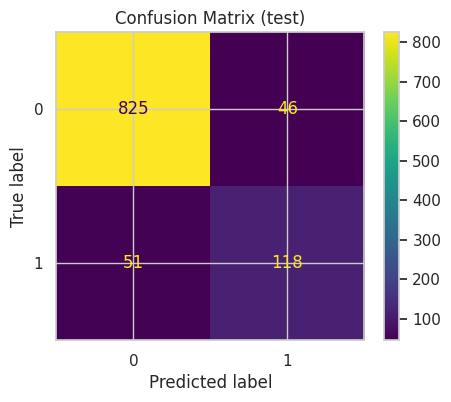

In [7]:
def make_dist_tensor(dist_np, device, target_shape_example=None):
    t = torch.tensor(dist_np, dtype=torch.long, device=device)
    if target_shape_example is not None and t.ndim == 1:
        if len(target_shape_example) >= 3:
            t = t.reshape(-1, 1, 1)
    else:
        if t.ndim == 1:
            t = t.reshape(-1, 1, 1)
    return t


# Batch predict
batch_size = DEFAULT_BATCH_SIZE_PREDICT
n_samples = X_test_np.shape[0]
preds_proba_list = []

t0 = time.perf_counter()
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    Xb_np = X_test_np[start:end].astype(np.float32)
    dist_dom_np = dist_shift_domain_test_np[start:end]

    try:
        dist_dom_t = make_dist_tensor(
            dist_dom_np, device=model_add_x_device, target_shape_example=example_add_shape)
    except Exception:
        # fallback to CPU
        dist_dom_t = make_dist_tensor(dist_dom_np, device=torch.device(
            "cpu"), target_shape_example=example_add_shape)

    try:
        if getattr(model_add_x_device, "type", "cpu") == "cpu":
            preds_proba_batch = drift_model.predict_proba(
                Xb_np, additional_x={"dist_shift_domain": dist_dom_t})
        else:
            Xb_t = torch.tensor(Xb_np, dtype=torch.float32,
                                device=model_add_x_device)
            with torch.no_grad():
                preds_proba_batch = drift_model.predict_proba(
                    Xb_t, additional_x={"dist_shift_domain": dist_dom_t})
    except Exception as e:
        # fallback: try passing numpy + numpy dist (accepted by some versions)
        try:
            preds_proba_batch = drift_model.predict_proba(
                Xb_np, additional_x={"dist_shift_domain": dist_dom_np})
        except Exception as e2:
            raise RuntimeError(
                f"predict_proba failed for batch {start}:{end}: {e} | {e2}")

    if isinstance(preds_proba_batch, torch.Tensor):
        preds_proba_batch = preds_proba_batch.detach().cpu().numpy()
    preds_proba_list.append(np.asarray(preds_proba_batch))

t_infer = time.perf_counter() - t0
probs_all = np.vstack(preds_proba_list)
# if output is multiclass (n, n_classes), pick prob of class 1 as positive probability
if probs_all.ndim == 2 and probs_all.shape[1] > 1:
    probs_pos = probs_all[:, 1]
else:
    probs_pos = probs_all.ravel()

# Binary predictions with threshold 0.5
y_pred = (probs_pos >= 0.5).astype(int)

# Global metrics
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec_pos = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec_pos = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_pos = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

print("Inference completed in {:.2f}s (total)".format(t_infer))
print("\nGlobal metrics (test):")
print(f"Accuracy: {acc:.4f}")
print(
    f"Precision (macro): {prec_macro:.4f}, Recall (macro): {rec_macro:.4f}, F1 (macro): {f1_macro:.4f}")
print(
    f"Precision (pos): {prec_pos:.4f}, Recall (pos): {rec_pos:.4f}, F1 (pos): {f1_pos:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# ROC AUC (if possible)
try:
    auc = roc_auc_score(y_test, probs_pos)
    print("ROC AUC (pos class):", auc)
except Exception:
    print("ROC AUC not computable (possibly invalid output variable or classes).")

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax)
plt.title("Confusion Matrix (test)")
plt.show()


,year,n_samples,n_deaths,accuracy,precision_macro,recall_macro,f1_macro,precision_pos,recall_pos,f1_pos,auc
0,1999,350,67,0.908571,0.860571,0.835241,0.847028,0.786885,0.716418,0.750000,0.956648
1,2000,245,52,0.865306,0.799323,0.795088,0.797170,0.686275,0.673077,0.679612,0.898565
2,2001,175,38,0.925714,0.900000,0.876489,0.887493,0.857143,0.789474,0.821918,0.943911
3,2002,48,1,0.916667,0.600000,0.957447,0.644444,0.200000,1.000000,0.333333,1.000000
4,2003,222,11,0.932432,0.650000,0.662861,0.656098,0.333333,0.363636,0.347826,0.934080


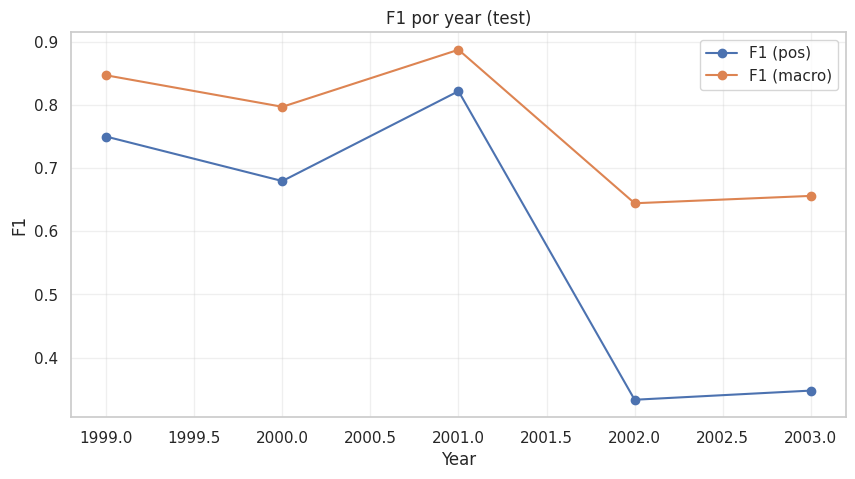

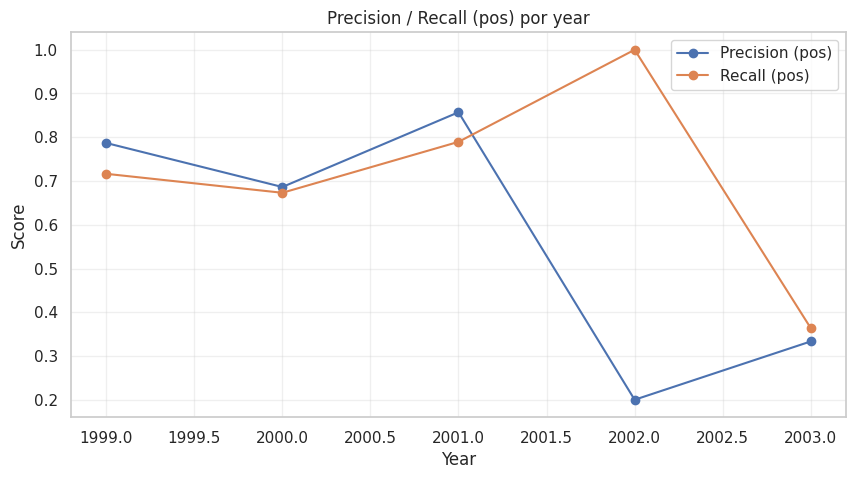

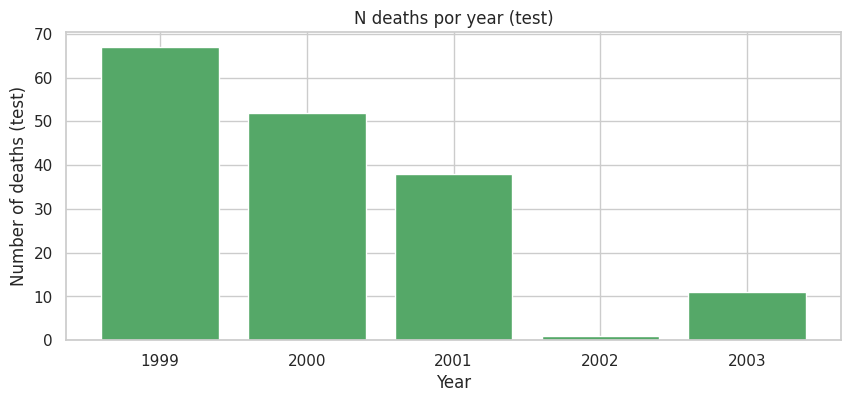

In [8]:
results_by_year = []
unique_test_years = sorted(np.unique(years_test))
for yr in unique_test_years:
    idx = np.where(years_test == yr)[0]
    if len(idx) == 0:
        continue
    y_true_yr = y_test[idx]
    y_pred_yr = y_pred[idx]
    probs_yr = probs_pos[idx]
    n_samples = len(idx)
    n_deaths = int(y_true_yr.sum())
    acc_yr = accuracy_score(y_true_yr, y_pred_yr)
    prec_macro_yr = precision_score(y_true_yr, y_pred_yr, average='macro', zero_division=0)
    rec_macro_yr = recall_score(y_true_yr, y_pred_yr, average='macro', zero_division=0)
    f1_macro_yr = f1_score(y_true_yr, y_pred_yr, average='macro', zero_division=0)
    prec_pos_yr = precision_score(y_true_yr, y_pred_yr, pos_label=1, zero_division=0)
    rec_pos_yr = recall_score(y_true_yr, y_pred_yr, pos_label=1, zero_division=0)
    f1_pos_yr = f1_score(y_true_yr, y_pred_yr, pos_label=1, zero_division=0)
    try:
        auc_yr = roc_auc_score(y_true_yr, probs_yr) if len(np.unique(y_true_yr))>1 else None
    except Exception:
        auc_yr = None

    results_by_year.append({
        "year": int(yr),
        "n_samples": int(n_samples),
        "n_deaths": int(n_deaths),
        "accuracy": float(acc_yr),
        "precision_macro": float(prec_macro_yr),
        "recall_macro": float(rec_macro_yr),
        "f1_macro": float(f1_macro_yr),
        "precision_pos": float(prec_pos_yr),
        "recall_pos": float(rec_pos_yr),
        "f1_pos": float(f1_pos_yr),
        "auc": float(auc_yr) if auc_yr is not None else None
    })

res_df = pd.DataFrame(results_by_year).sort_values('year').reset_index(drop=True)
display(res_df)

# Plots
plt.figure(figsize=(10,5))
plt.plot(res_df['year'], res_df['f1_pos'], marker='o', label='F1 (pos)')
plt.plot(res_df['year'], res_df['f1_macro'], marker='o', label='F1 (macro)')
plt.xlabel('Year')
plt.ylabel('F1')
plt.title('F1 por year (test)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision/Recall pos over years
plt.figure(figsize=(10,5))
plt.plot(res_df['year'], res_df['precision_pos'], marker='o', label='Precision (pos)')
plt.plot(res_df['year'], res_df['recall_pos'], marker='o', label='Recall (pos)')
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('Precision / Recall (pos) por year')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bar: n_deaths por ano
plt.figure(figsize=(10,4))
plt.bar(res_df['year'].astype(str), res_df['n_deaths'], color='C2')
plt.xlabel('Year')
plt.ylabel('Number of deaths (test)')
plt.title('N deaths por year (test)')
plt.show()

### 2.2 Scalable Embedding Extraction

Batch/out-of-core embedding extraction, y-token selection and flattening,
StandardScaler fit on train only, and split into concept-discovery / CAV / TCAV / held-out sets.

In [9]:
scaler = StandardScaler()
# scaler = RobustScaler()

scaler.fit(X_train_df)

X_train_df_norm = pd.DataFrame(scaler.transform(X_train_df), columns=X_train_df.columns, index=X_train_df.index)
X_test_df_norm = pd.DataFrame(scaler.transform(X_test_df), columns=X_test_df.columns, index=X_test_df.index)

X_train_np_norm = X_train_df_norm.values.astype(np.float32)
X_test_np_norm = X_test_df_norm.values.astype(np.float32)

print("Normalization complete.")
print("X_train_df_norm shape:", X_train_df_norm.shape)
print("X_test_df_norm shape:", X_test_df_norm.shape)

OUT_DIR = Path.cwd() / "tabpfn_free_light_chain_results"
OUT_DIR.mkdir(exist_ok=True)
joblib.dump(scaler, OUT_DIR / "scaler_standard.pkl")
print("Scaler salvo em:", OUT_DIR / "scaler_standard.pkl")


Normalization complete.
X_train_df_norm shape: (6834, 8)
X_test_df_norm shape: (1040, 8)
Scaler salvo em: /home/rafael-martins-gomes/Desktop/others/TCAV/tabpfn_free_light_chain_results/scaler_standard.pkl


In [10]:
# Embedding extraction parameters
MAX_EXTRACT = None   # int or None: max samples to extract (None = all)
BATCH_EMB = 512      # batch size for embedding extraction

def batch_get_embeddings_via_get_embeddings(model, X_all: np.ndarray, dist_full: np.ndarray, batch_size: int = 512):
    """Extract embeddings in batches via model.get_embeddings(). Returns (np.ndarray, list[Tensor])."""
    out_list = []
    tensors_list = []
    n = X_all.shape[0]
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        Xb = X_all[s:e].astype(np.float32)
        dist_b = dist_full[s:e].astype(np.int64)
        # Build domain-shift tensor (try helper, fall back to CPU reshape)
        try:
            dist_t = make_dist_tensor(dist_b, device=model_add_x_device, target_shape_example=example_add_shape)
        except (NameError, RuntimeError):
            dist_t = torch.tensor(dist_b, dtype=torch.long, device=torch.device("cpu")).reshape(-1,1,1)
        try:
            emb_b = model.get_embeddings(Xb, additional_x={"dist_shift_domain": dist_t})
        except (TypeError, RuntimeError):
            emb_b = model.get_embeddings(Xb)
        if isinstance(emb_b, torch.Tensor):
            emb_b_np = emb_b.detach().cpu().numpy()
        emb_t = emb_b.detach().clone().requires_grad_(True)

        out_list.append(np.asarray(emb_b_np))
        tensors_list.append(emb_t)
    return np.vstack(out_list), tensors_list

def extract_embeddings_robust(model, X: np.ndarray, years: np.ndarray, year_to_domain_map: dict, max_samples=None, batch_size=512, is_train=False, ctx_idx=None):
    """Extract embeddings from model, with optional sample cap and context exclusion. Returns np.ndarray (n_samples, emb_dim)."""
    X_all = np.asarray(X, dtype=np.float32)
    if max_samples is not None:
        X_all = X_all[:max_samples]
        years = np.asarray(years, dtype=int)[:max_samples]

    if is_train and ctx_idx is not None:
        exclude_mask = np.ones(X_all.shape[0], dtype=bool)
        exclude_mask[ctx_idx] = False
        X_all = X_all[exclude_mask]
        years = years[exclude_mask]

    dist_vec = np.array([year_to_domain_map[int(y)]
                        for y in years], dtype=np.int64)
    if hasattr(model, "get_embeddings"):
        try:
            print("Using model.get_embeddings (batch mode).")
            emb, _ = batch_get_embeddings_via_get_embeddings(model, X_all, dist_vec, batch_size=batch_size)
            print("Embeddings extracted via get_embeddings, shape:", emb.shape)
            return np.asarray(emb)
        except RuntimeError as e:
            print("get_embeddings failed:", repr(e))

    raise RuntimeError("Could not extract embeddings: neither get_embeddings nor model_processed_._forward available.")

def flatten_embeddings(arr):
    """Flatten 3-D embedding array to 2-D (n_samples, emb_dim)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr.reshape(-1,1)
    if arr.ndim == 2:
        return arr
    if arr.shape[1] == 1:
        squeezed = np.squeeze(arr, axis=1)
        if squeezed.ndim == 2:
            return squeezed
        return squeezed.reshape(squeezed.shape[0], -1)
    return arr.reshape(arr.shape[0], -1)

In [11]:
RESULTS_DIR = Path.cwd() / "tabpfn_temporal_v4_results"
RESULTS_DIR.mkdir(exist_ok=True)

EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(exist_ok=True)

In [12]:
embeddings_path_train = Path(EMBEDDINGS_DIR) / "train_emb.npy"
embeddings_path_train_flat = Path(EMBEDDINGS_DIR) / "train_emb_flat.npy"
embeddings_path_test = Path(EMBEDDINGS_DIR) / "test_emb.npy"
embeddings_path_test_flat = Path(EMBEDDINGS_DIR) / "test_emb_flat.npy"

if embeddings_path_train.exists() and embeddings_path_test.exists() and \
   embeddings_path_train_flat.exists() and embeddings_path_test_flat.exists():
    print("Loading saved embeddings from:", EMBEDDINGS_DIR)
    train_emb = np.load(embeddings_path_train)
    test_emb = np.load(embeddings_path_test)
    train_emb_flat = np.load(embeddings_path_train_flat)
    test_emb_flat = np.load(embeddings_path_test_flat)

    print("train_emb shape:", train_emb.shape)
    print("test_emb shape:", test_emb.shape)
    print("train_emb_flat shape:", train_emb_flat.shape)
    print("test_emb_flat shape:", test_emb_flat.shape)
else:
    print("Extracting embeddings from the training set...")
    train_emb = extract_embeddings_robust(
        drift_model,
        X_train_np,
        years_train,
        year_to_domain_combined,
        max_samples=MAX_EXTRACT,
        batch_size=BATCH_EMB,
        is_train=True,
        ctx_idx=None
    )

    print("Extracting embeddings from the test set...")
    test_emb = extract_embeddings_robust(
        drift_model,
        X_test_np,
        years_test,
        year_to_domain_combined,
        max_samples=MAX_EXTRACT,
        batch_size=BATCH_EMB,
        is_train=False,
        ctx_idx=None
    )

    # flatten_embeddings() is defined in cell 18.
    train_emb_flat = flatten_embeddings(train_emb)
    test_emb_flat = flatten_embeddings(test_emb)

    print("train_emb_flat shape:", train_emb_flat.shape)
    print("test_emb_flat shape:", test_emb_flat.shape)


Extracting embeddings from the training set...
Using model.get_embeddings (batch mode).
Embeddings extracted via get_embeddings, shape: (6834, 1, 192)
Extracting embeddings from the test set...
Using model.get_embeddings (batch mode).
Embeddings extracted via get_embeddings, shape: (1040, 1, 192)
train_emb_flat shape: (6834, 192)
test_emb_flat shape: (1040, 192)


In [13]:
print("Checking for existing embeddings and activations...")

# Define file paths for all embeddings and activations
files_to_save = {
    "train_emb": EMBEDDINGS_DIR / "train_emb.npy",
    "test_emb": EMBEDDINGS_DIR / "test_emb.npy",
    "train_emb_flat": EMBEDDINGS_DIR / "train_emb_flat.npy",
    "test_emb_flat": EMBEDDINGS_DIR / "test_emb_flat.npy"
}
metadata_path = EMBEDDINGS_DIR / "embeddings_metadata.pkl"

# Check if all files exist
all_files_exist = all(p.exists()
                      for p in files_to_save.values()) and metadata_path.exists()

if all_files_exist:  # Set to True to skip saving if files exist
    print("✓ All embeddings and activations already saved. Skipping save operation.")
    for name, path in files_to_save.items():
        print(f"  Found: {path}")
    print(f"  Found: {metadata_path}")
else:
    print("Embeddings/activations not found or incomplete. Saving now...")

    # Save all embeddings and activations
    saved_shapes = {}
    for var_name, file_path in files_to_save.items():
        if var_name in globals() and globals()[var_name] is not None:
            data = globals()[var_name]
            np.save(file_path, data)
            saved_shapes[var_name] = data.shape
            print(f"✓ Saved {file_path.name}, shape: {data.shape}")
        else:
            print(f"⚠ Warning: {var_name} not found in globals, skipping.")

    # Save comprehensive metadata
    metadata = {
        "train_indices": np.arange(len(train_emb_flat)),
        "test_indices": np.arange(len(test_emb_flat)),
        "year_to_domain_combined": year_to_domain_combined,
        "shapes": saved_shapes,
        "extraction_params": {
            "MAX_EXTRACT": globals().get('MAX_EXTRACT', None),
            "BATCH_EMB": globals().get('BATCH_EMB', 512),
            "CONTEXT_SIZE": globals().get('CONTEXT_SIZE', 100)
        }
    }

    with open(metadata_path, "wb") as f:
        pickle.dump(metadata, f)
    print(f"✓ Saved embeddings_metadata.pkl")

    print(f"\n✓ All embeddings and activations saved to {EMBEDDINGS_DIR}")

Checking for existing embeddings and activations...
Embeddings/activations not found or incomplete. Saving now...
✓ Saved train_emb.npy, shape: (6834, 1, 192)
✓ Saved test_emb.npy, shape: (1040, 1, 192)
✓ Saved train_emb_flat.npy, shape: (6834, 192)
✓ Saved test_emb_flat.npy, shape: (1040, 192)
✓ Saved embeddings_metadata.pkl

✓ All embeddings and activations saved to /home/rafael-martins-gomes/Desktop/others/TCAV/tabpfn_temporal_v4_results/embeddings


In [14]:
scaler_emb = StandardScaler()
train_emb_flat_norm = scaler_emb.fit_transform(train_emb_flat)
test_emb_flat_norm = scaler_emb.transform(test_emb_flat)

print(f"Normalized embeddings: train shape {train_emb_flat_norm.shape}, test shape {test_emb_flat_norm.shape}")
globals().update({
  "scaler_emb": scaler_emb,
  "train_emb_flat_norm": train_emb_flat_norm,
  "test_emb_flat_norm": test_emb_flat_norm
})


Normalized embeddings: train shape (6834, 192), test shape (1040, 192)


**Split Structure (Test Data):**
| Split | Purpose | Approx % |
|-------|---------|----------|
| Discovery | Dictionary Learning / SAE factor discovery | 33% |
| CAV Train | Train CAV classifiers | 33% |
| TCAV Eval | Compute TCAV scores | 17% |
| Held-Out | Statistical tests & later analysis | 17% |

In [15]:
# Get test labels
n_test = len(y_test)

# All test indices
all_test_idx = np.arange(n_test)

# First split: Discovery (33%) vs Rest (67%)
idx_test_discover, idx_test_rest = train_test_split(
    all_test_idx,
    test_size=0.67,
    random_state=42,
    stratify=y_test
)

# Second split: CAV Train (50% of rest = 33% of total) vs Eval+HeldOut (50% of rest)
idx_test_cav_train, idx_test_eval_and_held = train_test_split(
    idx_test_rest,
    test_size=0.5,
    random_state=42,
    stratify=y_test[idx_test_rest]
)

# Third split: TCAV Eval (50% = ~17% of total) vs Held-Out (50% = ~17% of total)
idx_test_tcav_eval, idx_test_held_out = train_test_split(
    idx_test_eval_and_held,
    test_size=0.5,
    random_state=42,
    stratify=y_test[idx_test_eval_and_held]
)

# Verify no overlap between splits
assert len(set(idx_test_discover) & set(idx_test_cav_train)) == 0, "Discovery overlaps with CAV Train!"
assert len(set(idx_test_discover) & set(idx_test_tcav_eval)) == 0, "Discovery overlaps with TCAV Eval!"
assert len(set(idx_test_discover) & set(idx_test_held_out)) == 0, "Discovery overlaps with Held-Out!"
assert len(set(idx_test_cav_train) & set(idx_test_tcav_eval)) == 0, "CAV Train overlaps with TCAV Eval!"
assert len(set(idx_test_cav_train) & set(idx_test_held_out)) == 0, "CAV Train overlaps with Held-Out!"
assert len(set(idx_test_tcav_eval) & set(idx_test_held_out)) == 0, "TCAV Eval overlaps with Held-Out!"

# Get labels for each split
y_test_discover = y_test[idx_test_discover]
y_test_cav_train = y_test[idx_test_cav_train]
y_test_tcav_eval = y_test[idx_test_tcav_eval]
y_test_held_out = y_test[idx_test_held_out]

print("=" * 70)
print("NEW DATA PIPELINE: Test Data Splits (Training as Context Only)")
print("=" * 70)
print(f"\n✓ Training data: {len(y_train)} samples → Used SOLELY as context for TabPFN")
print(f"\n✓ Test data splits:")
print(f"  - Discovery Set:  {len(idx_test_discover):5d} samples ({len(idx_test_discover)/n_test*100:.1f}%) - Deaths: {y_test_discover.sum()}")
print(f"  - CAV Train Set:  {len(idx_test_cav_train):5d} samples ({len(idx_test_cav_train)/n_test*100:.1f}%) - Deaths: {y_test_cav_train.sum()}")
print(f"  - TCAV Eval Set:  {len(idx_test_tcav_eval):5d} samples ({len(idx_test_tcav_eval)/n_test*100:.1f}%) - Deaths: {y_test_tcav_eval.sum()}")
print(f"  - Held-Out Set:   {len(idx_test_held_out):5d} samples ({len(idx_test_held_out)/n_test*100:.1f}%) - Deaths: {y_test_held_out.sum()}")
print(f"\n✓ Total test used: {len(idx_test_discover) + len(idx_test_cav_train) + len(idx_test_tcav_eval) + len(idx_test_held_out)}")
print(f"✓ Total test available: {n_test}")

# Store in globals for downstream use
globals().update({
    "idx_test_discover": idx_test_discover,
    "idx_test_cav_train": idx_test_cav_train,
    "idx_test_tcav_eval": idx_test_tcav_eval,
    "idx_test_held_out": idx_test_held_out,
    "y_test_discover": y_test_discover,
    "y_test_cav_train": y_test_cav_train,
    "y_test_tcav_eval": y_test_tcav_eval,
    "y_test_held_out": y_test_held_out,
    "y_test": y_test
})

NEW DATA PIPELINE: Test Data Splits (Training as Context Only)

✓ Training data: 6834 samples → Used SOLELY as context for TabPFN

✓ Test data splits:
  - Discovery Set:    343 samples (33.0%) - Deaths: 56
  - CAV Train Set:    348 samples (33.5%) - Deaths: 56
  - TCAV Eval Set:    174 samples (16.7%) - Deaths: 28
  - Held-Out Set:     175 samples (16.8%) - Deaths: 29

✓ Total test used: 1040
✓ Total test available: 1040


In [16]:
years_test_discover = years_test[idx_test_discover]
years_test_cav_train = years_test[idx_test_cav_train]
years_test_tcav_eval = years_test[idx_test_tcav_eval]
years_test_held_out = years_test[idx_test_held_out]

print("Years extracted for test splits:")
print(
    f"  Discovery: years {int(years_test_discover.min())} - {int(years_test_discover.max())}")
print(
    f"  CAV Train: years {int(years_test_cav_train.min())} - {int(years_test_cav_train.max())}")
print(
    f"  TCAV Eval: years {int(years_test_tcav_eval.min())} - {int(years_test_tcav_eval.max())}")
print(
    f"  Held-Out:  years {int(years_test_held_out.min())} - {int(years_test_held_out.max())}")

Years extracted for test splits:
  Discovery: years 1999 - 2003
  CAV Train: years 1999 - 2003
  TCAV Eval: years 1999 - 2003
  Held-Out:  years 1999 - 2003


### 2.3 Concept Decomposition (DL vs SAE)

Dictionary Learning baseline and Sparse Autoencoder (tied weights, expansion factor 1.5 → 288,
sparsity penalty). Decomposition quality metrics: MSE, sparsity, active/sample, orthogonality.

In [17]:
N_FACTORS = 8

dict_learning_path = Path(RESULTS_DIR) / f"dict_learning_test_info_{N_FACTORS}.pkl"
dict_learning_train_info = {}

if dict_learning_path.exists():
    print("Loading dictionary learning info from:", dict_learning_path)
    with open(dict_learning_path, "rb") as f:
        dict_learning_train_info = pickle.load(f)
else:
    print("=" * 70)
    print("DICTIONARY LEARNING ON TEST EMBEDDINGS (New Protocol)")
    print("=" * 70)
    print("\nUsing TEST data for factor discovery and CAV training...")

    dict_learning_train_info = {}

    embeddings_test_norm = test_emb_flat_norm  # Normalized test embeddings

    # Get discovery and CAV train embeddings from TEST data
    embeddings_discovery = embeddings_test_norm[idx_test_discover]
    embeddings_cav_train = embeddings_test_norm[idx_test_cav_train]

    print(f"\n✓ Discovery embeddings shape: {embeddings_discovery.shape}")
    print(f"✓ CAV train embeddings shape: {embeddings_cav_train.shape}")

    # Dictionary Learning on discovery set
    dict_learner = DictionaryLearning(
        n_components=N_FACTORS,
        transform_algorithm='lasso_lars',
        random_state=42,
        max_iter=1000
    )

    print("\nFitting Dictionary Learning on discovery set...")
    activations_discovery_train = dict_learner.fit_transform(embeddings_discovery)
    W_latent = dict_learner.components_.T  # (emb_dim, n_factors)

    # Transform CAV train set
    activations_cav_train = dict_learner.transform(embeddings_cav_train)

    dict_learning_train_info = {
        "embeddings_discovery": embeddings_discovery,
        "embeddings_cav_train": embeddings_cav_train,
        "activations_discovery_train": activations_discovery_train,
        "W_latent": W_latent,
        "activations_cav_train": activations_cav_train,
        "dict_learner": dict_learner  # Save for transforming eval set later
    }

    print(f"\n✓ Dictionary W_latent shape: {W_latent.shape}")
    print(f"✓ Activations (discovery): {activations_discovery_train.shape}")
    print(f"✓ Activations (CAV train): {activations_cav_train.shape}")

    # Save results to disk
    with open(dict_learning_path, "wb") as f:
        pickle.dump(dict_learning_train_info, f)
    print(f"\n✓ Dictionary learning complete and saved to {dict_learning_path}")

globals().update({"dict_learning_train_info": dict_learning_train_info})

DICTIONARY LEARNING ON TEST EMBEDDINGS (New Protocol)

Using TEST data for factor discovery and CAV training...

✓ Discovery embeddings shape: (343, 192)
✓ CAV train embeddings shape: (348, 192)

Fitting Dictionary Learning on discovery set...

✓ Dictionary W_latent shape: (192, 8)
✓ Activations (discovery): (343, 8)
✓ Activations (CAV train): (348, 8)

✓ Dictionary learning complete and saved to /home/rafael-martins-gomes/Desktop/others/TCAV/tabpfn_temporal_v4_results/dict_learning_test_info_8.pkl


In [18]:
# torch, nn, optim, F are imported in cell 5.

class SparseAutoencoderTied(nn.Module):
    def __init__(self, emb_dim, n_factors, alpha_sparse=1e-3, use_decoder_bias=False):
        super().__init__()
        self.encoder = nn.Linear(emb_dim, n_factors, bias=True)
        self.activation = nn.ReLU()

        if use_decoder_bias:
            self.decoder_bias = nn.Parameter(torch.zeros(emb_dim))
        else:
            self.decoder_bias = None
        self.alpha_sparse = alpha_sparse

    def forward(self, x):
        code = self.activation(self.encoder(x))
        recon = F.linear(code, self.encoder.weight.t(), bias=self.decoder_bias)
        return recon, code

    def loss(self, x, recon, code):
        mse = F.mse_loss(recon, x)
        l1 = self.alpha_sparse * code.abs().mean()
        return mse + l1


train_emb_discovery = dict_learning_train_info["embeddings_discovery"]
emb_dim = train_emb_discovery.shape[1]

In [19]:
train_emb_discovery = dict_learning_train_info["embeddings_discovery"]
emb_dim = train_emb_discovery.shape[1]
n_factors = int(192 * 1.5)
SAE_PT_MODEL_PATH = os.path.join(RESULTS_DIR, "sparse_autoencoder_model_state_dict.pt")
print("=" * 70)
print("SPARSE AUTOENCODER ON TEST DISCOVERY EMBEDDINGS")
print("=" * 70)
print(f"\nTraining SAE on {train_emb_discovery.shape[0]} test samples")
print(f"Embedding dim: {emb_dim}, SAE factors: {n_factors}")

model_sae = SparseAutoencoderTied(emb_dim, n_factors, alpha_sparse=1e-1)
optimizer = optim.Adam(model_sae.parameters(), lr=1e-3)
X_np = train_emb_discovery.astype(np.float32)
X_torch = torch.tensor(X_np)

if os.path.exists(SAE_PT_MODEL_PATH):
    print("Loading SAE model state dict from:", SAE_PT_MODEL_PATH)
    model_sae.load_state_dict(torch.load(SAE_PT_MODEL_PATH))
    model_sae.eval()
else:
    for epoch in range(1000):
        optimizer.zero_grad()
        recon, code = model_sae(X_torch)
        loss = model_sae.loss(X_torch, recon, code)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 50 == 0:
            with torch.no_grad():
                temp_codes = model_sae.activation(model_sae.encoder(X_torch)).numpy()
                temp_sparsity = (temp_codes <= 1e-5).mean()
            print(f"Epoch {epoch+1}, loss={loss.item():.4f}, sparsity={temp_sparsity:.2%}")

with torch.no_grad():
    codes_train = model_sae.activation(model_sae.encoder(X_torch)).numpy()  # (n_samples, n_factors)
    decoder_atoms = model_sae.encoder.weight.t().detach().cpu().numpy()  # (n_factors, emb_dim)

print(f"\n✓ SAE training complete")
print(f"  Activations shape: {codes_train.shape}")
print(f"  Decoder atoms shape: {decoder_atoms.shape}")

# Measure actual sparsity achieved
sparsity_level = (codes_train <= 1e-5).mean()
print(f"\n✓ Sparsity metrics:")
print(f"  Near-zero activations: {sparsity_level:.2%}")
print(f"  Active neurons per sample: {(codes_train > 1e-5).sum(axis=1).mean():.1f} / {n_factors}")
print(f"  Mean absolute activation: {np.abs(codes_train).mean():.4f}")
print(f"  Max activation: {codes_train.max():.4f}")

# Store in globals
globals().update({
    "codes_train_sae": codes_train,
    "decoder_atoms_sae": decoder_atoms,
    "model_sae": model_sae
})

SPARSE AUTOENCODER ON TEST DISCOVERY EMBEDDINGS

Training SAE on 343 test samples
Embedding dim: 192, SAE factors: 288
Epoch 50, loss=0.1000, sparsity=48.26%
Epoch 100, loss=0.0787, sparsity=51.33%
Epoch 150, loss=0.0683, sparsity=57.10%
Epoch 200, loss=0.0599, sparsity=62.72%
Epoch 250, loss=0.0531, sparsity=68.62%
Epoch 300, loss=0.0480, sparsity=73.44%
Epoch 350, loss=0.0441, sparsity=76.82%
Epoch 400, loss=0.0409, sparsity=79.75%
Epoch 450, loss=0.0382, sparsity=82.05%
Epoch 500, loss=0.0359, sparsity=83.87%
Epoch 550, loss=0.0337, sparsity=85.37%
Epoch 600, loss=0.0316, sparsity=86.24%
Epoch 650, loss=0.0295, sparsity=87.11%
Epoch 700, loss=0.0278, sparsity=87.87%
Epoch 750, loss=0.0262, sparsity=88.67%
Epoch 800, loss=0.0250, sparsity=89.38%
Epoch 850, loss=0.0240, sparsity=89.98%
Epoch 900, loss=0.0230, sparsity=90.42%
Epoch 950, loss=0.0221, sparsity=90.84%
Epoch 1000, loss=0.0214, sparsity=91.25%

✓ SAE training complete
  Activations shape: (343, 288)
  Decoder atoms shape: (

In [20]:
ANALYSIS_SOURCE = "dl"  # or "sae"
def get_concept_activations(embeddings):
    if ANALYSIS_SOURCE == "dl":
        dict_learner_temp = dict_learning_train_info["dict_learner"]
        A_latent = dict_learner_temp.transform(embeddings)
        return A_latent

    return model_sae.activation(model_sae.encoder(torch.tensor(embeddings, dtype=torch.float32, device="cpu"))).detach().numpy()

### 2.4 Rule Extraction (Decision Trees)

Thresholding at percentile of positive activation mass, decision tree fitting,
precision/recall filtering, and extracted rules table.

In [21]:
def tree_rules_to_df(tree, feature_names):
    tree_text = export_text(
        tree,
        feature_names=feature_names,
        max_depth=tree.get_depth()
    )

    rules = []
    path = []

    for line in tree_text.split("\n"):
        if not line.strip():
            continue

        # depth = number of "|   " blocks
        depth = line.count("|   ")

        if "class:" in line:
            classe = line.split("class:")[1].strip()
            rules.append({
                "Path": " AND ".join(path),
                "Class": classe
            })
        else:
            # extract condition
            condition = line.split("|--- ")[-1].strip()

            # keep path aligned with depth
            path = path[:depth]
            path.append(condition)

    return pd.DataFrame(rules),tree_text

In [22]:
train_embeddings_cav_train = dict_learning_train_info["embeddings_cav_train"]

# Separate CAV split into decision tree training and actual CAV training
print("\nSplitting CAV train embeddings into DT train and CAV train sets...")
n_cav_train = train_embeddings_cav_train.shape[0]
split_ratio = 0.5

n_dt_train = int(n_cav_train * split_ratio)
n_cav_final_train = n_cav_train - n_dt_train

idx_dt_train = np.random.choice(n_cav_train, size=n_dt_train, replace=False)
idx_cav_final_train = np.setdiff1d(np.arange(n_cav_train), idx_dt_train)
train_embeddings_cav_dt_train = train_embeddings_cav_train[idx_dt_train]
train_embeddings_cav_final_train = train_embeddings_cav_train[idx_cav_final_train]
y_cav_dt_train = y_test_cav_train[idx_dt_train]
y_cav_final_train = y_test_cav_train[idx_cav_final_train]

# Transform through SAE encoder to get activations
X_torch_dt = torch.tensor(train_embeddings_cav_dt_train.astype(np.float32))
X_torch_cav = torch.tensor(train_embeddings_cav_final_train.astype(np.float32))
with torch.no_grad():
    codes_dt_train_sae = model_sae.activation(model_sae.encoder(X_torch_dt)).numpy()
    codes_cav_train_sae = model_sae.activation(model_sae.encoder(X_torch_cav)).numpy()


Splitting CAV train embeddings into DT train and CAV train sets...


In [23]:
X_feat_dt_train = X_test_df.iloc[idx_test_cav_train].iloc[idx_dt_train][feature_cols].values
p = [90, 80, 70, 60, 50]
rules_per_percentile = {perc: [] for perc in p}
thresholds_per_p = {perc: {k: [] for k in range(n_factors)} for perc in p}

for k in range(n_factors):
    for perc in p:
        scores = codes_dt_train_sae[:,k]
        non_zero = scores[scores > 0]
        if len(non_zero) == 0:
            print(f"Skipping factor {k}, no non-zero activations")
            continue
        threshold = np.percentile(non_zero, perc)
        thresholds_per_p[perc][k].append(threshold)

        idx_pos = np.where(scores >= threshold)[0]
        y_high = np.zeros_like(scores, dtype=int)
        y_high[idx_pos] = 1

        if(y_high.sum() < 50):
            idx_pos = np.where(scores > 0)[0]
            y_high = np.zeros_like(scores, dtype=int)
            y_high[idx_pos] = 1
            if(y_high.sum() < 50):
                print(f"Skipping factor {k}, insufficient positive samples ({y_high.sum()})")
                continue

        tree = DecisionTreeClassifier(max_depth=15, min_samples_leaf=0.01, random_state=42)
        tree.fit(X_feat_dt_train, y_high)
        y_pred = tree.predict(X_feat_dt_train)

        total_positives = (y_high == 1).sum()
        if total_positives == 0:
            continue

        leaf_ids = tree.apply(X_feat_dt_train)
        purity = []
        for l in np.unique(leaf_ids):
            mask = leaf_ids == l
            proportion = max(np.mean(y_high[mask]), 1 - np.mean(y_high[mask]))
            purity.append(proportion)
        mean_leaf_purity = np.mean(purity)

        rules_df, tree_text = tree_rules_to_df(tree, list(feature_cols))

        importances = tree.feature_importances_
        top_features = np.argsort(importances)[-10:][::-1]

        best_rule = None
        best_recall = 0.0
        best_prec = None
        for _, row in rules_df.iterrows():
            path = row['Path']

            # Create a mask for samples that follow this path
            mask = np.ones(X_feat_dt_train.shape[0], dtype=bool)

            conditions = path.split(' AND ')
            for cond in conditions:
                cond = cond.strip()

                if '<=' in cond:
                    feat, thresh = cond.split(' <= ')
                    feat_idx = feature_cols.index(feat)
                    mask &= (X_feat_dt_train[:, feat_idx] <= float(thresh))

                elif '>' in cond:
                    feat, thresh = cond.split(' > ')
                    feat_idx = feature_cols.index(feat)
                    mask &= (X_feat_dt_train[:, feat_idx] > float(thresh))

            if mask.sum() > 0:
                tp_covered = ((y_high == 1) & mask).sum()
                rule_recall = tp_covered / total_positives
                rule_precision = y_high[mask].mean()

                if rule_precision < 0.9 or rule_recall < 0.25:
                    continue

                if rule_recall > best_recall:
                    best_recall = rule_recall
                    best_prec = rule_precision
                    best_rule = row

        if best_rule is not None:
            print(f"Best rule for factor {k} at percentile {p}:")
            print(f"  Path: {best_rule['Path']}")
            print(f"  Class: {best_rule['Class']}")
            print(f"  Precision: {best_prec:.3f}, Recall: {best_recall:.3f}")

            rules_per_percentile[perc].append({
                "Factor": k,
                "Path": best_rule['Path'],
                "Class": best_rule['Class'],
                "Top_features": [(feature_cols[i], importances[i]) for i in top_features],
                "Precision": best_prec,
                "Recall": best_recall
            })

Skipping factor 0, insufficient positive samples (1)
Skipping factor 0, insufficient positive samples (1)
Skipping factor 0, insufficient positive samples (1)
Skipping factor 0, insufficient positive samples (1)
Skipping factor 0, insufficient positive samples (1)
Best rule for factor 1 at percentile [90, 80, 70, 60, 50]:
  Path: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07
  Class: 1
  Precision: 1.000, Recall: 0.264
Best rule for factor 1 at percentile [90, 80, 70, 60, 50]:
  Path: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07
  Class: 1
  Precision: 1.000, Recall: 0.264
Best rule for factor 1 at percentile [90, 80, 70, 60, 50]:
  Path: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07
  Class: 1
  Precision: 1.000, Recall: 0.264
Best rule for factor 1 at percentile [90, 80, 70, 60, 50]:
  Path: futime <= 1908.50
  Class: 1
  Precision: 1.000, Recall: 0.554
Best rule for factor 1 at percentile [90, 80, 70, 60, 50]:
  Path: futime <= 2066.00 AND futime <= 1908.50
  Class: 

In [24]:
([len(rules_per_percentile[perc]) for perc in p])

[28, 28, 28, 26, 25]

In [25]:
# Extracted Decision Tree Rules (Table 2 Source)
best_p = max(rules_per_percentile.keys(), key=lambda p: len(rules_per_percentile[p]))
print(f"\n✅ Extracted {len(rules_per_percentile[best_p])} rules at percentile {best_p}:")

display(pd.DataFrame(rules_per_percentile[best_p]))


✅ Extracted 28 rules at percentile 90:


,Factor,Path,Class,Top_features,Precision,Recall
0,1,kappa <= 1.47 AND lambda <= 2.17 AND kappa <= ...,1,"[(futime, 0.4012203997997587), (kappa, 0.20743...",1.000000,0.264286
1,21,futime > 646.00 AND age > 52.50 AND lambda >...,1,"[(futime, 0.347991302251919), (age, 0.26177993...",1.000000,0.620438
2,26,lambda > 1.44 AND futime > 2052.50 AND age <...,1,"[(lambda, 0.31985490508250186), (age, 0.195784...",1.000000,0.388889
3,34,age > 59.50 AND futime <= 3727.00 AND flc.grp...,1,"[(age, 0.3612296524046603), (futime, 0.2901823...",1.000000,0.268908
4,40,futime > 2992.50 AND lambda > 1.61,1,"[(futime, 0.29409605774627195), (age, 0.195400...",1.000000,0.290598
5,84,age <= 54.50 AND futime > 447.00 AND lambda >...,1,"[(age, 0.35169660160853894), (futime, 0.252028...",1.000000,0.436975
6,93,creatinine > 1.05 AND sex_bin > 0.50,1,"[(lambda, 0.29032027444437036), (futime, 0.246...",1.000000,0.324324
7,98,sex_bin <= 0.50 AND kappa <= 1.65 AND lambda >...,1,"[(futime, 0.42368872039671196), (lambda, 0.234...",1.000000,0.391304
8,117,futime <= 2876.00 AND kappa <= 3.41 AND age <=...,1,"[(futime, 0.5235162842533287), (kappa, 0.27334...",1.000000,0.458333
9,160,age <= 56.50 AND lambda <= 2.30,1,"[(age, 0.6198133703065404), (futime, 0.1694256...",1.000000,0.631579


### 2.5 TCAV + Statistical Significance

Multiple random negatives (N=15), null distribution (random vs. random),
t-test + BH/FDR correction, effect-size filtering around 0.5.

In [26]:
# CAV parameters
PURE_QUANTILE = 0.05  # top/bottom q%
MIN_PURE = 10
NEGATIVE_MULT = 1  # balanced by label

print("=" * 70)
print("CAV TRAINING ON TEST DATA (Dictionary Learning Factors)")
print("=" * 70)

cav_dict_activ = {}
rng = np.random.default_rng(42)

X_cav_train = dict_learning_train_info["embeddings_cav_train"].astype(np.float32)
A = dict_learning_train_info["activations_cav_train"]  # (n_samples, n_factors)
n_samples, n_factors_dl = A.shape

y_cav = np.asarray(y_test_cav_train)

assert X_cav_train.shape[0] == A.shape[0] == y_cav.shape[0], (
    f"Shape mismatch: X={X_cav_train.shape[0]}, A={A.shape[0]}, y={y_cav.shape[0]}"
)

print(f"  CAV train samples: {n_samples}")
print(f"  Number of factors: {n_factors_dl}")
print(f"  Death rate in CAV train: {y_cav.mean():.2%}")

def sample_label_balanced(pool_idx, y, target_counts, rng):
    chosen = []
    pool_idx = np.asarray(pool_idx)
    for label, count in target_counts.items():
        candidates = pool_idx[y[pool_idx] == label]
        if len(candidates) >= count:
            chosen.append(rng.choice(candidates, size=count, replace=False))
        else:
            chosen.append(candidates)
    if len(chosen) == 0:
        return np.array([], dtype=int)
    chosen = np.concatenate(chosen)
    total_needed = int(sum(target_counts.values()))
    if chosen.size < total_needed:
        remaining = np.setdiff1d(pool_idx, chosen)
        if remaining.size > 0:
            extra_n = min(total_needed - chosen.size, remaining.size)
            chosen = np.concatenate([chosen, rng.choice(remaining, size=extra_n, replace=False)])
    return chosen

# Collect all CAV vectors
cav_vectors_list = []

for k in tqdm(range(n_factors_dl), desc="Training CAVs (factors)", leave=False):
    scores = A[:, k]
    high_thr = np.quantile(scores, 1.0 - PURE_QUANTILE)
    low_thr = np.quantile(scores, PURE_QUANTILE)
    idx_pos = np.where(scores >= high_thr)[0]
    idx_neg_pool = np.where(scores <= low_thr)[0]

    if idx_pos.size < MIN_PURE or idx_neg_pool.size < MIN_PURE:
        continue

    # Label-balanced negative sampling
    labels, counts = np.unique(y_cav[idx_pos], return_counts=True)
    target_counts = {lab: int(cnt) for lab, cnt in zip(labels, counts)}
    idx_neg = sample_label_balanced(idx_neg_pool, y_cav, target_counts, rng)

    # Fallback if pool insufficient
    if idx_neg.size < sum(target_counts.values()):
        remaining_pool = np.setdiff1d(np.arange(n_samples), idx_pos)
        idx_neg = sample_label_balanced(remaining_pool, y_cav, target_counts, rng)

    if idx_neg.size == 0:
        continue

    Xc = np.vstack([X_cav_train[idx_pos], X_cav_train[idx_neg]])
    yc = np.hstack([np.ones(len(idx_pos), dtype=int), np.zeros(len(idx_neg), dtype=int)])

    clf = LogisticRegression(
        C=0.1, solver="liblinear", penalty="l2",
        class_weight="balanced", max_iter=5000, random_state=42
    )
    clf.fit(Xc, yc)

    w = clf.coef_.ravel()
    scaler = scaler_emb
    if hasattr(scaler, "scale_"):
        v_original = w / scaler.scale_
    else:
        v_original = w
    nrm = np.linalg.norm(v_original)
    if nrm == 0:
        continue
    v_activ = (v_original / nrm).astype(np.float32)

    cav_vectors_list.append(v_activ)

    cav_dict_activ[int(k)] = {
        "factor": int(k),
        "size_pos": int(len(idx_pos)),
        "pos_idx": idx_pos,
        "neg_idx": idx_neg,
        "clf": clf,
        "v_activ": v_activ,
        "high_thr": float(high_thr),
        "low_thr": float(low_thr)
    }

# Stack all vectors into matrix
if len(cav_vectors_list) > 0:
    cav_vectors_matrix = np.column_stack(cav_vectors_list)
    cav_dict_activ["cav_vectors_matrix"] = cav_vectors_matrix
    print(f"  CAV vectors matrix shape: {cav_vectors_matrix.shape} (emb_dim, n_factors)")

print(f"  Total CAVs trained: {len(cav_dict_activ) - 2}")

globals().update({"cav_dict_activ": cav_dict_activ})

CAV TRAINING ON TEST DATA (Dictionary Learning Factors)
  CAV train samples: 348
  Number of factors: 8
  Death rate in CAV train: 16.09%


  CAV vectors matrix shape: (192, 8) (emb_dim, n_factors)
  Total CAVs trained: 7


In [27]:
def parse_decision_tree_rule(rule_string: str) -> list:
    """
    Parse a Decision Tree rule string into a list of conditions.

    Input format: 'EVENT_c2MED_AZA > 0.50 AND DIAGN_Z940 <= 0.50'

    Returns list of tuples: [(feature, operator, threshold), ...]
    """
    if not rule_string or pd.isna(rule_string):
        return []

    conditions = []

    # Split by ' AND ' (with spaces)
    parts = rule_string.split(' AND ')

    for part in parts:
        part = part.strip()
        if not part:
            continue

        # Try to match patterns like 'FEATURE <= 0.50' or 'FEATURE > 0.50'
        match_le = re.match(r'(.+?)\s*<=\s*([\d.]+)', part)
        match_lt = re.match(r'(.+?)\s*<\s*([\d.]+)', part)
        match_ge = re.match(r'(.+?)\s*>=\s*([\d.]+)', part)
        match_gt = re.match(r'(.+?)\s*>\s*([\d.]+)', part)

        if match_le:
            feature = match_le.group(1).strip()
            threshold = float(match_le.group(2))
            conditions.append((feature, '<=', threshold))
        elif match_lt:
            feature = match_lt.group(1).strip()
            threshold = float(match_lt.group(2))
            conditions.append((feature, '<', threshold))
        elif match_ge:
            feature = match_ge.group(1).strip()
            threshold = float(match_ge.group(2))
            conditions.append((feature, '>=', threshold))
        elif match_gt:
            feature = match_gt.group(1).strip()
            threshold = float(match_gt.group(2))
            conditions.append((feature, '>', threshold))

    return conditions


def apply_rule_conditions(
    X_df: pd.DataFrame,
    conditions: list,
    feature_cols: list
) -> np.ndarray:
    """
    Apply parsed rule conditions to data and return boolean mask of matching samples.

    Parameters:
    -----------
    X_df : pd.DataFrame
        DataFrame with features (should have feature_cols as columns or index-accessible)
    conditions : list
        List of (feature, operator, threshold) tuples
    feature_cols : list
        List of feature column names

    Returns:
    --------
    np.ndarray : Boolean mask where True = sample matches ALL conditions
    """
    n_samples = len(X_df)

    if len(conditions) == 0:
        return np.zeros(n_samples, dtype=bool)

    # Start with all True (all samples are candidates)
    mask = np.ones(n_samples, dtype=bool)

    for feature, operator, threshold in conditions:
        # Check if feature exists
        if feature not in feature_cols:
            print(f"     ⚠️ Feature '{feature}' not found in feature_cols, skipping condition")
            continue

        # Get feature values
        if isinstance(X_df, np.ndarray):
            feat_idx = feature_cols.index(feature)
            feat_values = X_df[:, feat_idx]
        else:
            feat_values = X_df[feature].values if feature in X_df.columns else None
            if feat_values is None:
                feat_idx = feature_cols.index(feature)
                feat_values = X_df.iloc[:, feat_idx].values

        # Apply condition
        if operator == '<=':
            condition_mask = feat_values <= threshold
        elif operator == '<':
            condition_mask = feat_values < threshold
        elif operator == '>=':
            condition_mask = feat_values >= threshold
        elif operator == '>':
            condition_mask = feat_values > threshold
        else:
            print(f"     ⚠️ Unknown operator '{operator}', skipping condition")
            continue

        mask = mask & condition_mask

    return mask


In [28]:
X_cav_train_df = X_test_df.iloc[idx_test_cav_train].iloc[idx_cav_final_train][feature_cols]
X_tcav_eval_df = X_test_df.iloc[idx_test_tcav_eval][feature_cols]

cav_train_embeddings_np = train_embeddings_cav_final_train.astype(np.float32)

# use best percentile from previous analysis
PURE_QUANTILE_SAE = 1 - (best_p / 100.0)
print(
    f"Using PURE_QUANTILE_SAE = {PURE_QUANTILE_SAE:.3f} based on best percentile {best_p}")
MIN_PURE_SAE = 30

cav_dict_sae = {}
cav_vectors_list_sae = []

for rule in rules_per_percentile[best_p]:
    factor = rule['Factor']
    path = rule['Path']
    print(f"\nEvaluating rule for Factor {factor}: {path}")

    scores = codes_cav_train_sae[:, factor]
    non_zero = scores[scores > 0]
    if len(non_zero) == 0:
        print(f"Skipping factor {factor}, no non-zero activations")
        continue

    conditions = parse_decision_tree_rule(path)

    # Apply to CAV training set
    mask_cav_train = apply_rule_conditions(
        X_cav_train_df, conditions, feature_cols)
    matched_cav_train = np.where(mask_cav_train)[0]
    print(
        f"  CAV Train set: {len(matched_cav_train)} samples matched the rule")

    # For negatives, let's:
    # 1. Get samples NOT matching the rule
    idx_neg_pool = np.where(~mask_cav_train)[0]
    # 2. Sample a 'sub-pool' of negatives with low activations
    low_thr = np.quantile(scores, PURE_QUANTILE_SAE + 0.4)
    idx_neg_low_activ = idx_neg_pool[scores[idx_neg_pool] <= low_thr]

    idx_pos = np.where(mask_cav_train)[0]
    n_neg_target = len(idx_pos)

    if len(idx_neg_low_activ) > n_neg_target:
        idx_neg_low_activ = rng.choice(
            idx_neg_low_activ, size=n_neg_target, replace=False)
    elif len(idx_neg_low_activ) >= MIN_PURE_SAE:
        if len(idx_neg_low_activ) == n_neg_target:
            idx_neg_low_activ = idx_neg_low_activ  # use all available
        else:
            # we have fewer negatives than positives, but still enough to train, so we select a subset of positives to match the negatives
            idx_pos = rng.choice(idx_pos, size=len(idx_neg_low_activ), replace=False)
    else:
        print(
            f"Skipping factor {factor}: insufficient negatives ({len(idx_neg_low_activ)})")
        continue

    # Check minimum samples
    if len(matched_cav_train) < MIN_PURE_SAE:
        print(
            f"  Skipping factor {factor}, insufficient positive samples ({len(matched_cav_train)})")
        continue

    print(
        f"  Positive and negative samples: {len(idx_pos)} pos, {len(idx_neg_low_activ)} neg")

    y_high = np.zeros_like(scores, dtype=int)
    y_high[idx_pos] = 1

    Xc = np.vstack([cav_train_embeddings_np[idx_pos],
                   cav_train_embeddings_np[idx_neg_low_activ]])
    yc = np.hstack([np.ones(len(idx_pos), dtype=int),
                   np.zeros(len(idx_neg_low_activ), dtype=int)])

    clf = LogisticRegression(
        C=0.1, solver="liblinear", penalty="l2",
        class_weight="balanced", max_iter=5000, random_state=42
    )
    clf.fit(Xc, yc)

    w_std = clf.coef_.ravel()
    scaler = scaler_emb

    if hasattr(scaler, "scale_"):
        v_original = w_std / scaler.scale_
    else:
        v_original = w_std

    nrm = np.linalg.norm(v_original)
    if nrm == 0:
        print(f"Skipping factor {factor} due to zero norm vector")
        continue

    v_activ = (v_original / nrm).astype(np.float32)

    cav_vectors_list_sae.append(v_activ)

    cav_dict_sae[int(factor)] = {
        "factor": int(factor),
        "size_pos": int(len(idx_pos)),
        "pos_idx": idx_pos,
        "neg_idx": idx_neg_low_activ,
        "clf": clf,
        "v_activ": v_activ,
        "high_thr": 0.0,
        "low_thr": float(low_thr),
        "method": "sae"
    }

if len(cav_vectors_list_sae) > 0:
    cav_vectors_matrix_sae = np.column_stack(cav_vectors_list_sae)
    cav_dict_sae["cav_vectors_matrix"] = cav_vectors_matrix_sae
    print(
        f"\n✓ SAE CAV vectors matrix shape: {cav_vectors_matrix_sae.shape} (emb_dim, n_factors)")

print(f"✓ Total SAE-based CAVs trained: {len(cav_dict_sae) - 2}")

globals().update({
    "cav_dict_sae": cav_dict_sae,
    "codes_cav_train_sae": codes_cav_train_sae,
    "cav_train_embeddings_np": cav_train_embeddings_np
})

Using PURE_QUANTILE_SAE = 0.100 based on best percentile 90

Evaluating rule for Factor 1: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07
  CAV Train set: 43 samples matched the rule
  Positive and negative samples: 43 pos, 43 neg

Evaluating rule for Factor 21: futime >  646.00 AND age >  52.50 AND lambda >  0.81 AND creatinine <= 1.25 AND lambda <= 2.58
  CAV Train set: 92 samples matched the rule
  Positive and negative samples: 65 pos, 65 neg

Evaluating rule for Factor 26: lambda >  1.44 AND futime >  2052.50 AND age <= 63.50
  CAV Train set: 54 samples matched the rule
  Positive and negative samples: 54 pos, 54 neg

Evaluating rule for Factor 34: age >  59.50 AND futime <= 3727.00 AND flc.grp >  7.50
  CAV Train set: 33 samples matched the rule
  Positive and negative samples: 33 pos, 33 neg

Evaluating rule for Factor 40: futime >  2992.50 AND lambda >  1.61
  CAV Train set: 28 samples matched the rule
  Skipping factor 40, insufficient positive samples (28)

Evaluating rul

In [29]:
EVAL_ON = "test"
FACTOR_METHOD = "dictionary_learning"
USE_TRUE_GRADIENTS = True


@dataclass
class CAV:
    cluster_id: int
    size_pure: int
    vector: np.ndarray
    pure_indices: np.ndarray
    negative_indices: np.ndarray
    classifier: LogisticRegression
    centroid: np.ndarray
    quantile: float


print("=" * 70)
print("TCAV EVALUATION SETUP (NEW PROTOCOL - TEST DATA)")
print("=" * 70)

# Normalized embeddings (for reference)
X_eval = test_emb_flat_norm[idx_test_tcav_eval]
years_eval = years_test_tcav_eval

print(f"\n✓ Evaluating on TEST TCAV eval split:")
print(f"  Samples: {len(idx_test_tcav_eval)}")
print(f"  Years: {int(years_eval.min())} - {int(years_eval.max())}")
print(f"  Death rate: {y_test_tcav_eval.mean():.2%}")

# Prepare domain indices for temporal shift
dist_eval = np.array([year_to_domain_combined[int(y)]
                     for y in years_eval], dtype=np.int64)

print(f"\n✓ Using true gradients: {USE_TRUE_GRADIENTS}")
print(f"✓ Will use ORIGINAL drift_model with NON-NORMALIZED features")
print(f"  (This ensures gradients are in the same space as CAV training)")


def _is_concept_entry(k, v):
    return isinstance(k, (int, np.integer)) and isinstance(v, dict) and ("v_activ" in v)


cavs_for_gradient = {}

if FACTOR_METHOD == "dictionary_learning":
    cavs_source = cav_dict_activ
elif FACTOR_METHOD == "sae":
    cavs_source = cav_dict_sae

for k, entry in cavs_source.items():
    if not _is_concept_entry(k, entry):
        continue
    cavs_for_gradient[int(k)] = CAV(
        cluster_id=int(k),
        size_pure=int(entry.get("size_pos", 0)),
        vector=entry["v_activ"],
        pure_indices=entry["pos_idx"],
        negative_indices=entry["neg_idx"],
        classifier=entry["clf"],
        centroid=np.array([], dtype=np.float32),
        quantile=PURE_QUANTILE,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✓ Using device: {device}")
print(f"✓ Concepts in 'final_embeddings': {len(cavs_for_gradient)}")

TCAV EVALUATION SETUP (NEW PROTOCOL - TEST DATA)

✓ Evaluating on TEST TCAV eval split:
  Samples: 174
  Years: 1999 - 2003
  Death rate: 16.09%

✓ Using true gradients: True
✓ Will use ORIGINAL drift_model with NON-NORMALIZED features
  (This ensures gradients are in the same space as CAV training)

✓ Using device: cpu
✓ Concepts in 'final_embeddings': 8


In [30]:
model_proc = drift_model.model_processed_ if hasattr(
    drift_model, "model_processed_") else drift_model.model_proc
model_proc = model_proc.to(device)
model_proc.eval()

if hasattr(model_proc, 'reset_save_peak_mem_factor'):
    model_proc.reset_save_peak_mem_factor(None)

if hasattr(model_proc, "transformer_encoder") and hasattr(model_proc.transformer_encoder, "recompute_each_layer"):
    model_proc.transformer_encoder.recompute_each_layer = False
if hasattr(model_proc, "transformer_decoder") and model_proc.transformer_decoder is not None:
    if hasattr(model_proc.transformer_decoder, "recompute_each_layer"):
        model_proc.transformer_decoder.recompute_each_layer = False


In [31]:
@dataclass
class TCAVGradientResult:
    cluster_id: int
    tcav_positive_fraction: float
    mean_derivative: float
    derivatives: np.ndarray
    all_grads: np.ndarray


FACTOR_METHOD = "dictionary_learning"  # or "sae"

print("=" * 70)
print("TCAV GRADIENT COMPUTATION (TEST TCAV EVAL SPLIT)")
print("=" * 70)

decoder = drift_model.model_processed_.decoder_dict["standard"]
X_eval_raw = X_test_np[idx_test_tcav_eval]  # Non-normalized features
n_eval = X_eval_raw.shape[0]

print(f"\n✓ Computing gradients for {n_eval} TEST samples")
print(f"✓ Using ORIGINAL drift_model (non-normalized input space)")
print(f"✓ This maintains consistency with CAV training embedding space")

BATCH_TCAV = 128


def _compute_per_sample_gradients_vmap(decoder, inputs, target_class):
    """Compute per-sample gradients efficiently using vmap."""
    def single_sample_forward(single_input):
        logits = decoder(single_input.unsqueeze(0))
        return logits[0, target_class]
    per_sample_grad_fn = vmap(grad(single_sample_forward))
    grads = per_sample_grad_fn(inputs)
    return grads


all_grads = []
target_class = 1

print("\nComputing per-sample gradients...")
for s in tqdm(range(0, n_eval, BATCH_TCAV), desc="Gradient computation"):
    e = min(s + BATCH_TCAV, n_eval)
    chunk = X_eval_raw[s:e]  # Non-normalized features
    dist_chunk = dist_eval[s:e]
    B = chunk.shape[0]

    dist_q_t = torch.tensor(dist_chunk, dtype=torch.long,
                            device='cpu').reshape(-1, 1, 1)

    with torch.enable_grad():
        out = drift_model.get_embeddings(
            chunk, additional_x={"dist_shift_domain": dist_q_t})

        if out.dim() == 3 and out.shape[0] == 1:
            t = out[0]
        else:
            t = out.squeeze(1)

        inputs = t.clone().detach().to(device, dtype=torch.float32)
        inputs = inputs.requires_grad_(True)

        grad_vecs = _compute_per_sample_gradients_vmap(
            decoder, inputs, target_class)
        all_grads.append(grad_vecs.detach().cpu().numpy())

        del out, t, inputs, grad_vecs
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

all_grads = np.vstack(all_grads)
print(f"✓ Gradients shape: {all_grads.shape}")
print(
    f"  Ratio (std/mean): {all_grads.std(axis=0).mean() / (np.abs(all_grads.mean(axis=0)).mean() + 1e-10):.6f}")

results_dl = {}

# Compute directional derivatives
for cluster_id, cav in cav_dict_activ.items():
    if not _is_concept_entry(cluster_id, cav):
        continue
    v_concept = np.asarray(cav["v_activ"], dtype=np.float32)
    directional_scores = all_grads @ v_concept
    tcav_positive_fraction = np.mean(directional_scores > 0)
    mean_derivative = np.mean(directional_scores)
    results_dl[cluster_id] = TCAVGradientResult(
        cluster_id=cluster_id,
        tcav_positive_fraction=float(tcav_positive_fraction),
        mean_derivative=float(mean_derivative),
        derivatives=directional_scores.astype(np.float32),
        all_grads=all_grads,
    )
    if cluster_id == 0:
        print(
            f"\nExample: cluster {cluster_id}, scores ~ {directional_scores[:5]}")

globals().update({"results_dl": results_dl, "all_grads_dl": all_grads})

print(f"\n✓ TCAV gradient-based directional derivatives calculated")
print(f"  Concepts: {len(results_dl)}")

TCAV GRADIENT COMPUTATION (TEST TCAV EVAL SPLIT)

✓ Computing gradients for 174 TEST samples
✓ Using ORIGINAL drift_model (non-normalized input space)
✓ This maintains consistency with CAV training embedding space

Computing per-sample gradients...


Gradient computation: 100%|██████████| 2/2 [04:42<00:00, 141.22s/it]

✓ Gradients shape: (174, 192)
  Ratio (std/mean): 0.261942

Example: cluster 0, scores ~ [-0.07780159 -0.1006529  -0.01808171 -0.05869581 -0.10432485]

✓ TCAV gradient-based directional derivatives calculated
  Concepts: 8


In [32]:
FACTOR_METHOD = "sae"
USE_TRUE_GRADIENTS = False

print("=" * 70)
print("TCAV SETUP FOR SAE (TEST DATA - NEW PROTOCOL)")
print("=" * 70)

years_eval_sae = years_test_tcav_eval
print(f"\n✓ Evaluating SAE-TCAV on TEST TCAV eval split")
print(f"  Samples: {len(idx_test_tcav_eval)}")
print(f"  Death rate: {y_test_tcav_eval.mean():.2%}")

# Filter valid concepts
cavs_for_gradient = {}

for k, entry in cav_dict_sae.items():
    if not _is_concept_entry(k, entry):
        continue
    cavs_for_gradient[int(k)] = CAV(
        cluster_id=int(k),
        size_pure=int(entry.get("size_pos", 0)),
        vector=entry["v_activ"],
        pure_indices=entry["pos_idx"],
        negative_indices=entry["neg_idx"],
        classifier=entry["clf"],
        centroid=np.array([], dtype=np.float32),
        quantile=PURE_QUANTILE,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n✓ Using device: {device}")
print(f"✓ Concepts in 'final_embeddings': {len(cavs_for_gradient)}")

TCAV SETUP FOR SAE (TEST DATA - NEW PROTOCOL)

✓ Evaluating SAE-TCAV on TEST TCAV eval split
  Samples: 174
  Death rate: 16.09%

✓ Using device: cpu
✓ Concepts in 'final_embeddings': 22


In [33]:
FACTOR_METHOD = "sae"

print("=" * 70)
print("SAE-BASED TCAV COMPUTATION (TEST TCAV EVAL SPLIT)")
print("=" * 70)

# Check if gradients were already computed in the DL-TCAV cell
if 'all_grads_dl' not in globals():
    print("\n\u26a0 Gradients not found. Computing gradients for SAE-TCAV...")

    X_eval_raw = X_test_np[idx_test_tcav_eval]
    years_eval_sae = cavs_for_gradient
    dist_eval_sae = np.array([year_to_domain_combined[int(y)] for y in years_eval_sae], dtype=np.int64)
    n_eval_sae = X_eval_raw.shape[0]

    decoder = drift_model.model_processed_.decoder_dict["standard"]

    BATCH_TCAV = 128
    target_class = 1

    all_grads_sae = []

    for s in tqdm(range(0, n_eval_sae, BATCH_TCAV), desc="Computing gradients for SAE-TCAV"):
        e = min(s + BATCH_TCAV, n_eval_sae)
        chunk = X_eval_raw[s:e]
        dist_chunk = dist_eval_sae[s:e]
        B = chunk.shape[0]

        dist_q_t = torch.tensor(dist_chunk, dtype=torch.long, device=device).reshape(-1, 1, 1)

        with torch.enable_grad():
            out = drift_model.get_embeddings(chunk, additional_x={"dist_shift_domain": dist_q_t})
            if out.dim() == 3 and out.shape[0] == 1:
                t = out[0]

            inputs = t.clone().detach().to(device, dtype=torch.float32)
            inputs = inputs.requires_grad_(True)

            grad_vecs = _compute_per_sample_gradients_vmap(decoder, inputs, target_class)
            all_grads_sae.append(grad_vecs.detach().cpu().numpy())

            del out, t, inputs, grad_vecs
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    all_grads_sae = np.vstack(all_grads_sae)
else:
    # Reuse gradients from Dictionary Learning TCAV (same samples, same embedding space)
    print("\n\u2713 Reusing gradients from Dictionary Learning TCAV computation")
    all_grads_sae = all_grads_dl

print(f"\u2713 Gradients shape: {all_grads_sae.shape}")
print(f"\u2713 Using TRUE gradient-based TCAV (not just embedding dot product)")

# Now compute TCAV scores using SAE-based CAVs
results_sae = {}

for cluster_id, cav in cav_dict_sae.items():
    if not isinstance(cluster_id, int):
        continue

    v_concept = np.asarray(cav["v_activ"], dtype=np.float32)

    directional_scores = (all_grads_sae @ v_concept)

    tcav_positive_fraction = np.mean(directional_scores > 0)
    mean_derivative = np.mean(directional_scores)

    results_sae[cluster_id] = TCAVGradientResult(
        cluster_id=cluster_id,
        tcav_positive_fraction=float(tcav_positive_fraction),
        mean_derivative=float(mean_derivative),
        derivatives=directional_scores.astype(np.float32),
        all_grads=all_grads_sae.astype(np.float32)
    )

    if cluster_id == 0:
        print(f"  Example: cluster {cluster_id}, gradient\u00b7CAV scores ~ {directional_scores[:5]}")

# Diagnostic prints
all_dir_scores = np.array([tcav.derivatives for tcav in results_sae.values()])
print(f"\n\u2713 Directional derivative statistics (gradient-based):")
print(f"  Std per concept (mean): {all_dir_scores.std(axis=1).mean():.6f}")
print(f"  Mean per concept (abs mean): {np.abs(all_dir_scores.mean(axis=1)).mean():.6f}")
ratio = all_dir_scores.std(axis=1).mean() / (np.abs(all_dir_scores.mean(axis=1)).mean() + 1e-7)
print(f"  Ratio (std/mean): {ratio:.6f}")

globals().update({"results_sae": results_sae, "all_grads_sae": all_grads_sae})

print(f"\n\u2713 SAE-based TCAV (gradient-based) computed for {len(results_sae)} concepts")

SAE-BASED TCAV COMPUTATION (TEST TCAV EVAL SPLIT)

✓ Reusing gradients from Dictionary Learning TCAV computation
✓ Gradients shape: (174, 192)
✓ Using TRUE gradient-based TCAV (not just embedding dot product)

✓ Directional derivative statistics (gradient-based):
  Std per concept (mean): 0.030495
  Mean per concept (abs mean): 0.047445
  Ratio (std/mean): 0.642746

✓ SAE-based TCAV (gradient-based) computed for 22 concepts


In [34]:
ANALYSIS_SOURCE = "sae"  # or "sae"

In [35]:
def get_analysis_data():
    if ANALYSIS_SOURCE == "dl":
        return results_dl, cav_dict_activ, all_grads_dl
    else:
        return results_sae, cav_dict_sae, all_grads_sae

In [36]:
results, cav_dict, all_grads = get_analysis_data()

In [37]:
# Compute random baseline for statistical significance testing

def compute_random_baseline(gradients, n_random=100, seed=42):
    """Generate random unit vectors in embedding space and compute TCAV scores."""
    rng = np.random.default_rng(seed)
    emb_dim = gradients.shape[1]

    random_tcav_scores = []
    for i in tqdm(range(n_random), desc="Computing random baseline"):
        v_random = rng.standard_normal(emb_dim).astype(np.float32)
        v_random = v_random / np.linalg.norm(v_random)
        directional_derivs = gradients @ v_random
        tcav_score = (directional_derivs > 0).mean()
        random_tcav_scores.append(tcav_score)

    return np.array(random_tcav_scores)


# Compute random baseline for SAE-based TCAV
print("=" * 70)
print("RANDOM BASELINE FOR SAE-TCAV (TEST DATA)")
print("=" * 70)

gradients = all_grads_sae
random_baseline = compute_random_baseline(
    gradients, n_random=100, seed=42)
random_baseline

print(f"\n✓ Random baseline statistics:")
print(f"  Mean TCAV score: {random_baseline.mean():.4f}")
print(f"  Std TCAV score:  {random_baseline.std():.4f}")
print(f"  Min TCAV score:  {random_baseline.min():.4f}")
print(f"  Max TCAV score:  {random_baseline.max():.4f}")
print(f"  95th percentile: {np.percentile(random_baseline, 95):.4f}")
print(f"  5th percentile:  {np.percentile(random_baseline, 5):.4f}")

print("\n✓ Random baseline computation complete")
globals().update({"random_baseline": random_baseline})

RANDOM BASELINE FOR SAE-TCAV (TEST DATA)


Computing random baseline: 100%|██████████| 100/100 [00:00<00:00, 15302.65it/s]


✓ Random baseline statistics:
  Mean TCAV score: 0.4212
  Std TCAV score:  0.4419
  Min TCAV score:  0.0000
  Max TCAV score:  1.0000
  95th percentile: 1.0000
  5th percentile:  0.0000

✓ Random baseline computation complete


In [38]:
# Statistical Testing of TCAV Scores
import warnings

# Configuration
N_RANDOM_RUNS = 15  # Number of random dataset splits (recommended: ≥10)
RANDOM_SEED_BASE = 42
CONCEPT_SAMPLE_FRACTION = 1  # Fraction of concept examples to use per run

print("="*70)
print("ROBUST TCAV STATISTICAL TESTING (Original Paper Methodology)")
print("="*70)
print(f"Configuration:")
print(f"  N random runs (datasets): {N_RANDOM_RUNS}")
print(f"  Concept sample fraction:  {CONCEPT_SAMPLE_FRACTION}")
print(f"  Base random seed:         {RANDOM_SEED_BASE}")


def train_cav_from_subset(
    embeddings: np.ndarray,
    idx_concept_full: np.ndarray,
    idx_non_concept_full: np.ndarray,
    sample_fraction: float = 1,
    random_state: int = 42
) -> Tuple[Optional[np.ndarray], Optional[LogisticRegression]]:
    """
    Train a CAV using a random subset of concept and non-concept examples.

    Parameters:
    -----------
    embeddings : np.ndarray, shape (n_samples, emb_dim)
        All embeddings
    idx_concept_full : np.ndarray
        Full set of indices for concept-positive examples
    idx_non_concept_full : np.ndarray
        Full set of indices for concept-negative examples
    sample_fraction : float
        Fraction of examples to sample for this run
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    cav_vector : np.ndarray, shape (emb_dim,)
        Unit-normalized CAV direction
    clf : LogisticRegression
        Trained classifier
    """
    rng = np.random.default_rng(random_state)

    # Sample subset of concept examples
    n_concept = len(idx_concept_full)
    n_sample_concept = max(2, int(n_concept * sample_fraction))
    idx_concept_sampled = idx_concept_full  # Use all concept examples for better stability

    # Sample equal number of non-concept examples
    n_non_concept = len(idx_non_concept_full)
    n_sample_non_concept = min(n_sample_concept, n_non_concept)

    n_neg_target = len(idx_concept_sampled)

    if len(idx_non_concept_full) >= n_neg_target:
        idx_neg = rng.choice(idx_non_concept_full, size=n_neg_target, replace=False)
    else:
        print(f"Skipping factor {k}: insufficient negatives ({len(idx_non_concept_full)})")
        return None, None;

    # Get embeddings
    X_concept = embeddings[idx_concept_sampled]
    X_non_concept = embeddings[idx_neg]

    # Combine and create labels
    X_train = np.vstack([X_concept, X_non_concept])
    y_train = np.hstack([np.ones(len(X_concept)), np.zeros(len(X_non_concept))])

    # Train logistic regression CAV
    clf = LogisticRegression(
        C=0.1,
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        max_iter=5000,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    w_std = clf.coef_.ravel()
    scaler = scaler_emb

    if hasattr(scaler, "scale_"):
        v_original = w_std / scaler.scale_
    else:
        v_original = w_std

    nrm = np.linalg.norm(v_original)
    if nrm == 0:
        return None, None

    v_activ = (v_original / nrm).astype(np.float32)

    return v_activ, clf


def compute_tcav_score_for_cav(
    cav_vector: np.ndarray,
    gradients: np.ndarray
) -> float:
    """
    Compute TCAV score (fraction of positive directional derivatives).

    Parameters:
    -----------
    cav_vector : np.ndarray, shape (emb_dim,)
        Unit-normalized CAV direction
    gradients : np.ndarray, shape (n_samples, emb_dim)
        Gradient matrix from model evaluation

    Returns:
    --------
    tcav_score : float
        Fraction of samples with positive directional derivative
    """
    directional_derivs = gradients @ cav_vector
    tcav_score = (directional_derivs > 0).mean()
    return float(tcav_score)


def generate_random_cav(
    embeddings: np.ndarray,
    n_samples: int = 50,
    random_state: int = 42
) -> Tuple[np.ndarray, LogisticRegression]:
    """
    Generate a "random CAV" by training on random subsets of data.
    This simulates a meaningless concept (random partition of data).

    Parameters:
    -----------
    embeddings : np.ndarray, shape (n_total, emb_dim)
        All embeddings
    n_samples : int
        Number of samples per class for random CAV training
    random_state : int
        Random seed

    Returns:
    --------
    cav_vector : np.ndarray, shape (emb_dim,)
        Unit-normalized random CAV direction
    clf : LogisticRegression
        Trained classifier
    """
    rng = np.random.default_rng(random_state)
    n_total = embeddings.shape[0]

    # Randomly partition data into two groups
    all_indices = np.arange(n_total)
    rng.shuffle(all_indices)

    # Take random samples for "positive" and "negative" groups
    idx_pos = all_indices[:n_samples]
    idx_neg = all_indices[n_samples:2*n_samples]

    X_pos = embeddings[idx_pos]
    X_neg = embeddings[idx_neg]

    X_train = np.vstack([X_pos, X_neg])
    y_train = np.hstack([np.ones(len(X_pos)), np.zeros(len(X_neg))])

    clf = LogisticRegression(
        C=0.1,
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        max_iter=5000,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    w_std = clf.coef_.ravel()
    scaler = scaler_emb

    if hasattr(scaler, "scale_"):
        v_original = w_std / scaler.scale_
    else:
        v_original = w_std

    nrm = np.linalg.norm(v_original)
    if nrm == 0:
        return None, None

    v_activ = (v_original / nrm).astype(np.float32)
    return v_activ, clf


def robust_tcav_significance_test(
    concept_id: int,
    embeddings: np.ndarray,
    idx_concept: np.ndarray,
    idx_non_concept: np.ndarray,
    gradients: np.ndarray,
    n_runs: int = 15,
    sample_fraction: float = 0.8,
    seed_base: int = 42,
    verbose: bool = True
) -> Dict:
    """
    Perform robust TCAV significance testing using the original paper methodology.

    1. Train N CAVs on different random subsets of concept examples
    2. Compute TCAV score for each concept CAV
    3. Train N random CAVs on random data partitions
    4. Compute TCAV score for each random CAV
    5. Two-sided t-test: concept TCAV scores vs random TCAV scores

    Parameters:
    -----------
    concept_id : int
        Concept identifier for logging
    embeddings : np.ndarray, shape (n_samples, emb_dim)
        Embeddings used for CAV training
    idx_concept : np.ndarray
        Indices of concept-positive examples
    idx_non_concept : np.ndarray
        Indices of concept-negative examples
    gradients : np.ndarray, shape (n_eval, emb_dim)
        Gradient matrix for TCAV evaluation
    n_runs : int
        Number of random dataset splits (≥10 recommended)
    sample_fraction : float
        Fraction of concept examples to use per run
    seed_base : int
        Base random seed
    verbose : bool
        Print detailed progress

    Returns:
    --------
    dict with:
        - concept_tcav_scores: list of N TCAV scores from concept CAVs
        - random_tcav_scores: list of N TCAV scores from random CAVs
        - t_statistic: t-test statistic
        - p_value: two-sided p-value
        - cohens_d: effect size
        - significant: bool (p < 0.05)
        - mean_concept_tcav: mean of concept TCAV scores
        - mean_random_tcav: mean of random TCAV scores
        - std_concept_tcav: std of concept TCAV scores
        - std_random_tcav: std of random TCAV scores
    """
    if verbose:
        print(f"\n  Training {n_runs} concept CAVs...")

    concept_tcav_scores = []
    concept_cavs = []

    # Train N concept CAVs on different subsets
    for i in range(n_runs):
        seed = seed_base + i * 100
        cav_vec, clf = train_cav_from_subset(
            embeddings, idx_concept, idx_non_concept,
            sample_fraction=sample_fraction, random_state=seed
        )

        if cav_vec is None:
            print(f"  Skipping run {i} for concept {concept_id}: CAV training failed.")
            continue
        concept_cavs.append(cav_vec)
        tcav_score = compute_tcav_score_for_cav(cav_vec, gradients)
        concept_tcav_scores.append(tcav_score)

    if verbose:
        print(f"  Training {n_runs} random CAVs...")

    random_tcav_scores = []
    random_cavs = []

    # Determine sample size for random CAVs (match concept size)
    n_random_samples = min(len(idx_concept), len(idx_non_concept)) // 2
    n_random_samples = max(20, n_random_samples)  # At least 20 per class

    # Train N random CAVs
    for i in range(n_runs):
        seed = seed_base + 10000 + i * 100  # Different seed range
        cav_vec, clf = generate_random_cav(
            embeddings, n_samples=n_random_samples, random_state=seed
        )
        random_cavs.append(cav_vec)
        tcav_score = compute_tcav_score_for_cav(cav_vec, gradients)
        random_tcav_scores.append(tcav_score)

    concept_tcav_scores = np.array(concept_tcav_scores)
    random_tcav_scores = np.array(random_tcav_scores)

    # Two-sided t-test
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_stat, p_value = stats.ttest_ind(concept_tcav_scores, random_tcav_scores)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(
        ((len(concept_tcav_scores) - 1) * concept_tcav_scores.std()**2 +
         (len(random_tcav_scores) - 1) * random_tcav_scores.std()**2) /
        (len(concept_tcav_scores) + len(random_tcav_scores) - 2)
    )
    cohens_d = (concept_tcav_scores.mean() - random_tcav_scores.mean()) / (pooled_std + 1e-10)

    result = {
        'concept_id': concept_id,
        'concept_tcav_scores': concept_tcav_scores.tolist(),
        'random_tcav_scores': random_tcav_scores.tolist(),
        't_statistic': float(t_stat),
        'p_value': float(p_value),
        'cohens_d': float(cohens_d),
        'significant': p_value < 0.05,
        'mean_concept_tcav': float(concept_tcav_scores.mean()),
        'mean_random_tcav': float(random_tcav_scores.mean()),
        'std_concept_tcav': float(concept_tcav_scores.std()),
        'std_random_tcav': float(random_tcav_scores.std()),
        'n_runs': n_runs,
        'concept_cavs': concept_cavs,
        'random_cavs': random_cavs
    }

    return result


print("\n✓ Robust TCAV testing functions defined:")
print("  - train_cav_from_subset: Train CAV on random subset of concept examples")
print("  - compute_tcav_score_for_cav: Compute TCAV score for a given CAV")
print("  - generate_random_cav: Train CAV on random data partition (null hypothesis)")
print("  - robust_tcav_significance_test: Full testing pipeline with t-test")

ROBUST TCAV STATISTICAL TESTING (Original Paper Methodology)
Configuration:
  N random runs (datasets): 15
  Concept sample fraction:  1
  Base random seed:         42

✓ Robust TCAV testing functions defined:
  - train_cav_from_subset: Train CAV on random subset of concept examples
  - compute_tcav_score_for_cav: Compute TCAV score for a given CAV
  - generate_random_cav: Train CAV on random data partition (null hypothesis)
  - robust_tcav_significance_test: Full testing pipeline with t-test


In [39]:
print("="*70)
print("EXECUTING ROBUST TCAV SIGNIFICANCE TESTING")
print("="*70)

train_embeddings_for_cav = train_embeddings_cav_final_train
activations_for_cav = codes_cav_train_sae

print(f"\nData shapes:")
print(f"  Training embeddings: {train_embeddings_for_cav.shape}")

# Store results
robust_tcav_results = {}

# Track valid concepts
valid_concepts = []
for factor_id, cav_info in cav_dict.items():
    if isinstance(factor_id, (int, np.integer)) and "pos_idx" in cav_info:
        valid_concepts.append(factor_id)

print(f"  Valid concepts to test: {len(valid_concepts)}")
print(f"  Concepts: {valid_concepts}")

# Run robust testing for each concept
for rule in tqdm(rules_per_percentile[best_p], desc="Robust TCAV Testing"):
    factor_id = rule['Factor']

    if factor_id not in valid_concepts:
        print(f"\nSkipping factor {factor_id}, not a valid concept")
        continue
    path = rule['Path']
    print(f"\nEvaluating rule for Factor {factor_id}: {path}")

    scores = codes_cav_train_sae[:, factor_id]
    non_zero = scores[scores > 0]
    if len(non_zero) == 0:
        print(f"Skipping factor {factor_id}, no non-zero activations")
        continue

    conditions = parse_decision_tree_rule(path)

    # Apply to CAV training set
    mask_cav_train = apply_rule_conditions(
        X_cav_train_df, conditions, feature_cols)

    cav_info = cav_dict[factor_id]

    idx_neg_pool = np.where(~mask_cav_train)[0]
    low_thr = np.quantile(scores, 0.4)
    idx_non_concept = idx_neg_pool[scores[idx_neg_pool] <= low_thr]

    # Get concept-positive and concept-negative indices
    idx_concept = cav_info["pos_idx"]

    # Check if we have enough samples
    min_samples_per_run = 10
    if len(idx_concept) < min_samples_per_run * 2:
        print(f"  ⚠ Warning: Low sample count. Results may be unstable.")

    # Run robust testing
    result = robust_tcav_significance_test(
        concept_id=factor_id,
        embeddings=train_embeddings_for_cav,
        idx_concept=idx_concept,
        idx_non_concept=idx_non_concept,
        gradients=all_grads,
        n_runs=N_RANDOM_RUNS,
        sample_fraction=CONCEPT_SAMPLE_FRACTION,
        seed_base=RANDOM_SEED_BASE,
        verbose=True
    )

    robust_tcav_results[factor_id] = result

    if result['significant']:
        direction = "POSITIVE" if result['mean_concept_tcav'] > 0.5 else "NEGATIVE"
        print(
            f"    ✓ SIGNIFICANT (p < 0.05) - {direction} influence on prediction")
    else:
        print(f"    ✗ Not significant (p ≥ 0.05)")

print("\n" + "="*70)
print("ROBUST TCAV TESTING COMPLETE")
print("="*70)

# Store results in globals
globals().update({"robust_tcav_results": robust_tcav_results})

EXECUTING ROBUST TCAV SIGNIFICANCE TESTING

Data shapes:
  Training embeddings: (174, 192)
  Valid concepts to test: 22
  Concepts: [1, 21, 26, 34, 84, 93, 98, 117, 160, 163, 176, 186, 188, 190, 208, 215, 238, 248, 263, 268, 280, 283]


Robust TCAV Testing:   0%|          | 0/28 [00:00<?, ?it/s]


Evaluating rule for Factor 1: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07

  Training 15 concept CAVs...
  Training 15 random CAVs...


Robust TCAV Testing:   4%|▎         | 1/28 [00:00<00:03,  7.65it/s]

    ✓ SIGNIFICANT (p < 0.05) - POSITIVE influence on prediction

Evaluating rule for Factor 21: futime >  646.00 AND age >  52.50 AND lambda >  0.81 AND creatinine <= 1.25 AND lambda <= 2.58

  Training 15 concept CAVs...
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 0 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 1 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 2 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 3 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 4 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skipping run 5 for concept 21: CAV training failed.
Skipping factor cav_vectors_matrix: insufficient negatives (58)
  Skip

...

    ✗ Not significant (p ≥ 0.05)

Skipping factor 258, not a valid concept

Evaluating rule for Factor 263: flc.grp <= 4.50 AND age >  52.50 AND lambda <= 1.40

  Training 15 concept CAVs...


Robust TCAV Testing:  93%|█████████▎| 26/28 [00:02<00:00, 14.62it/s]

  Training 15 random CAVs...
    ✓ SIGNIFICANT (p < 0.05) - POSITIVE influence on prediction

Evaluating rule for Factor 268: futime <= 2508.50 AND sex_bin >  0.50 AND age <= 85.00 AND flc.grp >  2.50

  Training 15 concept CAVs...
  Training 15 random CAVs...
    ✗ Not significant (p ≥ 0.05)

Evaluating rule for Factor 280: age <= 57.50 AND futime >  2166.50 AND kappa <= 1.74 AND flc.grp <= 7.50

  Training 15 concept CAVs...


Robust TCAV Testing: 100%|██████████| 28/28 [00:02<00:00, 10.86it/s]

  Training 15 random CAVs...
    ✓ SIGNIFICANT (p < 0.05) - NEGATIVE influence on prediction

Evaluating rule for Factor 283: futime <= 2548.00 AND age <= 68.50 AND creatinine <= 1.35 AND lambda <= 2.47 AND age <= 59.50 AND futime <= 2462.00

  Training 15 concept CAVs...
  Training 15 random CAVs...
    ✗ Not significant (p ≥ 0.05)

ROBUST TCAV TESTING COMPLETE


In [40]:
for c_id, result in robust_tcav_results.items():
    print(f"Concept {c_id}: Mean TCAV = {result['mean_concept_tcav']:.4f}, p = {result['p_value']:.4f}")

Concept 1: Mean TCAV = 1.0000, p = 0.0005
Concept 21: Mean TCAV = nan, p = nan
Concept 26: Mean TCAV = nan, p = nan
Concept 34: Mean TCAV = 1.0000, p = 0.0001
Concept 84: Mean TCAV = 0.0000, p = 0.0018
Concept 93: Mean TCAV = 0.5605, p = 0.4563
Concept 98: Mean TCAV = 0.0000, p = 0.0004
Concept 117: Mean TCAV = 0.4483, p = 0.4082
Concept 160: Mean TCAV = nan, p = nan
Concept 163: Mean TCAV = 1.0000, p = 0.0002
Concept 176: Mean TCAV = nan, p = nan
Concept 186: Mean TCAV = 0.5904, p = 0.2637
Concept 188: Mean TCAV = 0.7973, p = 0.0090
Concept 190: Mean TCAV = nan, p = nan
Concept 208: Mean TCAV = 1.0000, p = 0.0001
Concept 215: Mean TCAV = 0.4678, p = 0.8499
Concept 238: Mean TCAV = nan, p = nan
Concept 248: Mean TCAV = 0.5751, p = 0.2766
Concept 263: Mean TCAV = 0.9877, p = 0.0002
Concept 268: Mean TCAV = 0.5839, p = 0.2775
Concept 280: Mean TCAV = 0.0000, p = 0.0008
Concept 283: Mean TCAV = 0.2291, p = 0.0987


In [41]:
filtered_by_tcav_sae = []
tcavs = []
all_tcavs = []
for factor, result in robust_tcav_results.items():
    all_tcavs.append(result['mean_concept_tcav'])
    if result['significant'] == True and abs(result['mean_concept_tcav'] - 0.5) > 0.1:
        print(
            f"Factor {factor} is statistically significant with p-value {result['p_value']:.4f}")
        filtered_by_tcav_sae.append(factor)
        tcavs.append(result['mean_concept_tcav'])

print(f"\n✅ Factors significant by TCAV: {len(filtered_by_tcav_sae)} factors")
print(
    f"\n Mean TCAV scores for significant factors: {np.mean(tcavs):.4f} ± {np.std(tcavs):.4f}")

Factor 1 is statistically significant with p-value 0.0005
Factor 34 is statistically significant with p-value 0.0001
Factor 84 is statistically significant with p-value 0.0018
Factor 98 is statistically significant with p-value 0.0004
Factor 163 is statistically significant with p-value 0.0002
Factor 188 is statistically significant with p-value 0.0090
Factor 208 is statistically significant with p-value 0.0001
Factor 263 is statistically significant with p-value 0.0002
Factor 280 is statistically significant with p-value 0.0008

✅ Factors significant by TCAV: 9 factors

 Mean TCAV scores for significant factors: 0.6428 ± 0.4586


In [42]:
rules_best_p = rules_per_percentile[best_p]
factors_with_rules = set([r['Factor'] for r in rules_best_p])
rules_df = pd.DataFrame(rules_best_p)
matched_factors = factors_with_rules.intersection(set(filtered_by_tcav_sae))

print(f"\n✅ Factors with both significant TCAV and extracted rules for p = {best_p}: {len(matched_factors)} factors")
print(f"Factors: {sorted(matched_factors)}")

matched_df = rules_df[rules_df['Factor'].isin(matched_factors)]
matched_df['Mean TCAV'] = matched_df['Factor'].apply(lambda f: robust_tcav_results[f]['mean_concept_tcav'])

print(f"\n✅ Extracted rules for matched factors:")
display(matched_df)


✅ Factors with both significant TCAV and extracted rules for p = 90: 9 factors
Factors: [1, 34, 84, 98, 163, 188, 208, 263, 280]

✅ Extracted rules for matched factors:


/tmp/ipykernel_244188/2899634433.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_df['Mean TCAV'] = matched_df['Factor'].apply(lambda f: robust_tcav_results[f]['mean_concept_tcav'])


,Factor,Path,Class,Top_features,Precision,Recall,Mean TCAV
0,1,kappa <= 1.47 AND lambda <= 2.17 AND kappa <= ...,1,"[(futime, 0.4012203997997587), (kappa, 0.20743...",1.000000,0.264286,1.000000
3,34,age > 59.50 AND futime <= 3727.00 AND flc.grp...,1,"[(age, 0.3612296524046603), (futime, 0.2901823...",1.000000,0.268908,1.000000
5,84,age <= 54.50 AND futime > 447.00 AND lambda >...,1,"[(age, 0.35169660160853894), (futime, 0.252028...",1.000000,0.436975,0.000000
7,98,sex_bin <= 0.50 AND kappa <= 1.65 AND lambda >...,1,"[(futime, 0.42368872039671196), (lambda, 0.234...",1.000000,0.391304,0.000000
10,163,age > 57.50 AND lambda > 0.92 AND futime <= ...,1,"[(age, 0.4937334740300115), (futime, 0.2266534...",1.000000,0.611650,1.000000
16,188,futime <= 2790.00 AND futime <= 2193.50,1,"[(futime, 0.3735239272544419), (flc.grp, 0.193...",1.000000,0.373737,0.797318
18,208,age > 55.50 AND futime > 628.50 AND age > 6...,1,"[(age, 0.5390715446296707), (lambda, 0.1757417...",1.000000,0.666667,1.000000
24,263,flc.grp <= 4.50 AND age > 52.50 AND lambda <=...,1,"[(flc.grp, 0.32833003084435963), (kappa, 0.157...",1.000000,0.414634,0.987739
26,280,age <= 57.50 AND futime > 2166.50 AND kappa <...,1,"[(age, 0.45087934733105833), (futime, 0.279755...",0.979592,0.705882,0.000000


### 2.6 Feature Association & Phenotype Characterization

Feature associations, sparse readout regression, outcome associations (odds ratios), and comprehensive phenotype reports for the identified concepts.

In [43]:
def compute_feature_associations(concept_scores, X_features, feature_names,
                                  y_labels=None, quantile=0.1):
    """
    Compare feature distributions between high and low concept activation groups.

    Parameters:
    -----------
    concept_scores : np.ndarray, shape (n_samples,)
        Concept activation scores (e.g., A[:,k] from dictionary learning)
    X_features : np.ndarray, shape (n_samples, n_features)
        Raw input features (before embedding)
    feature_names : list
        Names of features
    y_labels : np.ndarray, optional
        Outcome labels for mortality association
    quantile : float
        Quantile threshold for high/low groups (default: top/bottom 10%)

    Returns:
    --------
    DataFrame with feature statistics for high vs low groups
    """
    high_thr = np.quantile(concept_scores, 1.0 - quantile)
    low_thr = np.quantile(concept_scores, quantile)

    idx_high = np.where(concept_scores >= high_thr)[0]
    idx_low = np.where(concept_scores <= low_thr)[0]

    results = []
    for i, fname in enumerate(feature_names):
        feat_high = X_features[idx_high, i]
        feat_low = X_features[idx_low, i]

        # Basic statistics
        mean_high = np.nanmean(feat_high)
        mean_low = np.nanmean(feat_low)
        std_high = np.nanstd(feat_high)
        std_low = np.nanstd(feat_low)

        # Effect size (Cohen's d)
        pooled_std = np.sqrt((std_high**2 + std_low**2) / 2)
        cohens_d = (mean_high - mean_low) / pooled_std if pooled_std > 0 else 0

        # Statistical test (Mann-Whitney U for robustness)
        try:
            stat, pval = stats.mannwhitneyu(feat_high, feat_low, alternative='two-sided')
        except:
            stat, pval = np.nan, 1.0

        results.append({
            'feature': fname,
            'mean_high': mean_high,
            'mean_low': mean_low,
            'diff': mean_high - mean_low,
            'std_high': std_high,
            'std_low': std_low,
            'cohens_d': cohens_d,
            'pvalue': pval,
            'n_high': len(idx_high),
            'n_low': len(idx_low)
        })

    df = pd.DataFrame(results)
    df['significant'] = df['pvalue'] < 0.05
    df = df.sort_values('cohens_d', key=abs, ascending=False)

    return df, idx_high, idx_low


print("="*70)
print("FEATURE ASSOCIATION ANALYSIS")
print("="*70)
print("\n⚠️  PROTOCOL: Using TEST data splits (consistent with new protocol)")
print("    - TCAV eval split for primary analysis")
print("    - Held-out test split for final validation")

def get_atoms():
    if ANALYSIS_SOURCE == "dl":
        return dict_learning_train_info["W_latent"]

    return decoder_atoms_sae.T

atoms = get_atoms() # (emb_dim, n_concepts)
n_concepts_sae = atoms.shape[1]

# 1. TCAV EVAL SET (from TEST data - for primary analysis)
# Get embeddings for TCAV eval samples and compute concept activations
tcav_eval_embeddings = test_emb_flat_norm[idx_test_tcav_eval]
tcav_eval_concept_activations = get_concept_activations(tcav_eval_embeddings)
X_tcav_eval_raw = X_test_df.values[idx_test_tcav_eval]  # Raw features from TEST
y_tcav_eval = y_test[idx_test_tcav_eval]

print(f"\n✓ TCAV Eval Set (from TEST data):")
print(f"  Embeddings: {tcav_eval_embeddings.shape}")
print(f"  Concept activations: {tcav_eval_concept_activations.shape}")
print(f"  Raw features: {X_tcav_eval_raw.shape}")

# 2. HELD-OUT TEST SET (from TEST data - for final validation)
# Project held-out test embeddings onto concept directions
held_out_embeddings = test_emb_flat_norm[idx_test_held_out]
held_out_concept_activations = get_concept_activations(held_out_embeddings)
X_held_out_raw = X_test_df.values[idx_test_held_out]  # Raw features for held-out

# Also keep full test set activations for downstream compatibility
test_concept_activations = get_concept_activations(test_emb_flat_norm)
X_test_raw = X_test_df.values  # Raw features for full test set

print(f"\n✓ Held-out Test Set (from TEST data):")
print(f"  Embeddings: {held_out_embeddings.shape}")
print(f"  Concept activations: {held_out_concept_activations.shape}")
print(f"  Raw features: {X_held_out_raw.shape}")

# COMPUTE FEATURE ASSOCIATIONS ON BOTH SPLITS
feature_association_results = {}
feature_association_results_test = {}

for k in matched_factors:
    print(f"\n{'='*70}")
    print(f"CONCEPT {k} - Feature Associations")
    print(f"{'='*70}")

    print("\n📊 TCAV Eval Set (TEST data - primary analysis):")
    concept_scores_tcav = tcav_eval_concept_activations[:, k]

    df_assoc_tcav, idx_h, idx_l = compute_feature_associations(
        concept_scores_tcav,
        X_tcav_eval_raw,
        feature_cols,
        quantile=0.1
    )
    feature_association_results[k] = df_assoc_tcav

    print("Top feature associations (by |Cohen's d|):")
    display(df_assoc_tcav.head(10).style.format({
        'mean_high': '{:.3f}',
        'mean_low': '{:.3f}',
        'diff': '{:.3f}',
        'std_high': '{:.3f}',
        'std_low': '{:.3f}',
        'cohens_d': '{:.3f}',
        'pvalue': '{:.4f}'
    }).background_gradient(subset=['cohens_d'], cmap='RdBu_r', vmin=-1, vmax=1))

    print("\n🧪 Held-out Test Set (TEST data - final validation):")
    concept_scores_held_out = held_out_concept_activations[:, k]

    df_assoc_held_out, _, _ = compute_feature_associations(
        concept_scores_held_out,
        X_held_out_raw,
        feature_cols,
        quantile=0.1
    )
    feature_association_results_test[k] = df_assoc_held_out

    print("Top feature associations (by |Cohen's d|):")
    display(df_assoc_held_out.head(10).style.format({
        'mean_high': '{:.3f}',
        'mean_low': '{:.3f}',
        'diff': '{:.3f}',
        'std_high': '{:.3f}',
        'std_low': '{:.3f}',
        'cohens_d': '{:.3f}',
        'pvalue': '{:.4f}'
    }).background_gradient(subset=['cohens_d'], cmap='RdBu_r', vmin=-1, vmax=1))

    # Compare top features between TCAV eval and held-out
    top_tcav = set(df_assoc_tcav.head(5)['feature'].values)
    top_held_out = set(df_assoc_held_out.head(5)['feature'].values)
    overlap = len(top_tcav & top_held_out)
    print(f"\n✓ Consistency: {overlap}/5 top features match between TCAV eval and Held-out")

globals().update({
    "feature_association_results": feature_association_results,
    "feature_association_results_test": feature_association_results_test,
    "tcav_eval_concept_activations": tcav_eval_concept_activations,
    "held_out_concept_activations": held_out_concept_activations,
    "test_concept_activations": test_concept_activations,
    "X_tcav_eval_raw": X_tcav_eval_raw,
    "X_held_out_raw": X_held_out_raw,
    "X_test_raw": X_test_raw
})

FEATURE ASSOCIATION ANALYSIS

⚠️  PROTOCOL: Using TEST data splits (consistent with new protocol)
    - TCAV eval split for primary analysis
    - Held-out test split for final validation

✓ TCAV Eval Set (from TEST data):
  Embeddings: (174, 192)
  Concept activations: (174, 288)
  Raw features: (174, 8)

✓ Held-out Test Set (from TEST data):
  Embeddings: (175, 192)
  Concept activations: (175, 288)
  Raw features: (175, 8)

CONCEPT 1 - Feature Associations

📊 TCAV Eval Set (TEST data - primary analysis):
Top feature associations (by |Cohen's d|):


,feature,mean_high,mean_low,diff,std_high,std_low,cohens_d,pvalue,n_high,n_low,significant
7,futime,511.667,2933.625,-2421.958,425.219,546.472,-4.947,0.0000,18,32,True
1,age,74.111,60.625,13.486,12.467,6.446,1.359,0.0005,18,32,True
4,flc.grp,8.833,7.094,1.740,1.384,2.199,0.947,0.0038,18,32,True
2,kappa,2.848,1.643,1.206,1.958,0.438,0.850,0.0004,18,32,True
3,lambda,2.651,1.898,0.753,1.801,0.644,0.557,0.0561,18,32,False
0,sex_bin,0.556,0.688,-0.132,0.497,0.464,-0.275,0.3621,18,32,False
5,creatinine,1.289,1.169,0.120,0.592,0.226,0.268,0.7337,18,32,False
6,mgus,0.000,0.000,0.000,0.000,0.000,0.000,1.0000,18,32,False



🧪 Held-out Test Set (TEST data - final validation):
Top feature associations (by |Cohen's d|):


,feature,mean_high,mean_low,diff,std_high,std_low,cohens_d,pvalue,n_high,n_low,significant
7,futime,999.722,2894.737,-1895.015,507.913,535.304,-3.632,0.0000,18,38,True
1,age,72.444,59.816,12.629,12.846,6.219,1.251,0.0006,18,38,True
2,kappa,2.609,1.775,0.834,2.147,0.747,0.519,0.1911,18,38,False
3,lambda,2.611,1.896,0.715,1.933,0.831,0.480,0.1824,18,38,False
5,creatinine,1.439,1.187,0.252,1.314,0.310,0.264,0.7756,18,38,False
0,sex_bin,0.556,0.658,-0.102,0.497,0.474,-0.211,0.4705,18,38,False
4,flc.grp,7.278,6.974,0.304,3.141,2.277,0.111,0.3419,18,38,False
6,mgus,0.000,0.000,0.000,0.000,0.000,0.000,1.0000,18,38,False



✓ Consistency: 4/5 top features match between TCAV eval and Held-out

CONCEPT 34 - Feature Associations

📊 TCAV Eval Set (TEST data - primary analysis):
Top feature associations (by |Cohen's d|):


...


✓ Consistency: 4/5 top features match between TCAV eval and Held-out

CONCEPT 188 - Feature Associations

📊 TCAV Eval Set (TEST data - primary analysis):
Top feature associations (by |Cohen's d|):


,feature,mean_high,mean_low,diff,std_high,std_low,cohens_d,pvalue,n_high,n_low,significant
7,futime,872.333,3064.417,-2192.083,950.157,602.882,-2.755,0.0000,18,72,True
1,age,75.722,61.181,14.542,12.413,7.400,1.423,0.0000,18,72,True
2,kappa,2.641,1.473,1.168,2.088,0.421,0.775,0.0021,18,72,True
5,creatinine,1.300,1.053,0.247,0.581,0.125,0.588,0.0700,18,72,False
4,flc.grp,7.667,6.250,1.417,3.197,2.053,0.527,0.0052,18,72,True
3,lambda,2.401,1.679,0.722,1.945,0.434,0.513,0.0426,18,72,True
0,sex_bin,0.667,0.444,0.222,0.471,0.497,0.459,0.0946,18,72,False
6,mgus,0.056,0.000,0.056,0.229,0.000,0.343,0.0486,18,72,True



🧪 Held-out Test Set (TEST data - final validation):
Top feature associations (by |Cohen's d|):


,feature,mean_high,mean_low,diff,std_high,std_low,cohens_d,pvalue,n_high,n_low,significant
7,futime,1218.111,3113.747,-1895.636,837.220,509.042,-2.736,0.0000,18,79,True
1,age,70.333,61.253,9.080,14.738,7.950,0.767,0.0315,18,79,True
2,kappa,2.580,1.558,1.023,2.305,0.430,0.617,0.4302,18,79,False
3,lambda,2.566,1.731,0.835,2.064,0.371,0.563,0.3932,18,79,False
5,creatinine,1.522,1.076,0.446,1.320,0.168,0.474,0.1179,18,79,False
4,flc.grp,6.444,6.722,-0.277,3.847,1.800,-0.092,0.5081,18,79,False
0,sex_bin,0.500,0.468,0.032,0.500,0.499,0.063,0.8134,18,79,False
6,mgus,0.000,0.000,0.000,0.000,0.000,0.000,1.0000,18,79,False



✓ Consistency: 4/5 top features match between TCAV eval and Held-out


In [44]:
def sparse_readout(concept_scores, X_features, feature_names, cv=5, max_features=None):
    """
    Fit L1 regression to predict concept activation from original features.
    A[:,k] ≈ X β_k where β_k is sparse

    Parameters:
    -----------
    concept_scores : np.ndarray, shape (n_samples,)
        Concept activation scores
    X_features : np.ndarray, shape (n_samples, n_features)
        Raw input features (standardized internally)
    feature_names : list
        Names of features
    cv : int
        Number of CV folds for LassoCV
    max_features : int, optional
        Maximum number of features to select

    Returns:
    --------
    dict with coefficients, R², selected features, fitted model
    """
    # Standardize features for comparable coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)

    # Handle NaN by simple imputation for this analysis
    X_scaled = np.nan_to_num(X_scaled, nan=0.0)

    # Fit LassoCV to find optimal alpha
    lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
    lasso_cv.fit(X_scaled, concept_scores)

    # Get coefficients and R²
    coefs = lasso_cv.coef_
    r2_train = lasso_cv.score(X_scaled, concept_scores)

    # Cross-validated R²
    cv_scores = cross_val_score(
        Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
        X_scaled, concept_scores, cv=cv, scoring='r2'
    )
    r2_cv = cv_scores.mean()
    r2_cv_std = cv_scores.std()

    # Get selected features (non-zero coefficients)
    selected_idx = np.where(np.abs(coefs) > 1e-10)[0]
    selected_features = [feature_names[i] for i in selected_idx]
    selected_coefs = coefs[selected_idx]

    # Sort by absolute coefficient magnitude
    sort_idx = np.argsort(np.abs(selected_coefs))[::-1]
    selected_features = [selected_features[i] for i in sort_idx]
    selected_coefs = selected_coefs[sort_idx]

    return {
        'coefs': coefs,
        'alpha': lasso_cv.alpha_,
        'r2_train': r2_train,
        'r2_cv': r2_cv,
        'r2_cv_std': r2_cv_std,
        'selected_features': selected_features,
        'selected_coefs': selected_coefs,
        'scaler': scaler,
        'model': lasso_cv
    }


def evaluate_sparse_readout(model_result, X_features, concept_scores):
    """
    Evaluate sparse readout model on a held-out set.

    Parameters:
    -----------
    model_result : dict
        Result from sparse_readout() with fitted model and scaler
    X_features : np.ndarray
        Raw features for evaluation
    concept_scores : np.ndarray
        True concept activation scores

    Returns:
    --------
    dict with R², predictions
    """
    scaler = model_result['scaler']
    model = model_result['model']

    X_scaled = scaler.transform(X_features)
    X_scaled = np.nan_to_num(X_scaled, nan=0.0)

    r2 = model.score(X_scaled, concept_scores)
    predictions = model.predict(X_scaled)

    return {
        'r2': r2,
        'predictions': predictions,
        'correlation': np.corrcoef(predictions, concept_scores)[0, 1]
    }


print("="*70)
print("SPARSE READOUT: L1 REGRESSION PHENOTYPE SIGNATURES")
print("="*70)
print("\n⚠️  PROTOCOL (UPDATED - Using TEST data splits):")
print("    - FIT on TEST data CAV training split (learn concept-feature mapping)")
print("    - VALIDATE on TEST data TCAV eval split + held-out test split")

# Get embeddings for CAV training samples and compute concept activations
cav_train_embeddings = test_emb_flat_norm[idx_test_cav_train]
cav_train_concept_activations = get_concept_activations(cav_train_embeddings)
# Raw features from TEST
X_cav_train_raw = X_test_df.values[idx_test_cav_train]

print(f"\n✓ CAV Training Set (from TEST data - for fitting):")
print(f"  Samples: {X_cav_train_raw.shape[0]}")

sparse_readout_results_sae = {}
sparse_readout_validation_sae = {}

for k in matched_factors:
    print(f"\n{'='*70}")
    print(f"CONCEPT {k} - Sparse Feature Readout")
    print(f"{'='*70}")

    # FIT on CAV training set (TEST data)
    concept_scores_cav = cav_train_concept_activations[:, k]

    result = sparse_readout(
        concept_scores_cav,
        X_cav_train_raw,
        feature_cols,
        cv=5
    )
    sparse_readout_results_sae[k] = result

    print(f"\n📊 Fitted on CAV Training Set (TEST data):")
    print(f"   Optimal Lasso α: {result['alpha']:.6f}")
    print(f"   R² (train):      {result['r2_train']:.4f}")
    print(
        f"   R² (CV):         {result['r2_cv']:.4f} ± {result['r2_cv_std']:.4f}")

    # VALIDATE on TCAV eval set (TEST data)
    concept_scores_tcav = tcav_eval_concept_activations[:, k]
    tcav_eval_result = evaluate_sparse_readout(
        result, X_tcav_eval_raw, concept_scores_tcav)

    print(f"\n🔍 Validated on TCAV Eval Set (TEST data):")
    print(f"   R²:          {tcav_eval_result['r2']:.4f}")
    print(f"   Correlation: {tcav_eval_result['correlation']:.4f}")

    # VALIDATE on held-out test set (TEST data)
    concept_scores_held_out = held_out_concept_activations[:, k]
    held_out_result = evaluate_sparse_readout(
        result, X_held_out_raw, concept_scores_held_out)

    print(f"\n🧪 Validated on Held-out Test Set (TEST data):")
    print(f"   R²:          {held_out_result['r2']:.4f}")
    print(f"   Correlation: {held_out_result['correlation']:.4f}")

    sparse_readout_validation_sae[k] = {
        'tcav_eval': tcav_eval_result,
        'test': held_out_result  # Renamed for clarity
    }

    # Generalization check
    r2_drop_tcav = result['r2_cv'] - tcav_eval_result['r2']
    r2_drop_held_out = result['r2_cv'] - held_out_result['r2']

    if r2_drop_held_out > 0.2:
        print(
            f"\n   ⚠️ Warning: R² drops {r2_drop_held_out:.2f} on held-out set - may not generalize")
    else:
        print(f"\n   ✓ Good generalization (R² drop: {r2_drop_held_out:.2f})")

    print(
        f"\nSelected Features ({len(result['selected_features'])}/{len(feature_cols)}):")

    if len(result['selected_features']) > 0:
        sig_df = pd.DataFrame({
            'feature': result['selected_features'],
            'coefficient': result['selected_coefs']
        })
        display(sig_df.style.format({'coefficient': '{:.4f}'}).bar(
            subset=['coefficient'],
            align='zero',
            color=['#d65f5f', '#5fba7d']
        ))
    else:
        print("  No features selected (all coefficients zero)")

globals().update({
    "sparse_readout_results_sae": sparse_readout_results_sae,
    "sparse_readout_validation_sae": sparse_readout_validation_sae,
    "cav_train_concept_activations_sae": cav_train_concept_activations,
    "X_cav_train_raw": X_cav_train_raw
})

SPARSE READOUT: L1 REGRESSION PHENOTYPE SIGNATURES

⚠️  PROTOCOL (UPDATED - Using TEST data splits):
    - FIT on TEST data CAV training split (learn concept-feature mapping)
    - VALIDATE on TEST data TCAV eval split + held-out test split

✓ CAV Training Set (from TEST data - for fitting):
  Samples: 348

CONCEPT 1 - Sparse Feature Readout

📊 Fitted on CAV Training Set (TEST data):
   Optimal Lasso α: 0.012165
   R² (train):      0.6986
   R² (CV):         0.6707 ± 0.0802

🔍 Validated on TCAV Eval Set (TEST data):
   R²:          0.6482
   Correlation: 0.8067

🧪 Validated on Held-out Test Set (TEST data):
   R²:          0.5239
   Correlation: 0.7530

   ✓ Good generalization (R² drop: 0.15)

Selected Features (8/8):


,feature,coefficient
0,futime,-1.2333
1,age,0.4153
2,creatinine,0.1475
3,lambda,0.1398
4,flc.grp,-0.1267
5,sex_bin,-0.0848
6,mgus,0.0827
7,kappa,-0.0770



CONCEPT 34 - Sparse Feature Readout

📊 Fitted on CAV Training Set (TEST data):
   Optimal Lasso α: 0.010288
   R² (train):      0.5572
   R² (CV):         0.5262 ± 0.0545

🔍 Validated on TCAV Eval Set (TEST data):
   R²:          0.5090
   Correlation: 0.7136

🧪 Validated on Held-out Test Set (TEST data):
   R²:          0.4719
   Correlation: 0.6931

   ✓ Good generalization (R² drop: 0.05)

Selected Features (7/8):


,feature,coefficient
0,futime,-0.3901
1,age,0.3085
2,sex_bin,-0.1316
3,flc.grp,0.1098
4,creatinine,0.1069
5,kappa,-0.0754
6,lambda,0.0489



CONCEPT 163 - Sparse Feature Readout

📊 Fitted on CAV Training Set (TEST data):
   Optimal Lasso α: 0.010159
   R² (train):      0.8818
   R² (CV):         0.8530 ± 0.0706

🔍 Validated on TCAV Eval Set (TEST data):
   R²:          0.8817
   Correlation: 0.9394

🧪 Validated on Held-out Test Set (TEST data):
   R²:          0.8277
   Correlation: 0.9135

   ✓ Good generalization (R² drop: 0.03)

Selected Features (7/8):


...

,feature,coefficient
0,sex_bin,-0.1948
1,lambda,-0.1870
2,flc.grp,0.1595
3,kappa,0.1242
4,futime,-0.0818
5,creatinine,0.0484
6,mgus,-0.0363
7,age,0.0104



CONCEPT 280 - Sparse Feature Readout

📊 Fitted on CAV Training Set (TEST data):
   Optimal Lasso α: 0.004946
   R² (train):      0.5676
   R² (CV):         0.5011 ± 0.0906

🔍 Validated on TCAV Eval Set (TEST data):
   R²:          0.4626
   Correlation: 0.6946

🧪 Validated on Held-out Test Set (TEST data):
   R²:          0.3038
   Correlation: 0.6378

   ✓ Good generalization (R² drop: 0.20)

Selected Features (8/8):


,feature,coefficient
0,flc.grp,-0.5546
1,futime,0.2908
2,age,-0.2728
3,sex_bin,-0.2395
4,lambda,0.1847
5,creatinine,0.1757
6,mgus,0.0441
7,kappa,0.0332



CONCEPT 188 - Sparse Feature Readout

📊 Fitted on CAV Training Set (TEST data):
   Optimal Lasso α: 0.015635
   R² (train):      0.6770
   R² (CV):         0.5646 ± 0.1553

🔍 Validated on TCAV Eval Set (TEST data):
   R²:          0.6046
   Correlation: 0.7802

🧪 Validated on Held-out Test Set (TEST data):
   R²:          0.1757
   Correlation: 0.7180

   ⚠️ Warning: R² drops 0.39 on held-out set - may not generalize

Selected Features (7/8):


,feature,coefficient
0,futime,-0.4648
1,flc.grp,-0.3291
2,lambda,0.3094
3,creatinine,0.2502
4,age,0.2213
5,mgus,0.2034
6,sex_bin,-0.0081


In [45]:
def compute_outcome_association(concept_scores, y_labels, quantile=0.1):
    """
    Compute odds ratios and enrichment for concept-outcome association.

    Parameters:
    -----------
    concept_scores : np.ndarray, shape (n_samples,)
        Concept activation scores
    y_labels : np.ndarray, shape (n_samples,)
        Binary outcome labels (0=alive, 1=death)
    quantile : float
        Quantile for high/low thresholds

    Returns:
    --------
    dict with odds ratio, confidence interval, p-value, enrichment
    """
    high_thr = np.quantile(concept_scores, 1.0 - quantile)
    low_thr = np.quantile(concept_scores, quantile)

    # High concept group
    idx_high = concept_scores >= high_thr
    idx_low = concept_scores <= low_thr

    # 2x2 contingency table: [high/low] x [death/alive]
    # For high vs rest comparison
    a = np.sum((idx_high) & (y_labels == 1))  # high concept, death
    b = np.sum((idx_high) & (y_labels == 0))  # high concept, alive
    c = np.sum((~idx_high) & (y_labels == 1)) # not high, death
    d = np.sum((~idx_high) & (y_labels == 0)) # not high, alive

    # Odds ratio: (a/b) / (c/d) = (a*d) / (b*c)
    if b * c > 0:
        odds_ratio = (a * d) / (b * c)
    else:
        odds_ratio = np.inf if a * d > 0 else 1.0

    # Fisher's exact test for p-value and CI
    table = [[a, b], [c, d]]
    try:
        odds_fisher, pval_fisher = fisher_exact(table)
    except:
        odds_fisher, pval_fisher = odds_ratio, 1.0

    # Log odds ratio CI using Woolf's method
    if a > 0 and b > 0 and c > 0 and d > 0:
        log_or = np.log(odds_ratio)
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        ci_low = np.exp(log_or - 1.96 * se_log_or)
        ci_high = np.exp(log_or + 1.96 * se_log_or)
    else:
        ci_low, ci_high = np.nan, np.nan

    # Mortality rate in each group
    mort_high = a / (a + b) if (a + b) > 0 else 0
    mort_rest = c / (c + d) if (c + d) > 0 else 0

    # Absolute risk difference
    ard = mort_high - mort_rest

    # Relative risk
    rr = mort_high / mort_rest if mort_rest > 0 else np.inf

    return {
        'odds_ratio': odds_ratio,
        'or_ci_low': ci_low,
        'or_ci_high': ci_high,
        'pvalue': pval_fisher,
        'relative_risk': rr,
        'abs_risk_diff': ard,
        'mortality_high': mort_high,
        'mortality_rest': mort_rest,
        'n_high': int(np.sum(idx_high)),
        'n_rest': int(np.sum(~idx_high)),
        'deaths_high': int(a),
        'deaths_rest': int(c),
        'contingency_table': table
    }


print("="*70)
print("OUTCOME ASSOCIATIONS: CONCEPT-MORTALITY ODDS RATIOS")
print("="*70)
print("\n⚠️  PROTOCOL:")
print("    - ANALYZE on TCAV eval set (concept-outcome relationship)")
print("    - VALIDATE on held-out test set (confirm generalization)")

# Get outcome labels for TCAV eval set and test set
y_tcav_eval = y_test_tcav_eval
y_test_labels = y_test_held_out  # Already defined from temporal split

print(f"\n📊 TCAV Eval Set Analysis:")
print(f"   Samples: {len(y_tcav_eval)}, Mortality Rate: {y_tcav_eval.mean():.1%}")
print(f"\n🧪 Held-out Test Set Validation:")
print(f"   Samples: {len(y_test_labels)}, Mortality Rate: {y_test_labels.mean():.1%}")

# Compute on TCAV eval set
outcome_association_results_tcav_sae = []

for k in matched_factors:
    concept_scores = tcav_eval_concept_activations[:, k]
    result = compute_outcome_association(concept_scores, y_tcav_eval, quantile=0.1)
    result['concept'] = k
    result['split'] = 'tcav_eval'
    outcome_association_results_tcav_sae.append(result)

# Compute on held-out test set
outcome_association_results_test_sae = []

for k in matched_factors:
    concept_scores = held_out_concept_activations[:, k]
    result = compute_outcome_association(concept_scores, y_test_labels, quantile=0.1)
    result['concept'] = k
    result['split'] = 'test'
    outcome_association_results_test_sae.append(result)

# Create summary DataFrames
outcome_df_tcav = pd.DataFrame(outcome_association_results_tcav_sae)
outcome_df_tcav = outcome_df_tcav.sort_values('odds_ratio', ascending=False)

outcome_df_test = pd.DataFrame(outcome_association_results_test_sae)
outcome_df_test = outcome_df_test.sort_values('odds_ratio', ascending=False)

print("\n" + "="*70)
print("TCAV EVAL SET: Concept-Mortality Associations (top 10% vs rest)")
print("="*70)
display_cols = ['concept', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'pvalue',
                'mortality_high', 'mortality_rest', 'abs_risk_diff', 'relative_risk']

display(outcome_df_tcav[display_cols].style.format({
    'odds_ratio': '{:.2f}',
    'or_ci_low': '{:.2f}',
    'or_ci_high': '{:.2f}',
    'pvalue': '{:.4f}',
    'mortality_high': '{:.1%}',
    'mortality_rest': '{:.1%}',
    'abs_risk_diff': '{:.1%}',
    'relative_risk': '{:.2f}'
}).background_gradient(subset=['odds_ratio'], cmap='Reds').apply(
    lambda x: ['font-weight: bold' if v < 0.05 else '' for v in x],
    subset=['pvalue']
))

print("\n" + "="*70)
print("HELD-OUT TEST SET: Concept-Mortality Associations (top 10% vs rest)")
print("="*70)

display(outcome_df_test[display_cols].style.format({
    'odds_ratio': '{:.2f}',
    'or_ci_low': '{:.2f}',
    'or_ci_high': '{:.2f}',
    'pvalue': '{:.4f}',
    'mortality_high': '{:.1%}',
    'mortality_rest': '{:.1%}',
    'abs_risk_diff': '{:.1%}',
    'relative_risk': '{:.2f}'
}).background_gradient(subset=['odds_ratio'], cmap='Reds').apply(
    lambda x: ['font-weight: bold' if v < 0.05 else '' for v in x],
    subset=['pvalue']
))

# Compare TCAV eval vs Test set significance
print("\n" + "="*70)
print("CROSS-SPLIT CONSISTENCY CHECK")
print("="*70)

for k in matched_factors:
    tcav_row = outcome_df_tcav[outcome_df_tcav['concept'] == k].iloc[0]
    test_row = outcome_df_test[outcome_df_test['concept'] == k].iloc[0]

    tcav_sig = tcav_row['pvalue'] < 0.05
    test_sig = test_row['pvalue'] < 0.05

    # Check if direction is consistent (both >1 or both <1)
    same_direction = (tcav_row['odds_ratio'] > 1 and test_row['odds_ratio'] > 1) or \
                     (tcav_row['odds_ratio'] < 1 and test_row['odds_ratio'] < 1)

    if tcav_sig or test_sig:
        status = "✓ CONSISTENT" if (tcav_sig == test_sig and same_direction) else "⚠️ INCONSISTENT"
        print(f"\n  Concept {k}: {status}")
        print(f"    TCAV Eval: OR={tcav_row['odds_ratio']:.2f}, p={tcav_row['pvalue']:.4f}")
        print(f"    Test Set:  OR={test_row['odds_ratio']:.2f}, p={test_row['pvalue']:.4f}")

# Identify significant risk/protective concepts (consistent across splits)
print("\n" + "="*70)
print("ROBUST CONCEPT-OUTCOME ASSOCIATIONS (significant in TCAV eval, validated on test)")
print("="*70)

sig_outcomes_tcav = outcome_df_tcav[outcome_df_tcav['pvalue'] < 0.05]
robust_concepts = []

if len(sig_outcomes_tcav) > 0:
    for _, row in sig_outcomes_tcav.iterrows():
        k = int(row['concept'])
        test_row = outcome_df_test[outcome_df_test['concept'] == k].iloc[0]

        direction = "RISK" if row['odds_ratio'] > 1 else "PROTECTIVE"
        test_consistent = (row['odds_ratio'] > 1) == (test_row['odds_ratio'] > 1)

        print(f"\n  Concept {k}: {direction} factor")
        print(f"    TCAV Eval: OR={row['odds_ratio']:.2f} (95% CI: {row['or_ci_low']:.2f}-{row['or_ci_high']:.2f}), p={row['pvalue']:.4f}")
        print(f"    Test Set:  OR={test_row['odds_ratio']:.2f} (95% CI: {test_row['or_ci_low']:.2f}-{test_row['or_ci_high']:.2f}), p={test_row['pvalue']:.4f}")

        if test_consistent and test_row['pvalue'] < 0.1:  # Relaxed threshold for test
            print(f"    ✓ Effect direction confirmed on held-out test")
            robust_concepts.append(k)
        elif test_consistent:
            print(f"    ~ Direction consistent but not significant on test (n may be small)")
        else:
            print(f"    ⚠️ Effect direction NOT confirmed on test - may not generalize")
else:
    print("  No significant associations found in TCAV eval set")

print(f"\n\n📋 Summary: {len(robust_concepts)} concepts have robust outcome associations")

# Keep backward compatibility variable names
outcome_df_sae = outcome_df_tcav  # For downstream cells
outcome_association_results = outcome_association_results_tcav_sae

globals().update({
    "outcome_association_results_sae": outcome_association_results,
    "outcome_association_results_tcav_sae": outcome_association_results_tcav_sae,
    "outcome_association_results_test_sae": outcome_association_results_test_sae,
    "outcome_df_sae": outcome_df_sae,
    "outcome_df_tcav": outcome_df_tcav,
    "outcome_df_test": outcome_df_test,
    "y_tcav_eval": y_tcav_eval,
    "y_test_labels": y_test_labels,
    "robust_concepts": robust_concepts
})

OUTCOME ASSOCIATIONS: CONCEPT-MORTALITY ODDS RATIOS

⚠️  PROTOCOL:
    - ANALYZE on TCAV eval set (concept-outcome relationship)
    - VALIDATE on held-out test set (confirm generalization)

📊 TCAV Eval Set Analysis:
   Samples: 174, Mortality Rate: 16.1%

🧪 Held-out Test Set Validation:
   Samples: 175, Mortality Rate: 16.6%

TCAV EVAL SET: Concept-Mortality Associations (top 10% vs rest)


,concept,odds_ratio,or_ci_low,or_ci_high,pvalue,mortality_high,mortality_rest,abs_risk_diff,relative_risk
0,1,35.50,10.28,122.61,0.0000,77.8%,9.0%,68.8%,8.67
2,163,35.50,10.28,122.61,0.0000,77.8%,9.0%,68.8%,8.67
1,34,24.44,7.66,78.02,0.0000,72.2%,9.6%,62.6%,7.51
8,188,17.50,5.78,53.00,0.0000,66.7%,10.3%,56.4%,6.50
6,84,4.09,1.43,11.73,0.0121,38.9%,13.5%,25.4%,2.89
3,98,2.22,0.72,6.83,0.1748,27.8%,14.7%,13.0%,1.88
5,208,0.62,0.14,2.88,0.7413,11.1%,16.7%,-5.6%,0.67
4,263,0.00,nan,nan,0.0820,0.0%,17.9%,-17.9%,0.00
7,280,0.00,nan,nan,0.0820,0.0%,17.9%,-17.9%,0.00



HELD-OUT TEST SET: Concept-Mortality Associations (top 10% vs rest)


,concept,odds_ratio,or_ci_low,or_ci_high,pvalue,mortality_high,mortality_rest,abs_risk_diff,relative_risk
2,163,33.13,9.66,113.59,0.0000,77.8%,9.6%,68.2%,8.14
1,34,16.47,5.47,49.57,0.0000,66.7%,10.8%,55.8%,6.16
0,1,12.13,4.17,35.28,0.0000,61.1%,11.5%,49.6%,5.33
8,188,9.08,3.19,25.84,0.0001,55.6%,12.1%,43.5%,4.59
6,84,6.85,2.43,19.31,0.0005,50.0%,12.7%,37.3%,3.92
3,98,3.90,1.37,11.15,0.0144,38.9%,14.0%,24.9%,2.78
5,208,2.13,0.70,6.53,0.1859,27.8%,15.3%,12.5%,1.82
4,263,0.27,0.03,2.12,0.3145,5.6%,17.8%,-12.3%,0.31
7,280,0.00,nan,nan,0.0462,0.0%,18.5%,-18.5%,0.00



CROSS-SPLIT CONSISTENCY CHECK

  Concept 1: ✓ CONSISTENT
    TCAV Eval: OR=35.50, p=0.0000
    Test Set:  OR=12.13, p=0.0000

  Concept 34: ✓ CONSISTENT
    TCAV Eval: OR=24.44, p=0.0000
    Test Set:  OR=16.47, p=0.0000

  Concept 163: ✓ CONSISTENT
    TCAV Eval: OR=35.50, p=0.0000
    Test Set:  OR=33.13, p=0.0000

  Concept 98: ⚠️ INCONSISTENT
    TCAV Eval: OR=2.22, p=0.1748
    Test Set:  OR=3.90, p=0.0144

  Concept 84: ✓ CONSISTENT
    TCAV Eval: OR=4.09, p=0.0121
    Test Set:  OR=6.85, p=0.0005

  Concept 280: ⚠️ INCONSISTENT
    TCAV Eval: OR=0.00, p=0.0820
    Test Set:  OR=0.00, p=0.0462

  Concept 188: ✓ CONSISTENT
    TCAV Eval: OR=17.50, p=0.0000
    Test Set:  OR=9.08, p=0.0001

ROBUST CONCEPT-OUTCOME ASSOCIATIONS (significant in TCAV eval, validated on test)

  Concept 1: RISK factor
    TCAV Eval: OR=35.50 (95% CI: 10.28-122.61), p=0.0000
    Test Set:  OR=12.13 (95% CI: 4.17-35.28), p=0.0000
    ✓ Effect direction confirmed on held-out test

  Concept 163: RISK fact

In [46]:
print("="*70)
print("COMPREHENSIVE PHENOTYPE REPORT")
print("="*70)
print("\n⚠️  PROTOCOL:")
print("    - Primary results from TCAV eval set")
print("    - Test set validation columns for robustness")

phenotype_report = []

for k in matched_factors:
    # Get sparse readout features
    sr = sparse_readout_results_sae[k]
    if len(sr['selected_features']) > 0:
        # Create phenotype signature string
        sig_parts = []
        for f, c in zip(sr['selected_features'][:3], sr['selected_coefs'][:3]):
            direction = "↑" if c > 0 else "↓"
            sig_parts.append(f"{direction}{f}")
        signature = ", ".join(sig_parts)
    else:
        signature = "Not well-defined"

    # Get TCAV eval outcome info (primary)
    out_tcav = outcome_df_tcav[outcome_df_tcav['concept'] == k].iloc[0]

    # Get test outcome info (validation)
    out_test = outcome_df_test[outcome_df_test['concept'] == k].iloc[0]

    # Get sparse readout validation
    sr_valid = sparse_readout_validation_sae.get(k, {})

    # Get top feature association
    fa = feature_association_results[k]
    top_feat = fa.iloc[0]

    # Determine risk category based on TCAV eval
    if out_tcav['odds_ratio'] > 1 and out_tcav['pvalue'] < 0.05:
        risk_cat = 'RISK'
    elif out_tcav['odds_ratio'] < 1 and out_tcav['pvalue'] < 0.05:
        risk_cat = 'PROTECTIVE'
    else:
        risk_cat = 'NEUTRAL'

    # Determine if test validates the finding
    test_consistent = (out_tcav['odds_ratio'] > 1) == (out_test['odds_ratio'] > 1)
    test_sig = out_test['pvalue'] < 0.1  # Relaxed threshold for smaller test set
    test_validated = test_consistent and test_sig if risk_cat != 'NEUTRAL' else True

    phenotype_report.append({
        'Concept': k,
        'Phenotype Signature': signature,
        'Signature R² (CV)': sr['r2_cv'],
        'Signature R² (Test)': sr_valid.get('test', {}).get('r2', np.nan),
        'Top Feature (Cohen d)': f"{top_feat['feature']} ({top_feat['cohens_d']:.2f})",
        'OR (TCAV Eval)': out_tcav['odds_ratio'],
        'OR 95% CI': f"({out_tcav['or_ci_low']:.2f}-{out_tcav['or_ci_high']:.2f})",
        'p (TCAV Eval)': out_tcav['pvalue'],
        'OR (Test)': out_test['odds_ratio'],
        'p (Test)': out_test['pvalue'],
        'Mortality High (TCAV)': out_tcav['mortality_high'],
        'Mortality Rest (TCAV)': out_tcav['mortality_rest'],
        'Risk Category': risk_cat,
        'Test Validated': '✓' if test_validated else '⚠️'
    })

report_df_sae = pd.DataFrame(phenotype_report)

# Display formatted report
print("\nCLINICAL PHENOTYPE SUMMARY TABLE (TCAV Eval + Test Validation):")
display(report_df_sae.style.format({
    'Signature R² (CV)': '{:.3f}',
    'Signature R² (Test)': '{:.3f}',
    'OR (TCAV Eval)': '{:.2f}',
    'p (TCAV Eval)': '{:.4f}',
    'OR (Test)': '{:.2f}',
    'p (Test)': '{:.4f}',
    'Mortality High (TCAV)': '{:.1%}',
    'Mortality Rest (TCAV)': '{:.1%}'
}).apply(lambda x: [
    'background-color: #ffcccc' if v == 'RISK' else
    ('background-color: #ccffcc' if v == 'PROTECTIVE' else '')
    for v in x
], subset=['Risk Category']).apply(lambda x: [
    'background-color: #90EE90' if v == '✓' else 'background-color: #FFB6C1'
    for v in x
], subset=['Test Validated']))

# Print clinical interpretation
print("\n" + "="*70)
print("CLINICAL INTERPRETATION (with Test Set Validation)")
print("="*70)

n_robust = 0
for _, row in report_df_sae.iterrows():
    k = row['Concept']
    print(f"\n📌 CONCEPT {k}:")
    print(f"   Signature: {row['Phenotype Signature']}")
    print(f"   Interpretability: R²(CV)={row['Signature R² (CV)']:.3f}, R²(Test)={row['Signature R² (Test)']:.3f}")
    print(f"   Most discriminant feature: {row['Top Feature (Cohen d)']}")

    if row['Risk Category'] == 'RISK':
        print(f"   ⚠️  MORTALITY RISK FACTOR (TCAV Eval)")
        print(f"       TCAV Eval: OR={row['OR (TCAV Eval)']:.2f} {row['OR 95% CI']}, p={row['p (TCAV Eval)']:.4f}")
        print(f"       Mortality: {row['Mortality High (TCAV)']:.1%} vs {row['Mortality Rest (TCAV)']:.1%}")
        print(f"   🧪 Test Set Validation:")
        print(f"       Test: OR={row['OR (Test)']:.2f}, p={row['p (Test)']:.4f}")
        if row['Test Validated'] == '✓':
            print(f"       ✓ ROBUST: Effect confirmed on held-out test set")
            n_robust += 1
        else:
            print(f"       ⚠️ CAUTION: Effect not confirmed on test set")
    elif row['Risk Category'] == 'PROTECTIVE':
        print(f"   ✅ PROTECTIVE FACTOR (TCAV Eval)")
        print(f"       TCAV Eval: OR={row['OR (TCAV Eval)']:.2f} {row['OR 95% CI']}, p={row['p (TCAV Eval)']:.4f}")
        print(f"       Mortality: {row['Mortality High (TCAV)']:.1%} vs {row['Mortality Rest (TCAV)']:.1%}")
        print(f"   🧪 Test Set Validation:")
        print(f"       Test: OR={row['OR (Test)']:.2f}, p={row['p (Test)']:.4f}")
        if row['Test Validated'] == '✓':
            print(f"       ✓ ROBUST: Effect confirmed on held-out test set")
            n_robust += 1
        else:
            print(f"       ⚠️ CAUTION: Effect not confirmed on test set")
    else:
        print(f"   ➖ No significant mortality association in TCAV eval")
        print(f"       TCAV Eval: OR={row['OR (TCAV Eval)']:.2f} {row['OR 95% CI']}, p={row['p (TCAV Eval)']:.4f}")
        print(f"       Test: OR={row['OR (Test)']:.2f}, p={row['p (Test)']:.4f}")

sig_concepts = report_df_sae[report_df_sae['Risk Category'] != 'NEUTRAL']
print(f"\n\n📋 Summary: {len(sig_concepts)} significant concepts, {n_robust} validated on test set")

print("\n" + "="*70)
print("INTEGRATION WITH TCAV ANALYSIS")
print("="*70)
print("\nCross-referencing concept phenotypes with TCAV scores:")

# Check if TCAV results exist

for k in matched_factors:
    phenotype = report_df_sae[report_df_sae['Concept'] == k].iloc[0]

    # Get TCAV score
    tcav_key = f"DL_factor_{k}"
    if tcav_key in results:
        tcav_result = results[tcav_key]
        tcav_mean = tcav_result.tcav_scores.mean()

        print(f"\n  Concept {k} ({phenotype['Phenotype Signature']}):")
        print(f"    • TCAV Score: {tcav_mean:.3f}")
        print(f"    • Risk: {phenotype['Risk Category']}")
        print(f"    • Test Validated: {phenotype['Test Validated']}")
        print(f"    • Interpretation: ", end="")

        if tcav_mean > 0.6 and phenotype['Risk Category'] == 'RISK':
            print("High concept activation → higher mortality prediction")
        elif tcav_mean < 0.4 and phenotype['Risk Category'] == 'PROTECTIVE':
            print("High concept activation → lower mortality prediction")
        else:
            print("Complex relationship - concept may have nuanced effect")

globals().update({"phenotype_report": phenotype_report, "report_df": report_df_sae})

COMPREHENSIVE PHENOTYPE REPORT

⚠️  PROTOCOL:
    - Primary results from TCAV eval set
    - Test set validation columns for robustness

CLINICAL PHENOTYPE SUMMARY TABLE (TCAV Eval + Test Validation):


,Concept,Phenotype Signature,Signature R² (CV),Signature R² (Test),Top Feature (Cohen d),OR (TCAV Eval),OR 95% CI,p (TCAV Eval),OR (Test),p (Test),Mortality High (TCAV),Mortality Rest (TCAV),Risk Category,Test Validated
0,1,"↓futime, ↑age, ↑creatinine",0.671,0.524,futime (-4.95),35.50,(10.28-122.61),0.0000,12.13,0.0000,77.8%,9.0%,RISK,✓
1,34,"↓futime, ↑age, ↓sex_bin",0.526,0.472,flc.grp (2.14),24.44,(7.66-78.02),0.0000,16.47,0.0000,72.2%,9.6%,RISK,✓
2,163,"↑age, ↓futime, ↑flc.grp",0.853,0.828,age (3.67),35.50,(10.28-122.61),0.0000,33.13,0.0000,77.8%,9.0%,RISK,✓
3,98,"↓kappa, ↑age, ↑lambda",0.445,0.496,age (1.95),2.22,(0.72-6.83),0.1748,3.90,0.0144,27.8%,14.7%,NEUTRAL,✓
4,263,"↓flc.grp, ↑age, ↑lambda",0.450,0.482,flc.grp (-3.38),0.00,(nan-nan),0.0820,0.27,0.3145,0.0%,17.9%,NEUTRAL,✓
5,208,"↑age, ↑futime, ↑flc.grp",0.409,0.511,age (2.22),0.62,(0.14-2.88),0.7413,2.13,0.1859,11.1%,16.7%,NEUTRAL,✓
6,84,"↓sex_bin, ↓lambda, ↑flc.grp",0.300,0.133,sex_bin (-1.39),4.09,(1.43-11.73),0.0121,6.85,0.0005,38.9%,13.5%,RISK,✓
7,280,"↓flc.grp, ↑futime, ↓age",0.501,0.304,flc.grp (-1.98),0.00,(nan-nan),0.0820,0.00,0.0462,0.0%,17.9%,NEUTRAL,✓
8,188,"↓futime, ↓flc.grp, ↑lambda",0.565,0.176,futime (-2.75),17.50,(5.78-53.00),0.0000,9.08,0.0001,66.7%,10.3%,RISK,✓



CLINICAL INTERPRETATION (with Test Set Validation)

📌 CONCEPT 1:
   Signature: ↓futime, ↑age, ↑creatinine
   Interpretability: R²(CV)=0.671, R²(Test)=0.524
   Most discriminant feature: futime (-4.95)
   ⚠️  MORTALITY RISK FACTOR (TCAV Eval)
       TCAV Eval: OR=35.50 (10.28-122.61), p=0.0000
       Mortality: 77.8% vs 9.0%
   🧪 Test Set Validation:
       Test: OR=12.13, p=0.0000
       ✓ ROBUST: Effect confirmed on held-out test set

📌 CONCEPT 34:
   Signature: ↓futime, ↑age, ↓sex_bin
   Interpretability: R²(CV)=0.526, R²(Test)=0.472
   Most discriminant feature: flc.grp (2.14)
   ⚠️  MORTALITY RISK FACTOR (TCAV Eval)
       TCAV Eval: OR=24.44 (7.66-78.02), p=0.0000
       Mortality: 72.2% vs 9.6%
   🧪 Test Set Validation:
       Test: OR=16.47, p=0.0000
       ✓ ROBUST: Effect confirmed on held-out test set

📌 CONCEPT 163:
   Signature: ↑age, ↓futime, ↑flc.grp
   Interpretability: R²(CV)=0.853, R²(Test)=0.828
   Most discriminant feature: age (3.67)
   ⚠️  MORTALITY RISK FACTOR (T

### 2.7 Necessity/Sufficiency Ablations

Destruction (project away) and sufficiency (project onto) tests, feature-level analysis, and per-domain drift metrics.

In [47]:
# This implements ACE-style validation for discovered phenotypes:
# 1. Destruction: Remove/neutralize concept → prediction should drop
# 2. Sufficiency: Keep only concept → prediction should remain reasonable
# 3. Per-time-domain analysis: Detect drift-sensitive vs stable phenotypes
print("="*70)
print("ACE-STYLE SANITY CHECKS: CONCEPT DESTRUCTION & SUFFICIENCY")
print("="*70)


@dataclass
class ACESanityResult:
    """Results from ACE-style sanity checks for a single concept."""
    concept_id: int

    # Destruction test results (embedding-level ablation)
    destruction_delta_mean: float = 0.0  # Mean Δ in prediction after ablation
    destruction_delta_std: float = 0.0
    destruction_delta_high_concept: float = 0.0  # Δ for high-activation samples
    destruction_delta_low_concept: float = 0.0   # Δ for low-activation samples
    # Ratio high/low (should be > 1 if concept matters)
    destruction_effect_ratio: float = 0.0

    # Sufficiency test results (embedding-level projection)
    sufficiency_ratio_mean: float = 0.0  # pred_sufficient / pred_original
    sufficiency_ratio_std: float = 0.0
    sufficiency_ratio_high_concept: float = 0.0
    sufficiency_ratio_low_concept: float = 0.0

    # Feature-level tests (using sparse readout features)
    feature_destruction_delta: float = 0.0
    feature_sufficiency_ratio: float = 0.0

    # Per-domain results
    destruction_by_domain: Dict[int, float] = field(default_factory=dict)
    sufficiency_by_domain: Dict[int, float] = field(default_factory=dict)

    # Drift metrics
    destruction_drift_index: float = 0.0  # Variance across domains
    sufficiency_drift_index: float = 0.0
    is_drift_sensitive: bool = False


def project_out_direction(embeddings: np.ndarray, direction: np.ndarray) -> np.ndarray:
    """
    Project out a direction from embeddings (concept destruction at embedding level).
    h_ablated = h - (h · v) * v, where v is unit vector

    Parameters:
    -----------
    embeddings : np.ndarray, shape (n_samples, emb_dim)
    direction : np.ndarray, shape (emb_dim,) - unit vector (CAV direction)

    Returns:
    --------
    np.ndarray : Ablated embeddings with concept direction removed
    """
    direction = direction / np.linalg.norm(direction)  # Ensure unit norm
    # Compute projection: (h · v) * v
    projections = np.dot(embeddings, direction)[
        :, np.newaxis] * direction[np.newaxis, :]
    # Remove projection from original
    return embeddings - projections


def project_onto_direction(embeddings: np.ndarray, direction: np.ndarray) -> np.ndarray:
    """
    Project embeddings onto a direction (keep only concept component for sufficiency test).
    h_sufficient = (h · v) * v

    Parameters:
    -----------
    embeddings : np.ndarray, shape (n_samples, emb_dim)
    direction : np.ndarray, shape (emb_dim,) - unit vector (CAV direction)

    Returns:
    --------
    np.ndarray : Embeddings projected onto concept direction
    """
    direction = direction / np.linalg.norm(direction)
    projections = np.dot(embeddings, direction)[
        :, np.newaxis] * direction[np.newaxis, :]
    return projections


def mask_features_by_importance(X: np.ndarray, feature_mask: np.ndarray,
                                fill_value: str = "mean") -> np.ndarray:
    """
    Mask features for destruction/sufficiency tests at input level.

    Parameters:
    -----------
    X : np.ndarray, shape (n_samples, n_features)
    feature_mask : np.ndarray, bool array indicating features to keep (True) or mask (False)
    fill_value : str, how to fill masked features ("mean", "zero", "noise")

    Returns:
    --------
    np.ndarray : Modified input with masked features
    """
    X_masked = X.copy()
    mask_indices = ~feature_mask

    if fill_value == "mean":
        # Replace with column means
        col_means = np.nanmean(X, axis=0)
        X_masked[:, mask_indices] = col_means[mask_indices]
    elif fill_value == "zero":
        X_masked[:, mask_indices] = 0.0
    elif fill_value == "noise":
        # Replace with Gaussian noise matching column statistics
        for i in np.where(mask_indices)[0]:
            col_mean = np.nanmean(X[:, i])
            col_std = np.nanstd(X[:, i])
            X_masked[:, i] = np.random.normal(
                col_mean, col_std, size=X.shape[0])

    return X_masked


print("✓ Core ACE functions defined")
print("  - project_out_direction: Embedding-level concept destruction")
print("  - project_onto_direction: Embedding-level sufficiency test")
print("  - mask_features_by_importance: Input-level feature ablation")

ACE-STYLE SANITY CHECKS: CONCEPT DESTRUCTION & SUFFICIENCY
✓ Core ACE functions defined
  - project_out_direction: Embedding-level concept destruction
  - project_onto_direction: Embedding-level sufficiency test
  - mask_features_by_importance: Input-level feature ablation


In [48]:
# For each concept k:
# 1. Ablate CAV direction from test embeddings: h_ablated = h - (h·v_k)*v_k
# 2. Decode ablated embeddings to get predictions
# 3. Compare predictions before/after ablation
# 4. Compute effect separately for high vs low concept activation samples

def run_embedding_destruction_test(
    embeddings: np.ndarray,
    cav_vectors: np.ndarray,
    concept_activations: np.ndarray,
    decoder: torch.nn.Module,
    device: torch.device,
    quantile: float = 0.1,
    target_class: int = 1
) -> Dict:
    """
    Run embedding-level concept destruction test.

    Parameters:
    -----------
    embeddings : np.ndarray, shape (n_samples, emb_dim)
        Original embeddings to test
    cav_vectors : np.ndarray, shape (emb_dim,)
        CAV directions for this concept
    concept_activations : np.ndarray, shape (n_samples,)
        Concept activation scores (h · v_k)
    decoder : torch.nn.Module
        Decoder to convert embeddings to predictions
    device : torch.device
    quantile : float
        Quantile threshold for high/low concept groups
    target_class : int
        Class to predict

    Returns:
    --------
    Dict with destruction test results
    """
    # Define high/low concept activation groups
    high_thr = np.quantile(concept_activations, 1.0 - quantile)
    low_thr = np.quantile(concept_activations, quantile)
    idx_high = concept_activations >= high_thr
    idx_low = concept_activations <= low_thr

    # Ablate concept direction from embeddings
    emb_ablated = embeddings.copy()
    for cav_vector in cav_vectors:
        emb_ablated = project_out_direction(emb_ablated, cav_vector)

    # Get predictions for original and ablated embeddings
    with torch.no_grad():
        # Original predictions
        emb_t = torch.tensor(embeddings, dtype=torch.float32, device=device)
        logits_orig = decoder(emb_t.unsqueeze(0))  # (1, n_samples, n_classes)
        probs_orig = torch.softmax(
            logits_orig[0], dim=-1)[:, target_class].cpu().numpy()

        # Ablated predictions
        emb_abl_t = torch.tensor(
            emb_ablated, dtype=torch.float32, device=device)
        logits_abl = decoder(emb_abl_t.unsqueeze(0))
        probs_abl = torch.softmax(
            logits_abl[0], dim=-1)[:, target_class].cpu().numpy()

    # Compute changes in prediction
    delta_probs = probs_abl - probs_orig  # Negative = prediction dropped

    return {
        "delta_mean": float(np.mean(delta_probs)),
        "delta_std": float(np.std(delta_probs)),
        "delta_high_concept": float(np.mean(delta_probs[idx_high])),
        "delta_low_concept": float(np.mean(delta_probs[idx_low])),
        "probs_orig_mean": float(np.mean(probs_orig)),
        "probs_abl_mean": float(np.mean(probs_abl)),
        "n_high": int(np.sum(idx_high)),
        "n_low": int(np.sum(idx_low))
    }


def run_embedding_sufficiency_test(
    embeddings: np.ndarray,
    cav_vector: np.ndarray,
    concept_activations: np.ndarray,
    decoder: torch.nn.Module,
    device: torch.device,
    quantile: float = 0.1,
    target_class: int = 1,
) -> Dict:
    """
    Run embedding-level concept sufficiency test.
    Keep only the component along CAV direction(s) and check if prediction is maintained.

    Parameters:
    -----------
    embeddings : np.ndarray
    cav_vector : np.ndarray
    concept_activations : np.ndarray
    decoder : torch.nn.Module
    device : torch.device
    quantile : float
    target_class : int

    Returns:
    --------
    Dict with sufficiency test results
    """
    # Define high/low concept groups
    high_thr = np.quantile(concept_activations, 1.0 - quantile)
    low_thr = np.quantile(concept_activations, quantile)
    idx_high = concept_activations >= high_thr
    idx_low = concept_activations <= low_thr

    # Project embeddings onto concept direction only
    emb_sufficient = project_onto_direction(embeddings, cav_vector)

    # Get predictions
    with torch.no_grad():
        # Original predictions
        emb_t = torch.tensor(embeddings, dtype=torch.float32, device=device)
        logits_orig = decoder(emb_t.unsqueeze(0))
        probs_orig = torch.softmax(
            logits_orig[0], dim=-1)[:, target_class].cpu().numpy()

        # Sufficiency predictions (only concept direction)
        emb_suf_t = torch.tensor(
            emb_sufficient, dtype=torch.float32, device=device)
        logits_suf = decoder(emb_suf_t.unsqueeze(0))
        probs_suf = torch.softmax(
            logits_suf[0], dim=-1)[:, target_class].cpu().numpy()

    # Compute sufficiency ratio: how much of prediction is preserved
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(probs_orig > 0.01, probs_suf / probs_orig, 0)

    return {
        "ratio_mean": float(np.mean(ratio)),
        "ratio_std": float(np.std(ratio)),
        "ratio_high_concept": float(np.mean(ratio[idx_high])),
        "ratio_low_concept": float(np.mean(ratio[idx_low])),
        "probs_orig_mean": float(np.mean(probs_orig)),
        "probs_suf_mean": float(np.mean(probs_suf)),
        "n_high": int(np.sum(idx_high)),
        "n_low": int(np.sum(idx_low))
    }


print("✓ Embedding-level test functions defined")
print("  - run_embedding_destruction_test: Ablate CAV direction, measure prediction drop")
print("  - run_embedding_sufficiency_test: Keep only CAV direction, measure prediction retention")

✓ Embedding-level test functions defined
  - run_embedding_destruction_test: Ablate CAV direction, measure prediction drop
  - run_embedding_sufficiency_test: Keep only CAV direction, measure prediction retention


In [49]:
def compute_drift_metrics(values_by_domain: Dict[int, float]) -> Tuple[float, float, bool]:
    """
    Compute drift sensitivity metrics from per-domain results.

    Parameters:
    -----------
    values_by_domain : Dict[int, float]
        Metric values keyed by domain ID

    Returns:
    --------
    Tuple[variance, range, is_drift_sensitive]
    """
    if len(values_by_domain) < 2:
        return 0.0, 0.0, False

    values = list(values_by_domain.values())
    variance = float(np.var(values))
    value_range = float(max(values) - min(values))

    # Define drift-sensitive threshold
    # If variance in effect is > 0.01 or range > 0.1, consider drift-sensitive
    is_drift_sensitive = variance > 0.01 or value_range > 0.1

    return variance, value_range, is_drift_sensitive


def run_tests_by_domain(
    embeddings: np.ndarray,
    cav_vector: np.ndarray,
    concept_activations: np.ndarray,
    domain_ids: np.ndarray,
    decoder: torch.nn.Module,
    device: torch.device,
    target_class: int = 1
) -> Tuple[Dict[int, Dict], Dict[int, Dict]]:
    """
    Run destruction and sufficiency tests separately for each time domain.

    Parameters:
    -----------
    embeddings : np.ndarray
    cav_vector : np.ndarray
    concept_activations : np.ndarray
    domain_ids : np.ndarray
    decoder : torch.nn.Module
    device : torch.device
    target_class : int

    Returns:
    --------
    Tuple[destruction_by_domain, sufficiency_by_domain]
    """
    unique_domains = np.unique(domain_ids)
    destruction_by_domain = {}
    sufficiency_by_domain = {}

    for domain in unique_domains:
        domain_mask = domain_ids == domain
        n_domain = np.sum(domain_mask)

        # Skip domains with too few samples
        if n_domain < 20:
            continue

        emb_domain = embeddings[domain_mask]
        concept_domain = concept_activations[domain_mask]

        # Run destruction test for this domain
        try:
            dest_result = run_embedding_destruction_test(
                emb_domain, [cav_vector], concept_domain, decoder, device,
                quantile=0.1, target_class=target_class
            )
            destruction_by_domain[int(domain)] = dest_result
        except Exception as e:
            print(f"  Warning: Destruction test failed for domain {domain}: {e}")

        # Run sufficiency test for this domain
        try:
            suff_result = run_embedding_sufficiency_test(
                emb_domain, cav_vector, concept_domain, decoder, device,
                quantile=0.1, target_class=target_class
            )
            sufficiency_by_domain[int(domain)] = suff_result
        except Exception as e:
            print(f"  Warning: Sufficiency test failed for domain {domain}: {e}")

    return destruction_by_domain, sufficiency_by_domain


print("✓ Per-domain analysis functions defined")
print("  - compute_drift_metrics: Quantify variance across time domains")
print("  - run_tests_by_domain: Run tests separately for each year group")

✓ Per-domain analysis functions defined
  - compute_drift_metrics: Quantify variance across time domains
  - run_tests_by_domain: Run tests separately for each year group


In [50]:
print("="*70)
print("RUNNING ACE SANITY CHECKS FOR ALL PHENOTYPES")
print("="*70)
print("\n⚠️  PROTOCOL: Using HELD-OUT TEST SPLIT for ACE sanity checks")
print("    (Avoids circularity with discovery/CAV/TCAV splits)")

# Setup: Use held-out test embeddings and the decoder
decoder = model_proc.decoder_dict["standard"]
decoder.eval()

# Get held-out test embeddings (normalized) - NOT full test set
ace_test_embeddings = test_emb_flat_norm[idx_test_held_out]

# Get domain IDs for held-out test split
test_years_held_out = years_test[idx_test_held_out]
ace_test_domain_ids = np.array(
    [year_to_domain_combined[int(y)] for y in test_years_held_out], dtype=np.int64)

# Number of concepts
print(f"Held-out test size: {ace_test_embeddings.shape[0]} samples")
print(f"Unique domains: {np.unique(ace_test_domain_ids)}")

# Compute concept activations for held-out test set using CAV vectors
ace_concept_activations = get_concept_activations(
    ace_test_embeddings
)
cav_vectors = []
valid_concept_ids = []

for k in matched_factors:
    if k not in cav_dict:
        continue
    cav_info = cav_dict[k]
    if not isinstance(cav_info, dict) or "v_activ" not in cav_info:
        continue

    v_cav = cav_info["v_activ"]
    cav_vectors.append(v_cav)
    valid_concept_ids.append(k)

print(f"Valid concepts: {len(valid_concept_ids)}")

# Store all results
ace_results = {}

for idx, concept_id in enumerate(tqdm(valid_concept_ids, desc="Running ACE tests")):
    cav_info = cav_dict[concept_id]
    v_cav = cav_info["v_activ"]
    concept_acts = ace_concept_activations[:, concept_id]

    # Initialize result
    result = ACESanityResult(concept_id=concept_id)

    # 1. Embedding-level destruction test (overall)
    try:
        dest_result = run_embedding_destruction_test(
            ace_test_embeddings, [v_cav], concept_acts, decoder, device,
            quantile=0.05, target_class=1
        )
        result.destruction_delta_mean = dest_result["delta_mean"]
        result.destruction_delta_std = dest_result["delta_std"]
        result.destruction_delta_high_concept = dest_result["delta_high_concept"]
        result.destruction_delta_low_concept = dest_result["delta_low_concept"]

        # Effect ratio: how much bigger is the drop for high-concept samples?
        if abs(dest_result["delta_low_concept"]) > 0.001:
            result.destruction_effect_ratio = abs(
                dest_result["delta_high_concept"]) / abs(dest_result["delta_low_concept"])
        else:
            result.destruction_effect_ratio = abs(
                dest_result["delta_high_concept"]) / 0.001

    except Exception as e:
        print(f"  Concept {concept_id}: Destruction test failed - {e}")

    # 2. Embedding-level sufficiency test (overall)
    try:
        suff_result = run_embedding_sufficiency_test(
            ace_test_embeddings, v_cav, concept_acts, decoder, device,
            quantile=0.05, target_class=1
        )
        result.sufficiency_ratio_mean = suff_result["ratio_mean"]
        result.sufficiency_ratio_std = suff_result["ratio_std"]
        result.sufficiency_ratio_high_concept = suff_result["ratio_high_concept"]
        result.sufficiency_ratio_low_concept = suff_result["ratio_low_concept"]

    except Exception as e:
        print(f"  Concept {concept_id}: Sufficiency test failed - {e}")

    # 3. Per-domain analysis
    try:
        dest_by_domain, suff_by_domain = run_tests_by_domain(
            ace_test_embeddings, v_cav, concept_acts, ace_test_domain_ids,
            decoder, device, target_class=1
        )

        # Extract summary metrics per domain
        result.destruction_by_domain = {
            d: r["delta_high_concept"] for d, r in dest_by_domain.items()}
        result.sufficiency_by_domain = {
            d: r["ratio_high_concept"] for d, r in suff_by_domain.items()}

        # Compute drift metrics
        if len(result.destruction_by_domain) > 1:
            var_dest, range_dest, drift_dest = compute_drift_metrics(
                result.destruction_by_domain)
            result.destruction_drift_index = var_dest

        if len(result.sufficiency_by_domain) > 1:
            var_suff, range_suff, drift_suff = compute_drift_metrics(
                result.sufficiency_by_domain)
            result.sufficiency_drift_index = var_suff

        # Overall drift sensitivity
        result.is_drift_sensitive = (result.destruction_drift_index > 0.005 or
                                     result.sufficiency_drift_index > 0.01)

    except Exception as e:
        print(f"  Concept {concept_id}: Domain analysis failed - {e}")

    ace_results[concept_id] = result

print(f"\n✓ ACE sanity checks completed for {len(ace_results)} concepts")
print(f"  Using held-out test split: {len(idx_test_held_out)} samples")
globals().update({"ace_results": ace_results, "ace_test_embeddings": ace_test_embeddings,
                  "ace_concept_activations": ace_concept_activations})

RUNNING ACE SANITY CHECKS FOR ALL PHENOTYPES

⚠️  PROTOCOL: Using HELD-OUT TEST SPLIT for ACE sanity checks
    (Avoids circularity with discovery/CAV/TCAV splits)
Held-out test size: 175 samples
Unique domains: [4 5 6 7 8]
Valid concepts: 9


Running ACE tests: 100%|██████████| 9/9 [00:02<00:00,  3.14it/s]


✓ ACE sanity checks completed for 9 concepts
  Using held-out test split: 175 samples


## 3. Results

All tables, figures, and metrics reported in the paper.

### 3.1 Model Performance (Table / Figure)

Results by year:


,year,n_samples,n_deaths,accuracy,precision_macro,recall_macro,f1_macro,precision_pos,recall_pos,f1_pos,auc
0,1999,350,67,0.908571,0.860571,0.835241,0.847028,0.786885,0.716418,0.750000,0.956648
1,2000,245,52,0.865306,0.799323,0.795088,0.797170,0.686275,0.673077,0.679612,0.898565
2,2001,175,38,0.925714,0.900000,0.876489,0.887493,0.857143,0.789474,0.821918,0.943911
3,2002,48,1,0.916667,0.600000,0.957447,0.644444,0.200000,1.000000,0.333333,1.000000
4,2003,222,11,0.932432,0.650000,0.662861,0.656098,0.333333,0.363636,0.347826,0.934080


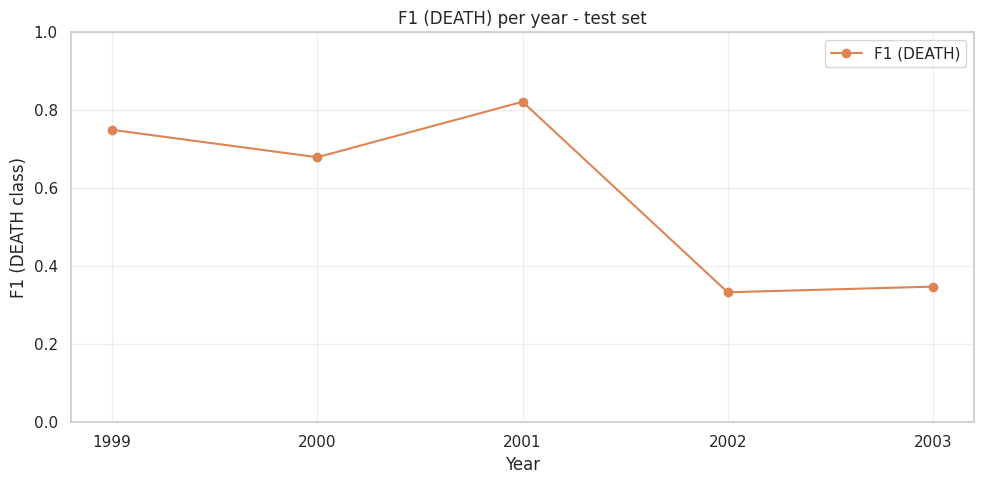

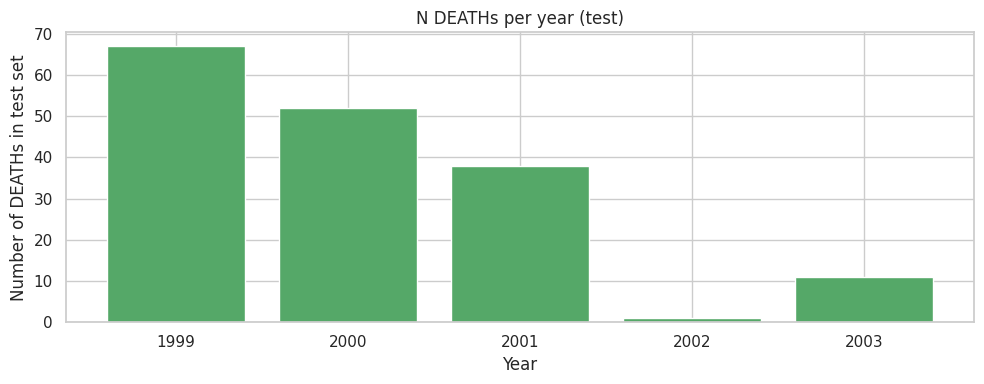

In [51]:
results_df = pd.DataFrame(results_by_year).sort_values('year').reset_index(drop=True)
print("Results by year:")
display(results_df)

plt.figure(figsize=(10,5))
plt.plot(results_df['year'], results_df['f1_pos'], marker='o', linestyle='-', color='C1', label='F1 (DEATH)')
plt.xticks(results_df['year'])
plt.xlabel('Year')
plt.ylabel('F1 (DEATH class)')
plt.title('F1 (DEATH) per year - test set')
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(results_df['year'], results_df['n_deaths'], color='C2')
plt.xlabel('Year')
plt.ylabel('Number of DEATHs in test set')
plt.title('N DEATHs per year (test)')
plt.tight_layout()
plt.show()


### 3.2 t-SNE Visualizations (Dictionary Learning Factors)

t-SNE visualization of Dictionary Learning factors (Test Discovery Set)


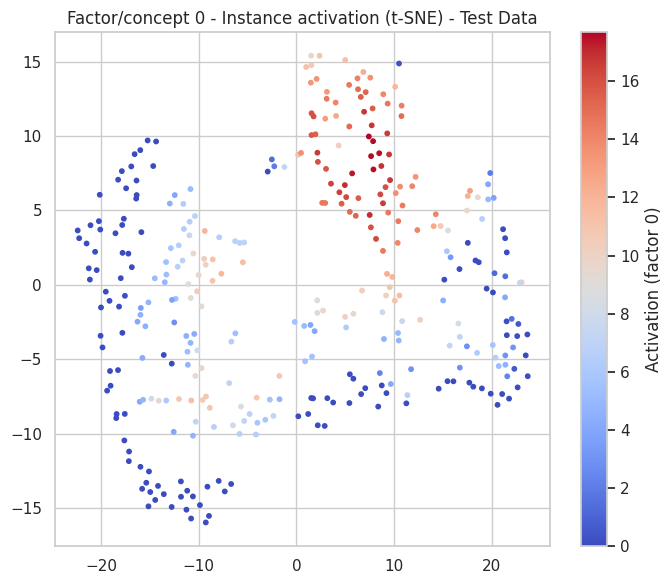

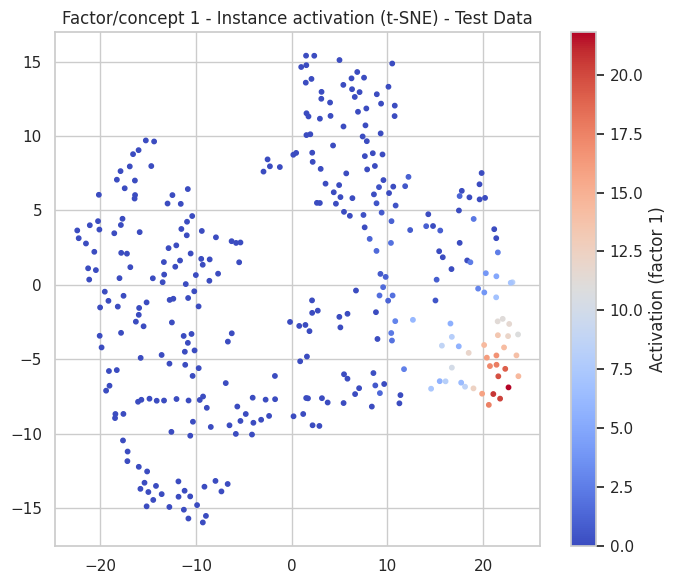

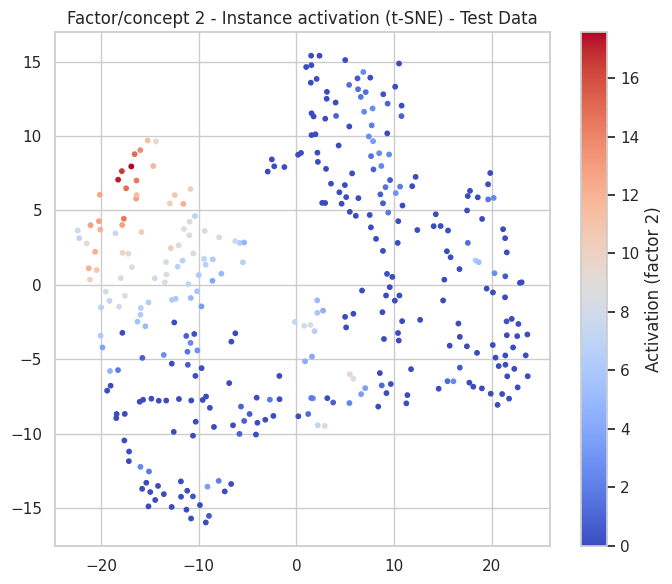

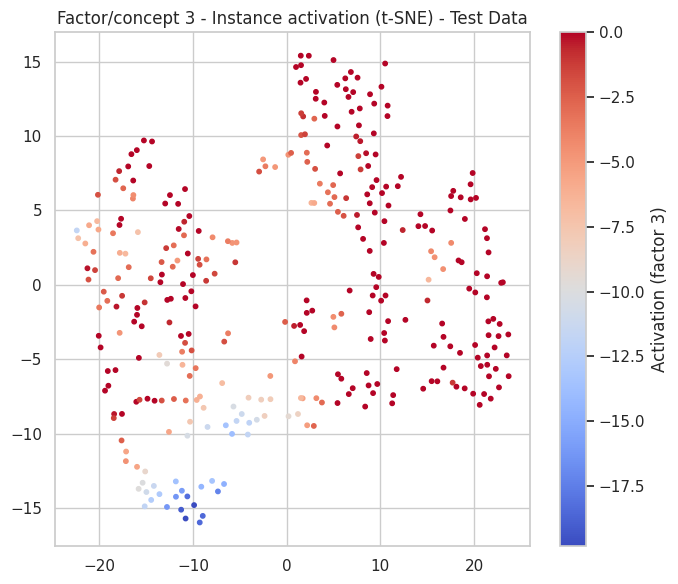

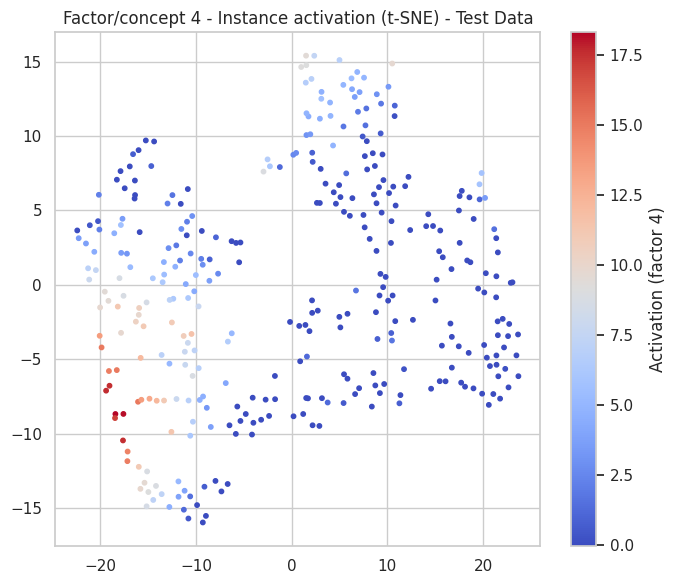

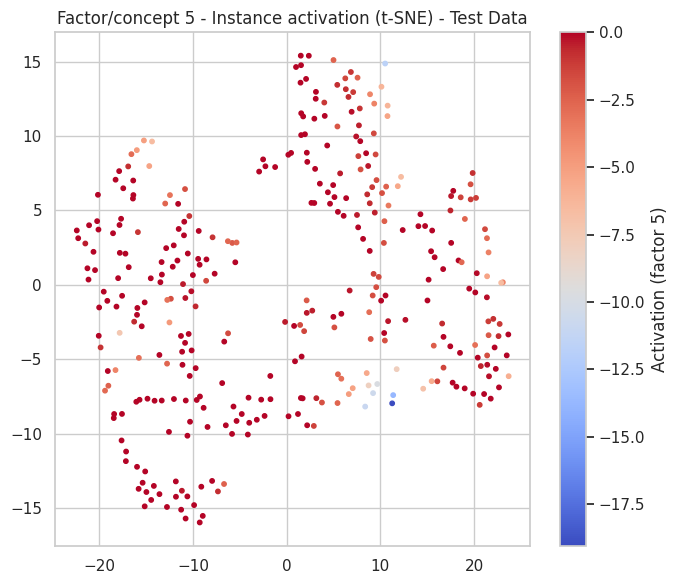

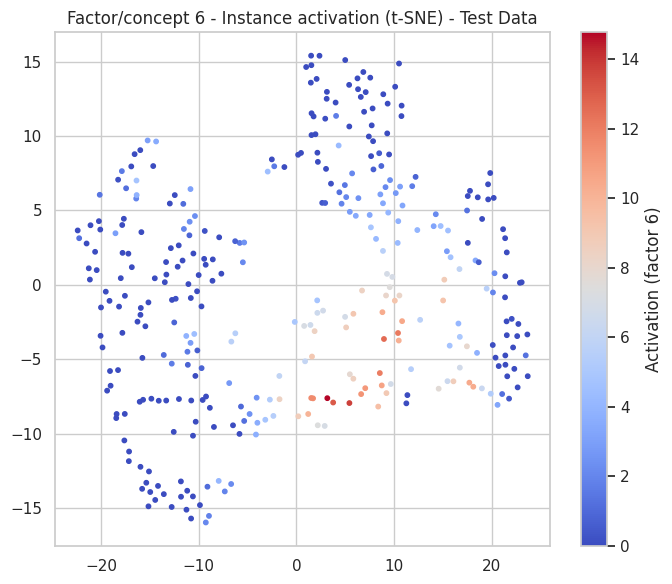

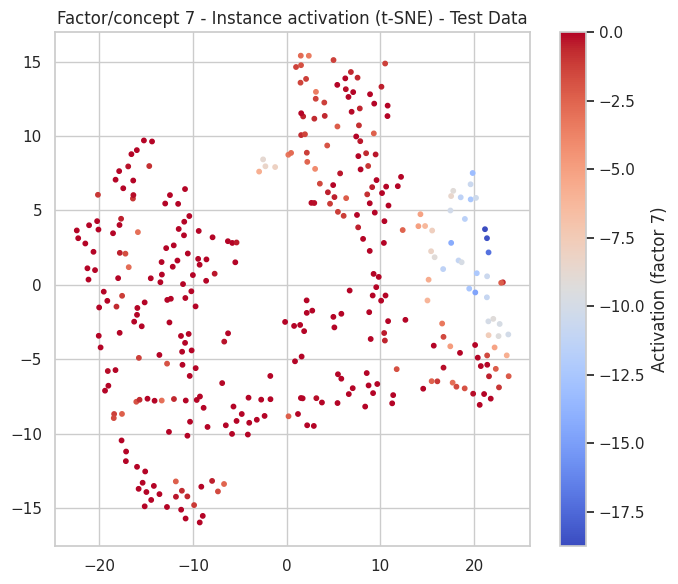

In [52]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb2d = tsne.fit_transform(dict_learning_train_info["embeddings_discovery"])

print("t-SNE visualization of Dictionary Learning factors (Test Discovery Set)")
for k in range(N_FACTORS):
    plt.figure(figsize=(7, 6))
    plt.scatter(
        emb2d[:, 0],
        emb2d[:, 1],
        c=dict_learning_train_info["activations_discovery_train"][:, k],
        cmap="coolwarm",
        s=10
    )
    plt.title(f"Factor/concept {k} - Instance activation (t-SNE) - Test Data")
    plt.colorbar(label=f'Activation (factor {k})')
    plt.tight_layout()
    plt.show()

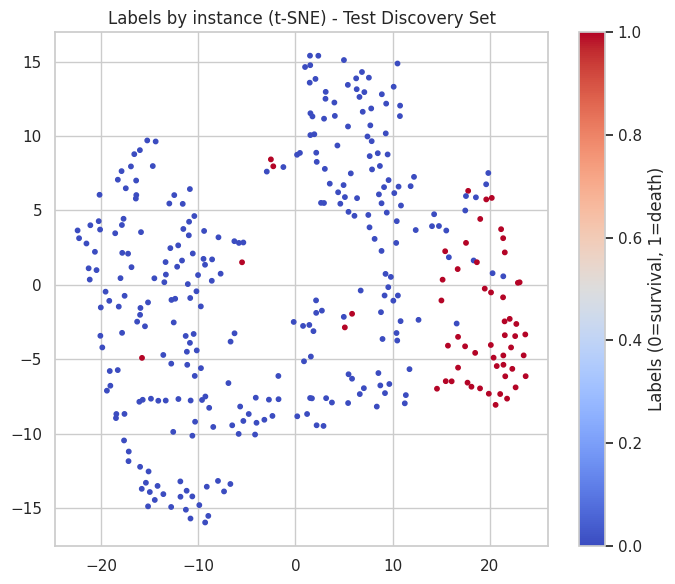

In [53]:
plt.figure(figsize=(7, 6))
plt.scatter(emb2d[:, 0], emb2d[:, 1], c=y_test_discover, cmap="coolwarm", s=10)
plt.title(f"Labels by instance (t-SNE) - Test Discovery Set")
plt.colorbar(label='Labels (0=survival, 1=death)')
plt.tight_layout()
plt.show()

### 3.3 Decomposition Quality

In [54]:
D = model_sae.encoder.weight.t().detach()  # (p, hidden_dim)
D_norm = D / D.norm(dim=0, keepdim=True)
cos_matrix = (D_norm.T @ D_norm).abs()

threshold = 0.5
off_diag = cos_matrix - torch.eye(cos_matrix.size(0))
high_sim_pairs = (off_diag > threshold).sum().item() // 2  # divide by 2 for symmetry
total_pairs = (off_diag > 0).sum().item() // 2
print(f"\n✓ Cosine similarity between SAE decoder atoms:")
print(f"  Pairs with cosine similarity > {threshold}: {high_sim_pairs} / {total_pairs}")
max_pairwise_cosine = off_diag.max().item()
mean_pairwise_cosine = off_diag.mean().item()
print(f"  Max pairwise cosine similarity (off-diagonal): {max_pairwise_cosine:.4f}")
print(f"  Mean pairwise cosine similarity (off-diagonal): {mean_pairwise_cosine:.4f}")

# Co-activation similarity between SAE factors
codes_torch = torch.tensor(codes_train, dtype=torch.float32)
codes_norm = codes_torch / codes_torch.norm(dim=0, keepdim=True)
cos_matrix_codes = (codes_norm.T @ codes_norm).abs()
off_diag_codes = cos_matrix_codes - torch.eye(cos_matrix_codes.size(0))
high_sim_pairs_codes = (off_diag_codes > threshold).sum().item() // 2
total_pairs_codes = (off_diag_codes > 0).sum().item() // 2
print(f"\n✓ Co-activation cosine similarity between SAE factors:")
print(f"  Pairs with cosine similarity > {threshold}: {high_sim_pairs_codes} / {total_pairs_codes}")
max_pairwise_cosine_codes = off_diag_codes.max().item()
mean_pairwise_cosine_codes = off_diag_codes.mean().item()
print(f"  Max pairwise cosine similarity (off-diagonal): {max_pairwise_cosine_codes:.4f}")
print(f"  Mean pairwise cosine similarity (off-diagonal): {mean_pairwise_cosine_codes:.4f}")

# Now, let's check redundancy on the dictionary learning atoms for comparison
W = dict_learning_train_info["W_latent"]  # (emb_dim, n_factors)
W_torch = torch.tensor(W, dtype=torch.float32)
W_norm = W_torch / W_torch.norm(dim=0, keepdim=True)
cos_matrix_W = (W_norm.T @ W_norm).abs()
off_diag_W = cos_matrix_W - torch.eye(cos_matrix_W.size(0))
high_sim_pairs_W = (off_diag_W > threshold).sum().item() // 2
total_pairs_W = (off_diag_W > 0).sum().item() // 2
print(f"\n✓ Cosine similarity between Dictionary Learning atoms:")
print(f"  Pairs with cosine similarity > {threshold}: {high_sim_pairs_W} / {total_pairs_W}")

max_pairwise_cosine_W = off_diag_W.max().item()
mean_pairwise_cosine_W = off_diag_W.mean().item()
print(f"  Max pairwise cosine similarity (off-diagonal): {max_pairwise_cosine_W:.4f}")
print(f"  Mean pairwise cosine similarity (off-diagonal): {mean_pairwise_cosine_W:.4f}")

# Co-activation similarity between Dictionary Learning factors
activations_DL = dict_learning_train_info["activations_discovery_train"]
activations_DL_torch = torch.tensor(activations_DL, dtype=torch.float32)
activations_DL_norm = activations_DL_torch / activations_DL_torch.norm(dim=0, keepdim=True)
cos_matrix_activ_DL = (activations_DL_norm.T @ activations_DL_norm).abs()
off_diag_activ_DL = cos_matrix_activ_DL - torch.eye(cos_matrix_activ_DL.size(0))
high_sim_pairs_activ_DL = (off_diag_activ_DL > threshold).sum().item() // 2
total_pairs_activ_DL = (off_diag_activ_DL > 0).sum().item() // 2
print(f"\n✓ Co-activation cosine similarity between Dictionary Learning factors:")
print(f"  Pairs with cosine similarity > {threshold}: {high_sim_pairs_activ_DL} / {total_pairs_activ_DL}")
max_pairwise_cosine_activ_DL = off_diag_activ_DL.max().item()
mean_pairwise_cosine_activ_DL = off_diag_activ_DL.mean().item()
print(f"  Max pairwise cosine similarity (off-diagonal): {max_pairwise_cosine_activ_DL:.4f}")
print(f"  Mean pairwise cosine similarity (off-diagonal): {mean_pairwise_cosine_activ_DL:.4f}")


✓ Cosine similarity between SAE decoder atoms:
  Pairs with cosine similarity > 0.5: 6 / 41387
  Max pairwise cosine similarity (off-diagonal): 0.9230
  Mean pairwise cosine similarity (off-diagonal): 0.0625

✓ Co-activation cosine similarity between SAE factors:
  Pairs with cosine similarity > 0.5: 323 / 6521
  Max pairwise cosine similarity (off-diagonal): nan
  Mean pairwise cosine similarity (off-diagonal): nan

✓ Cosine similarity between Dictionary Learning atoms:
  Pairs with cosine similarity > 0.5: 27 / 30
  Max pairwise cosine similarity (off-diagonal): 0.8765
  Mean pairwise cosine similarity (off-diagonal): 0.6506

✓ Co-activation cosine similarity between Dictionary Learning factors:
  Pairs with cosine similarity > 0.5: 0 / 28
  Max pairwise cosine similarity (off-diagonal): 0.3372
  Mean pairwise cosine similarity (off-diagonal): 0.1532


#### NOTE:
The following cell output was used only for comparison purposes. It was not what led us to use the sparse autoencoder instead of SKLearn's Dictionary Learning. Read the original paper for better clarification.

In [55]:
# Comparison: Dictionary Learning vs. Sparse Autoencoder
print("=" * 70)
print("COMPARISON: Dictionary Learning vs. Sparse Autoencoder")
print("=" * 70)

dict_codes = dict_learning_train_info["activations_discovery_train"]
dict_atoms = dict_learning_train_info["W_latent"]

print("\n1. ARCHITECTURE")
print("-" * 70)
print("Dictionary Learning:")
print("  - Optimization: Alternating minimization (sklearn)")
print("  - Constraint: Lasso (exact L1 constraint)")
print("  - Decoder: Linear reconstruction from sparse codes")
print("\nSparse Autoencoder:")
print("  - Optimization: Gradient descent (PyTorch)")
print("  - Constraint: L1 penalty (soft sparsity)")
print("  - Encoder: Neural network (Linear + ReLU)")

print("\n2. SPARSITY")
print("-" * 70)
dict_sparsity = (np.abs(dict_codes) <= 1e-5).mean()
sae_sparsity = (np.abs(codes_train) <= 1e-5).mean()
print(f"Dictionary Learning: {dict_sparsity:.2%} near-zero")
print(f"Sparse Autoencoder:  {sae_sparsity:.2%} near-zero")
print(f"Active neurons (DL): {(np.abs(dict_codes) > 1e-5).sum(axis=1).mean():.1f} / {N_FACTORS}")
print(f"Active neurons (SAE): {(codes_train > 1e-5).sum(axis=1).mean():.1f} / {n_factors}")

print("\n3. ACTIVATION STATISTICS")
print("-" * 70)
print(f"Dictionary Learning:")
print(f"  Mean activation: {np.abs(dict_codes).mean():.4f}")
print(f"  Std activation:  {dict_codes.std():.4f}")
print(f"  Max activation:  {np.abs(dict_codes).max():.4f}")
print(f"\nSparse Autoencoder:")
print(f"  Mean activation: {np.abs(codes_train).mean():.4f}")
print(f"  Std activation:  {codes_train.std():.4f}")
print(f"  Max activation:  {codes_train.max():.4f}")

print("\n4. CODE CORRELATION (between methods)")
print("-" * 70)

correlations = []
for k in range(N_FACTORS):
    corr, _ = spearmanr(dict_codes[:, k], codes_train[:, k])
    correlations.append(corr)
print(f"Mean Spearman correlation: {np.mean(correlations):.3f}")
print(f"Max correlation:           {np.max(correlations):.3f}")
print(f"Min correlation:           {np.min(correlations):.3f}")
print(f"\nInterpretation: Correlation > 0.5 suggests similar concepts discovered")

print("\n5. RECONSTRUCTION QUALITY")
print("-" * 70)
# Dictionary Learning reconstruction
dict_recon = dict_codes @ dict_atoms.T
dict_mse = np.mean((train_emb_discovery - dict_recon) ** 2)
print(f"Dictionary Learning MSE: {dict_mse:.6f}")

# SAE reconstruction
with torch.no_grad():
    sae_recon, _ = model_sae(X_torch)
    sae_recon_np = sae_recon.numpy()
sae_mse = np.mean((train_emb_discovery - sae_recon_np) ** 2)
print(f"Sparse Autoencoder MSE:  {sae_mse:.6f}")
print(f"\nRelative MSE difference: {(sae_mse - dict_mse) / dict_mse * 100:.1f}%")

print("\n6. KEY DIFFERENCES & RECOMMENDATIONS")
print("-" * 70)
print("Dictionary Learning:")
print("  ✓ Proven method with exact sparse coding")
print("  ✓ No hyperparameter tuning needed (sklearn handles optimization)")
print("  ✓ Typically sparser codes (better for interpretability)")
print("  ✗ Slower to fit (iterative optimization)")
print("\nSparse Autoencoder:")
print("  ✓ Fast training (GPU-accelerated gradient descent)")
print("  ✓ Flexible architecture (can add layers, change activations)")
print("  ✓ Differentiable (can backprop through for downstream tasks)")
print("  ✗ Requires tuning (learning rate, sparsity penalty, epochs)")
print("  ✗ Less sparse by default (softer L1 penalty)")

print("\n7. WHICH TO USE FOR TCAV?")
print("-" * 70)
if dict_sparsity > sae_sparsity + 0.1:
    print("→ Dictionary Learning recommended:")
    print("  Better sparsity for clearer concept interpretation")
elif sae_mse < dict_mse * 0.9:
    print("→ Sparse Autoencoder recommended:")
    print("  Better reconstruction with acceptable sparsity")
else:
    print("→ Both methods are comparable:")
    print("  Try both and compare TCAV scores")
    print("  Dictionary Learning for interpretability")
    print("  SAE for flexibility and speed")

print("\n" + "=" * 70)

COMPARISON: Dictionary Learning vs. Sparse Autoencoder

1. ARCHITECTURE
----------------------------------------------------------------------
Dictionary Learning:
  - Optimization: Alternating minimization (sklearn)
  - Constraint: Lasso (exact L1 constraint)
  - Decoder: Linear reconstruction from sparse codes

Sparse Autoencoder:
  - Optimization: Gradient descent (PyTorch)
  - Constraint: L1 penalty (soft sparsity)
  - Encoder: Neural network (Linear + ReLU)

2. SPARSITY
----------------------------------------------------------------------
Dictionary Learning: 53.28% near-zero
Sparse Autoencoder:  91.25% near-zero
Active neurons (DL): 3.7 / 8
Active neurons (SAE): 25.2 / 288

3. ACTIVATION STATISTICS
----------------------------------------------------------------------
Dictionary Learning:
  Mean activation: 2.6217
  Std activation:  4.8996
  Max activation:  21.8002

Sparse Autoencoder:
  Mean activation: 0.1826
  Std activation:  1.2146
  Max activation:  17.1446

4. CODE CORRE

/tmp/ipykernel_244188/459852323.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(dict_codes[:, k], codes_train[:, k])


### 3.4 SAE TCAV Results

In [56]:
tcav_mean = np.mean([res.tcav_positive_fraction for res in results_sae.values()])
print(f"  Overall mean directional derivative: {tcav_mean:.6f}")

num_tcav_above_0_5 = sum(1 for res in results_sae.values() if res.tcav_positive_fraction > 0.7)
print(f"  Concepts with TCAV > 0.5: {num_tcav_above_0_5} / {len(results_sae)}")

num_tcav_below_0_5 = sum(1 for res in results_sae.values() if res.tcav_positive_fraction < 0.3)
print(f"  Concepts with TCAV < 0.5: {num_tcav_below_0_5} / {len(results_sae)}")
df_results = pd.DataFrame([
    {
        "cluster": res.cluster_id,
        "tcav_prop_positive": res.tcav_positive_fraction,
        "mean_derivative": res.mean_derivative,
        "size_pure": cav_dict_sae[res.cluster_id]["size_pos"],
        "size_neg": len(cav_dict_sae[res.cluster_id]["neg_idx"]),
        "deriv_std": np.std(res.derivatives),  # Check variability
        "deriv_range": res.derivatives.max() - res.derivatives.min()
    }
    for res in results_sae.values()
])
display(df_results)

  Overall mean directional derivative: 0.553030
  Concepts with TCAV > 0.5: 9 / 22
  Concepts with TCAV < 0.5: 6 / 22


,cluster,tcav_prop_positive,mean_derivative,size_pure,size_neg,deriv_std,deriv_range
0,1,1.000000,0.079607,43,43,0.008706,0.058776
1,21,0.977011,0.015593,65,65,0.011455,0.056549
2,26,0.902299,0.015802,54,54,0.010526,0.052117
3,34,1.000000,0.143923,33,33,0.011001,0.048464
4,84,0.000000,-0.076352,48,48,0.008691,0.038376
5,93,0.574713,0.005572,47,47,0.040404,0.190652
6,98,0.000000,-0.045596,47,47,0.010159,0.043920
7,117,0.362069,-0.019190,66,66,0.068208,0.321203
8,160,0.000000,-0.072611,78,78,0.014860,0.062387
9,163,1.000000,0.125496,55,55,0.014824,0.063508


### 3.5 Decision Tree Rule Validation on Held-Out Data

In [57]:
# This analysis validates whether concepts are capturing meaningful phenotypes by:
# 1. For each concept in matched_df, parse the Decision Tree rules from 'Path' column
# 2. Apply these rules to find matching samples in the TCAV eval set
# 3. Compare activations between rule-matched and non-matched samples

print("="*70)
print("CONCEPT FEATURE RANGE VALIDATION (DECISION TREE RULES)")
print("="*70)

# Verify data availability
required_vars = ['matched_df', 'held_out_concept_activations',
                 'X_held_out_raw', 'feature_cols', 'X_test_df', 'idx_test_held_out']

for var in required_vars:
    if var not in dir():
        raise ValueError(
            f"Required variable '{var}' not found. Please run previous cells first.")

print(f"✓ Data loaded successfully")
print(f"  - {len(matched_df)} matched factors in matched_df")
print(f"  - {X_held_out_raw.shape[0]} samples in TCAV eval set")
print(f"  - {len(feature_cols)} features")

# parse_decision_tree_rule() and apply_rule_conditions() are defined in cell 37.

# Store results for all concepts
tree_features_validation_results = {}

print(f"\n{'='*70}")
print("ANALYZING DECISION TREE RULES FROM matched_df")
print(f"{'='*70}")

# Prepare the feature data for TCAV eval set
X_held_out_eval_df = X_test_df.iloc[idx_test_held_out].reset_index(drop=True)

# Determine which column contains the rule (could be 'Path' or 'Rule')
rule_column = 'Path' if 'Path' in matched_df.columns else 'Rule'
print(f"Using rule column: '{rule_column}'")

for idx, row in matched_df.iterrows():
    factor_id = int(row['Factor'])
    rule_string = row[rule_column] if rule_column in row.index else ""

    print(f"\n{'-'*70}")
    print(f"SAE FACTOR {factor_id}")
    print(f"{'-'*70}")
    print(f"  Rule: {rule_string}")

    # Parse the rule
    conditions = parse_decision_tree_rule(rule_string)

    if len(conditions) == 0:
        print(f"  ⚠️ No valid conditions parsed - skipping")
        continue

    print(f"  Parsed conditions ({len(conditions)}):")
    for feat, op, thresh in conditions:
        print(f"     - {feat} {op} {thresh}")

    # Apply rule to ALL samples in TCAV eval set (no exclusion)
    idx_matched = apply_rule_conditions(
        X_held_out_eval_df, conditions, feature_cols)
    idx_not_matched = ~idx_matched

    n_matched = np.sum(idx_matched)
    n_not_matched = np.sum(idx_not_matched)

    print(f"\n  📊 Rule matching results:")
    print(
        f"     Samples matching rule: {n_matched} ({n_matched/len(idx_matched)*100:.1f}%)")
    print(
        f"     Samples NOT matching: {n_not_matched} ({n_not_matched/len(idx_matched)*100:.1f}%)")

    if n_matched < 5 or n_not_matched < 5:
        print(f"     ⚠️ Too few samples in one group for reliable comparison")
        continue

    # Get SAE activations for this factor
    if factor_id >= held_out_concept_activations.shape[1]:
        print(f"     ⚠️ Factor {factor_id} out of range, skipping")
        continue

    factor_activations = held_out_concept_activations[:, factor_id]

    # Compare activations between matched and non-matched groups
    matched_acts = factor_activations[idx_matched]
    not_matched_acts = factor_activations[idx_not_matched]

    print(f"\n  📈 Activation comparison:")
    print(
        f"     MATCHED samples mean activation:     {np.mean(matched_acts):.4f} ± {np.std(matched_acts):.4f}")
    print(
        f"     NOT MATCHED samples mean activation: {np.mean(not_matched_acts):.4f} ± {np.std(not_matched_acts):.4f}")

    # Statistical test: are matched samples having higher activation?
    stat, pval = stats.mannwhitneyu(
        matched_acts, not_matched_acts, alternative='greater')
    print(f"     Mann-Whitney U test (matched > not_matched): p = {pval:.4e}")

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(
        (np.std(matched_acts)**2 + np.std(not_matched_acts)**2) / 2)
    cohens_d = (np.mean(matched_acts) - np.mean(not_matched_acts)
                ) / pooled_std if pooled_std > 0 else 0
    print(f"     Effect size (Cohen's d): {cohens_d:.3f}")

    # Interpretation
    if pval < 0.05 and cohens_d > 0.2:
        print(f"     ✓ Rule successfully captures high-activation samples")
    elif pval < 0.05:
        print(f"     ~ Rule shows significant but small effect")
    else:
        print(f"     ✗ Rule does NOT significantly differentiate activation levels")

    # Store results
    tree_features_validation_results[factor_id] = {
        'rule_string': rule_string,
        'conditions': conditions,
        'n_matched': n_matched,
        'n_not_matched': n_not_matched,
        'idx_matched': idx_matched,
        'idx_not_matched': idx_not_matched,
        'matched_activation_mean': float(np.mean(matched_acts)),
        'matched_activation_std': float(np.std(matched_acts)),
        'not_matched_activation_mean': float(np.mean(not_matched_acts)),
        'not_matched_activation_std': float(np.std(not_matched_acts)),
        'mannwhitney_pval': float(pval),
        'cohens_d': float(cohens_d)
    }

# Summary table
print(f"\n{'='*70}")
print("SUMMARY: DECISION TREE RULE VALIDATION")
print(f"{'='*70}")

if len(tree_features_validation_results) > 0:
    summary_rows = []
    for factor_id, res in tree_features_validation_results.items():
        summary_rows.append({
            'SAE Factor': factor_id,
            'N Matched': res['n_matched'],
            'N Not Matched': res['n_not_matched'],
            'Matched Act Mean': res['matched_activation_mean'],
            'Not Matched Act Mean': res['not_matched_activation_mean'],
            'Cohen\'s d': res['cohens_d'],
            'p-value': res['mannwhitney_pval'],
            'Significant': res['mannwhitney_pval'] < 0.05
        })

    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.style.format({
        'Matched Act Mean': '{:.4f}',
        'Not Matched Act Mean': '{:.4f}',
        'Cohen\'s d': '{:.3f}',
        'p-value': '{:.2e}'
    }).background_gradient(subset=['Cohen\'s d'], cmap='RdYlGn', vmin=-1, vmax=1))

    # Statistics
    n_significant = summary_df['Significant'].sum()
    n_total = len(summary_df)
    print(
        f"\n✓ {n_significant}/{n_total} rules show statistically significant separation (p < 0.05)")

    n_large_effect = (summary_df['Cohen\'s d'] > 0.5).sum()
    print(
        f"✓ {n_large_effect}/{n_total} rules show large effect size (Cohen's d > 0.5)")
else:
    print("⚠️ No valid rules were analyzed")

CONCEPT FEATURE RANGE VALIDATION (DECISION TREE RULES)
✓ Data loaded successfully
  - 9 matched factors in matched_df
  - 175 samples in TCAV eval set
  - 8 features

ANALYZING DECISION TREE RULES FROM matched_df
Using rule column: 'Path'

----------------------------------------------------------------------
SAE FACTOR 1
----------------------------------------------------------------------
  Rule: kappa <= 1.47 AND lambda <= 2.17 AND kappa <= 1.07
  Parsed conditions (3):
     - kappa <= 1.47
     - lambda <= 2.17
     - kappa <= 1.07

  📊 Rule matching results:
     Samples matching rule: 42 (24.0%)
     Samples NOT matching: 133 (76.0%)

  📈 Activation comparison:
     MATCHED samples mean activation:     0.8541 ± 0.9517
     NOT MATCHED samples mean activation: 0.9153 ± 1.5653
     Mann-Whitney U test (matched > not_matched): p = 1.7503e-03
     Effect size (Cohen's d): -0.047
     ~ Rule shows significant but small effect

---------------------------------------------------------

,SAE Factor,N Matched,N Not Matched,Matched Act Mean,Not Matched Act Mean,Cohen's d,p-value,Significant
0,1,42,133,0.8541,0.9153,-0.047,1.75e-03,True
1,34,33,142,1.5180,0.5011,1.290,1.05e-10,True
2,84,41,134,0.4903,0.3214,0.379,6.07e-03,True
3,98,45,130,0.7313,0.7332,-0.003,9.48e-02,False
4,163,70,105,4.0827,0.5970,1.429,1.04e-17,True
5,188,34,141,1.3784,0.2217,1.556,1.72e-14,True
6,208,53,122,1.8029,0.1331,2.329,1.66e-26,True
7,263,44,131,0.6039,0.0782,1.664,1.67e-19,True
8,280,52,123,1.3171,0.1776,1.508,5.40e-18,True



✓ 8/9 rules show statistically significant separation (p < 0.05)
✓ 6/9 rules show large effect size (Cohen's d > 0.5)


In [58]:
average_conditions_per_rule = np.mean([len(res['conditions']) for res in tree_features_validation_results.values()]) if len(tree_features_validation_results) > 0 else 0
print(f"\nAverage number of conditions per rule: {average_conditions_per_rule:.2f}")


Average number of conditions per rule: 3.33


### 3.6 t-SNE Held-Out Visualizations

aa137


/tmp/ipykernel_244188/651515590.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


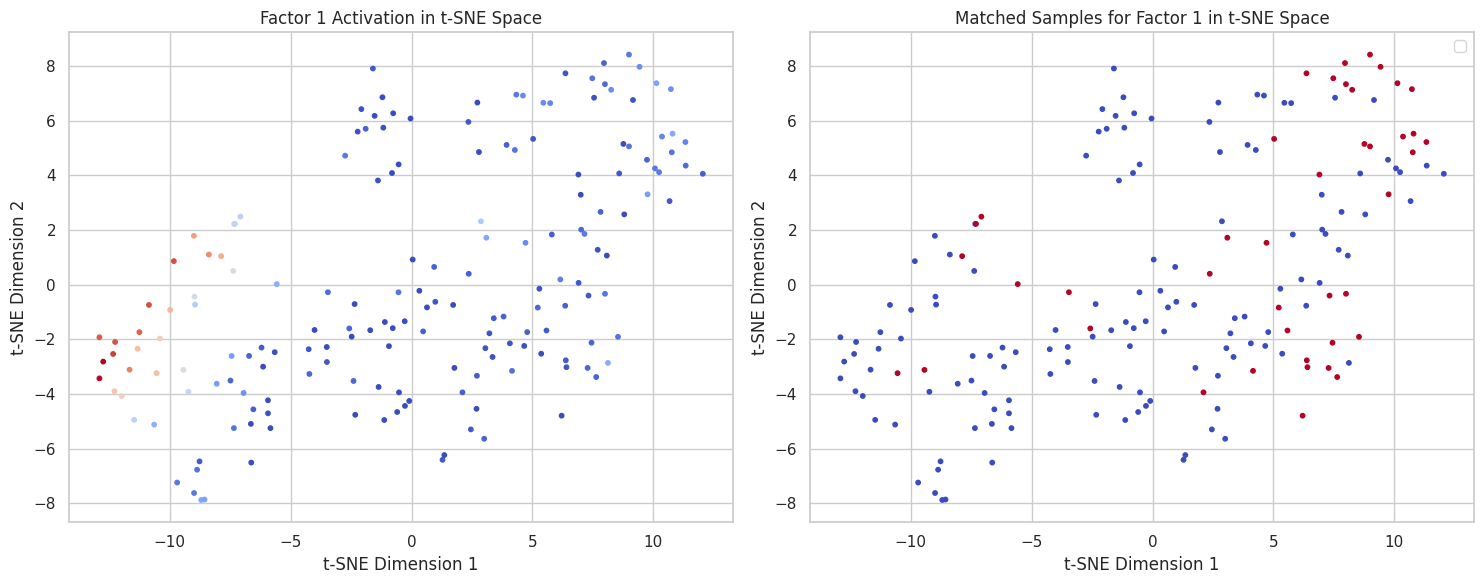

aa129


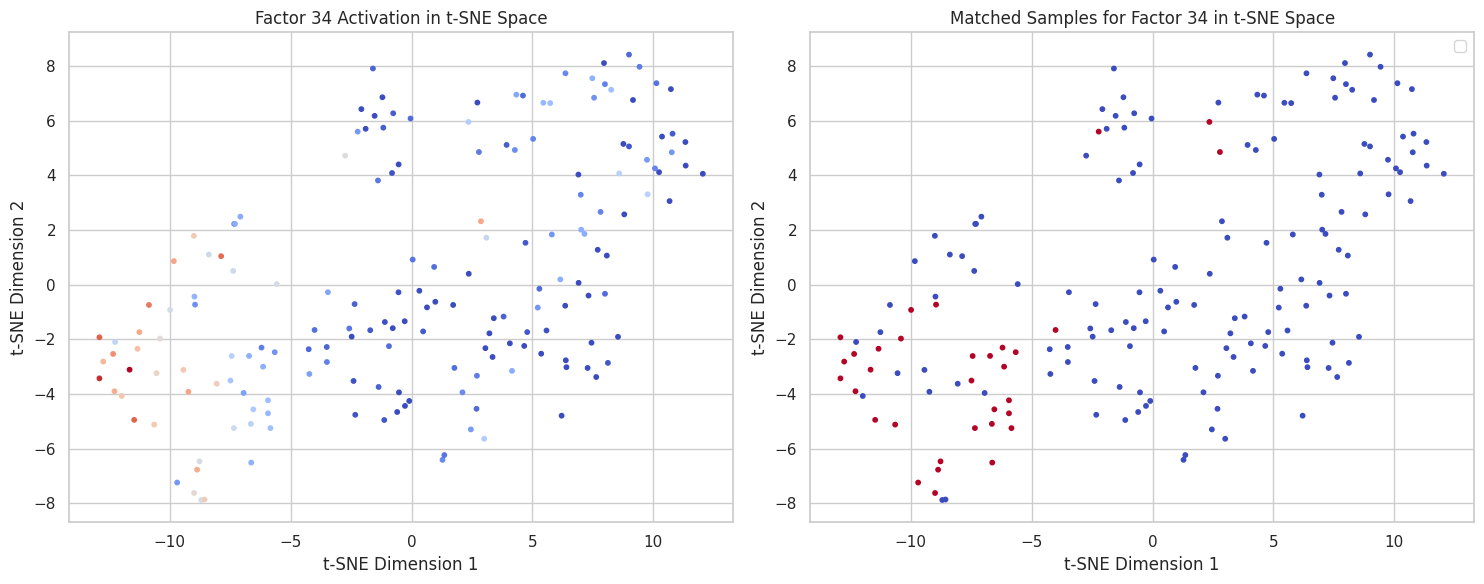

aa106


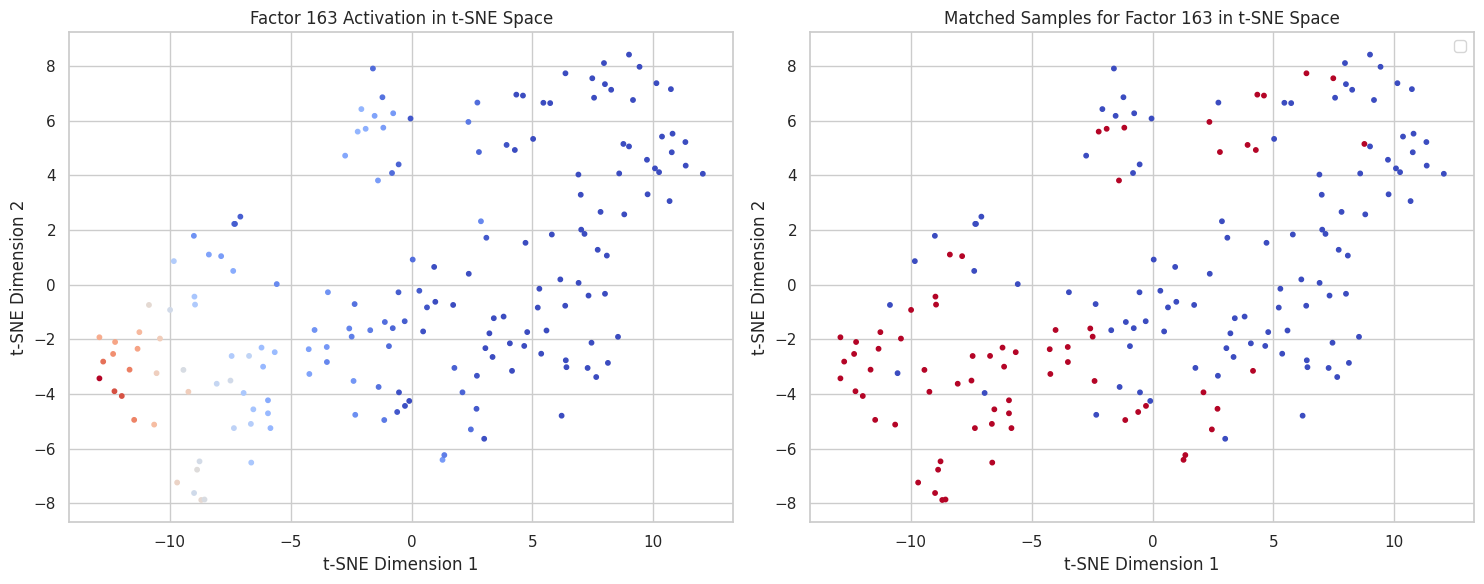

aa143


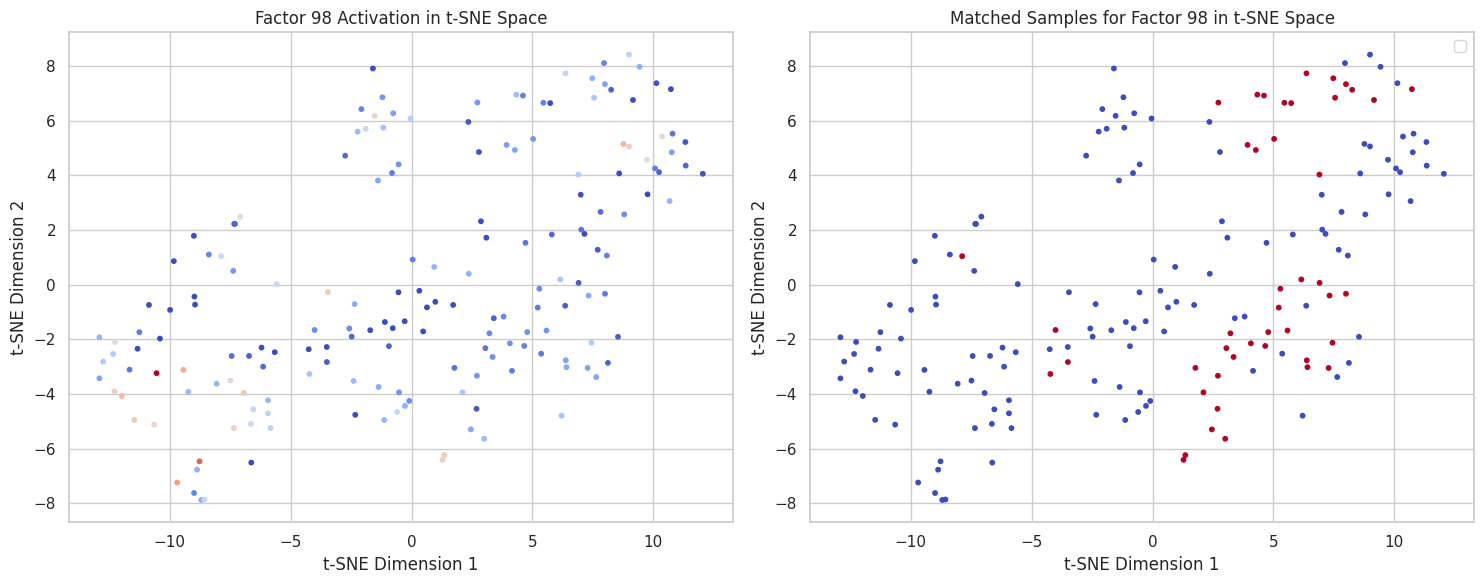

aa91


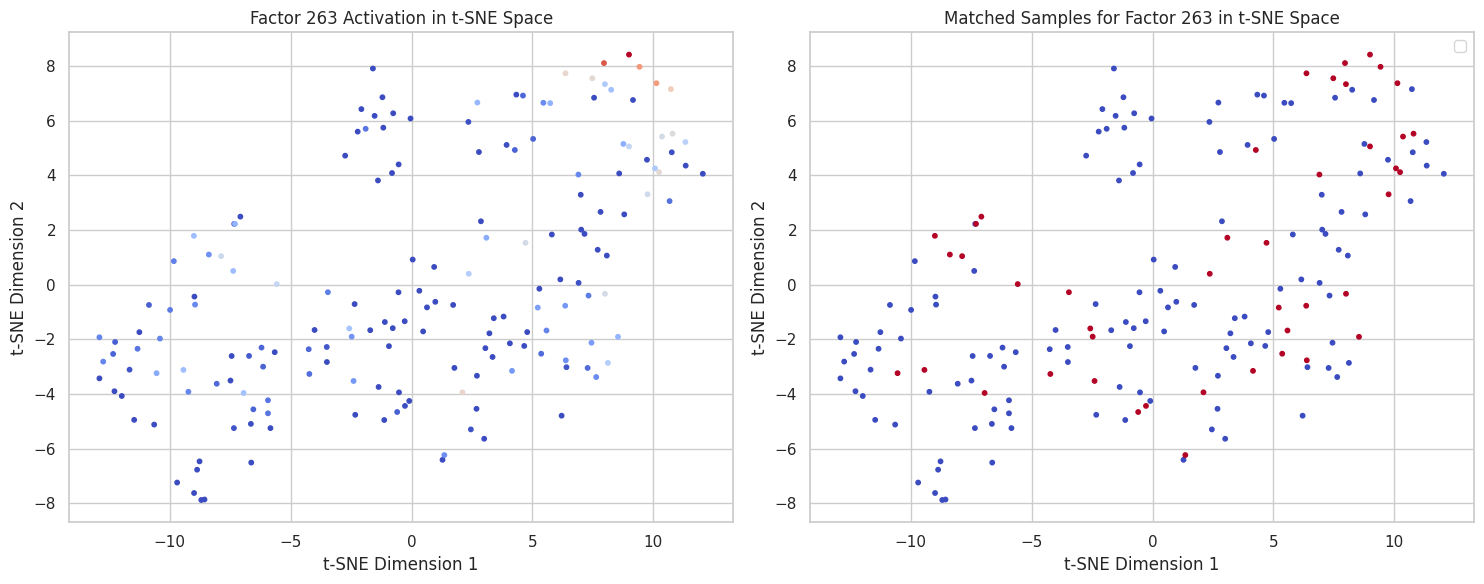

aa73


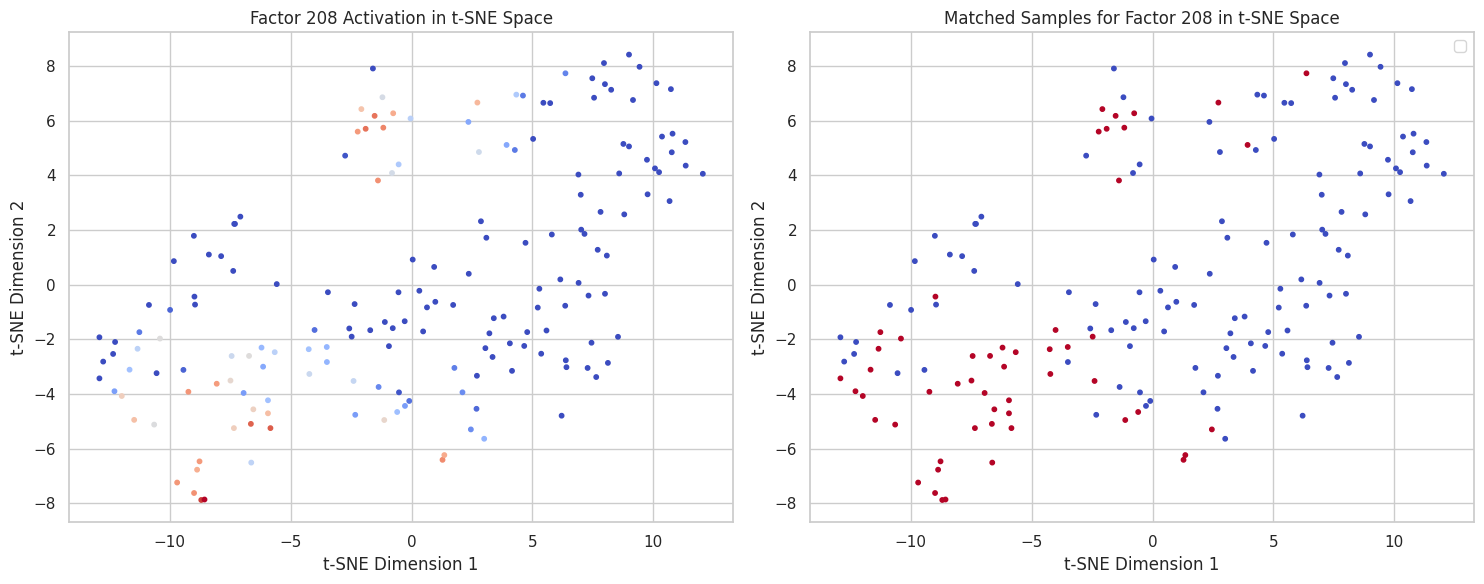

aa110


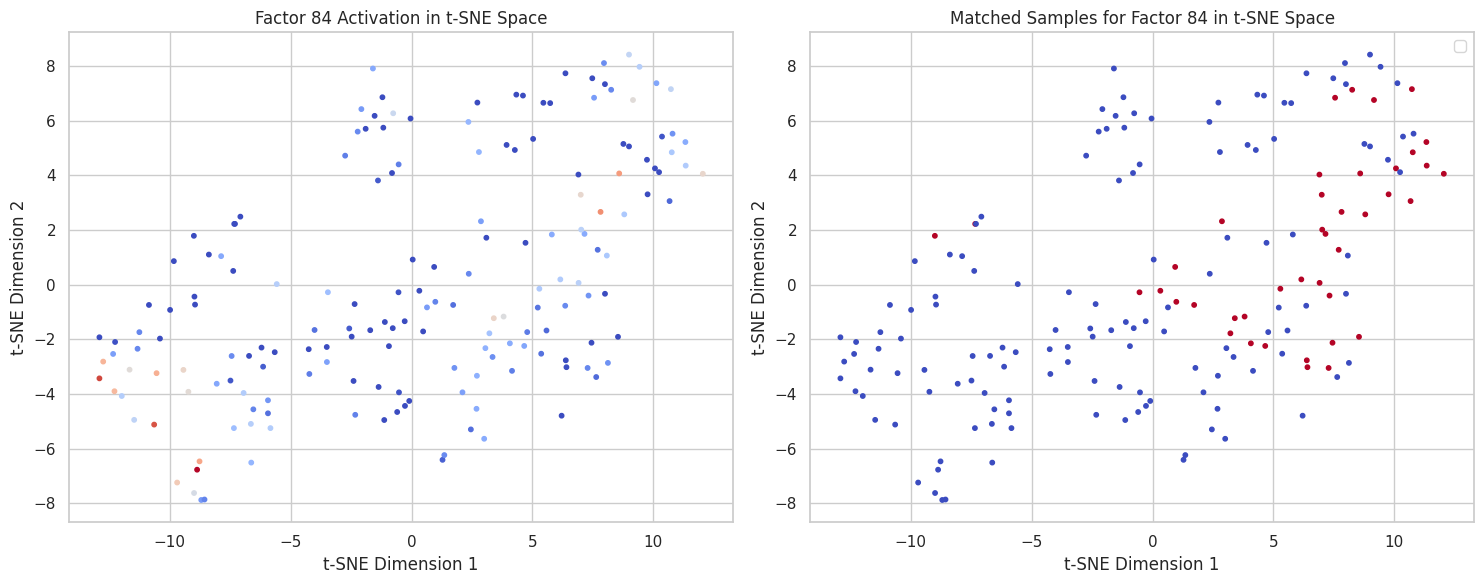

aa66


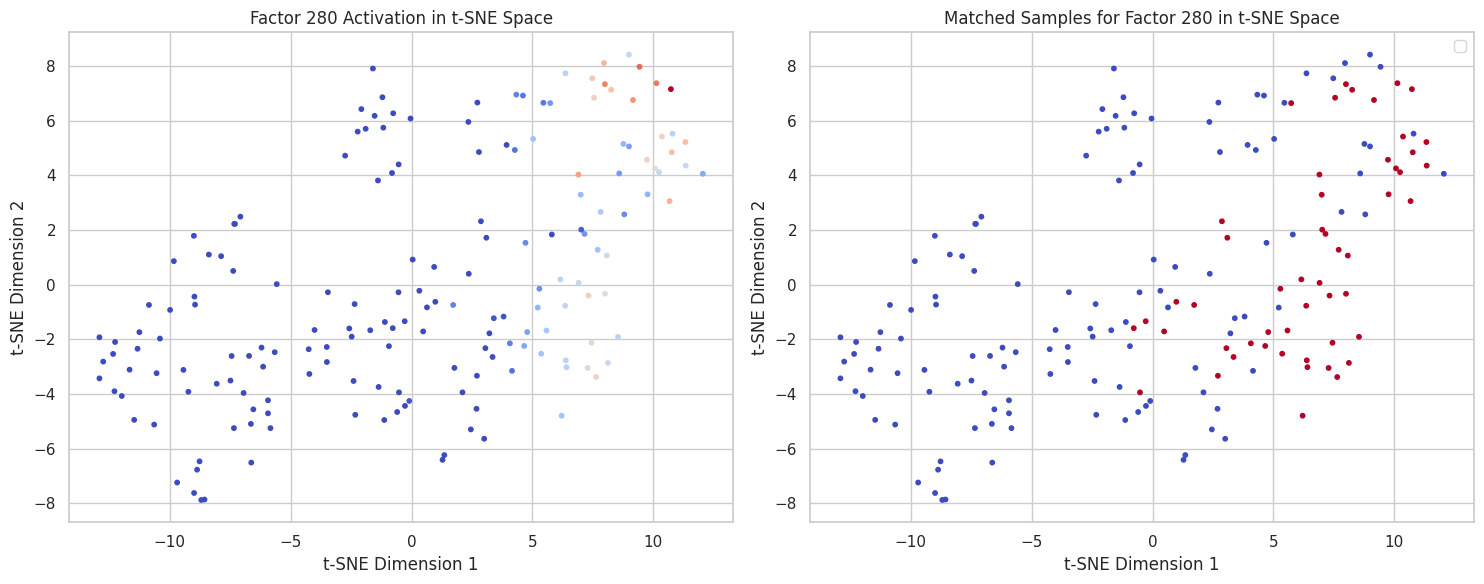

aa96


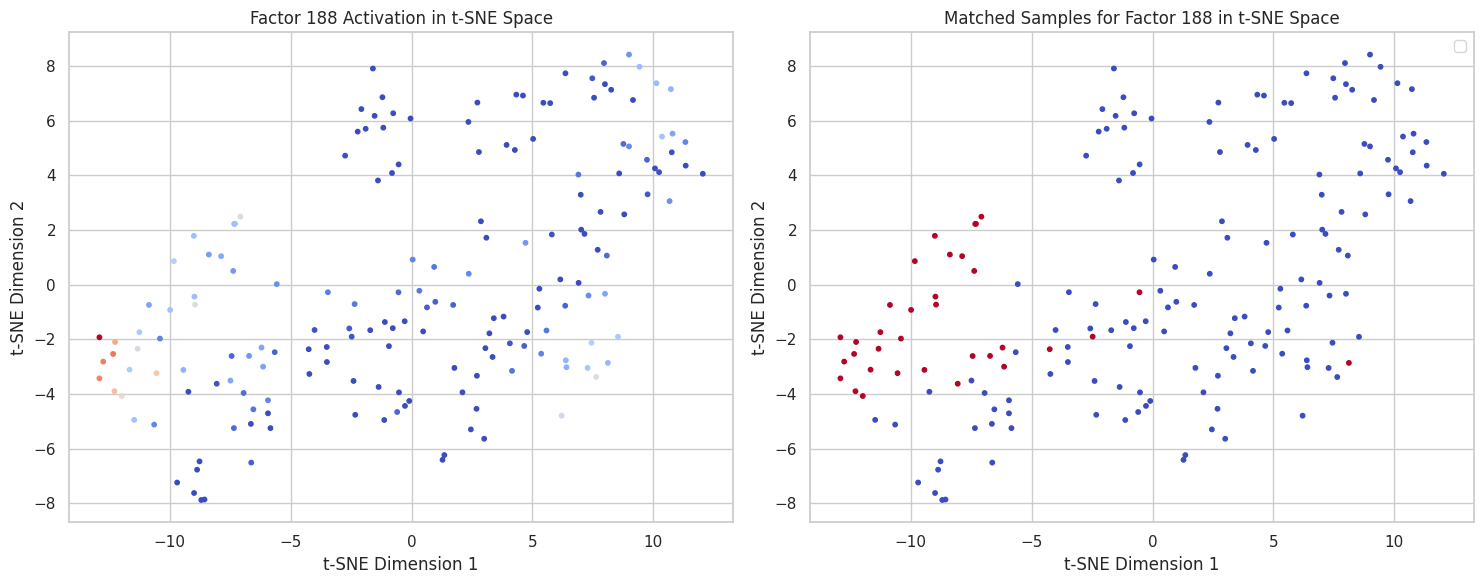

In [59]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb2d_held_out_eval = tsne.fit_transform(held_out_embeddings)
TSNE_FACTORS_SAE_MATCHED_SAMPLES_DIR = RESULTS_DIR / "tsne_factors_sae_matched_samples"
TSNE_FACTORS_SAE_MATCHED_SAMPLES_DIR.mkdir(exist_ok=True)

for k in matched_factors:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sc = axes[0].scatter(emb2d_held_out_eval[:, 0], emb2d_held_out_eval[:, 1],
                        c=held_out_concept_activations[:, k],
                        cmap='coolwarm', s=10)
    axes[0].set_title(f'Factor {k} Activation in t-SNE Space')
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    print(f"aa{len(held_out_concept_activations[:, k][held_out_concept_activations[:, k] > 0])}")

    axes[1].scatter(emb2d_held_out_eval[:, 0], emb2d_held_out_eval[:, 1],
                    c=tree_features_validation_results[k]["idx_matched"], cmap='coolwarm', s=10)
    axes[1].set_title(f'Matched Samples for Factor {k} in t-SNE Space')
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{TSNE_FACTORS_SAE_MATCHED_SAMPLES_DIR}/tsne_factor_{k}_matched_samples_sae.png", dpi=150, bbox_inches='tight')
    plt.show()

### 3.7 ACE / Ablation Summary

In [60]:
print("="*70)
print("ACE SANITY CHECK RESULTS SUMMARY")
print("="*70)

# Create summary DataFrame
ace_summary_data = []
for concept_id, result in ace_results.items():
    # Get phenotype info if available
    phenotype_sig = "N/A"
    risk_category = "N/A"
    if 'report_df_sae' in dir():
        row = report_df_sae[report_df_sae['Concept'] == concept_id]
        if len(row) > 0:
            phenotype_sig = row.iloc[0].get('Phenotype Signature', 'N/A')
            risk_category = row.iloc[0].get('Risk Category', 'N/A')

    ace_summary_data.append({
        'Concept': concept_id,
        'Phenotype': phenotype_sig[:30] + '...' if len(str(phenotype_sig)) > 30 else phenotype_sig,
        'Risk': risk_category,
        # Destruction test
        'Δ_destroy (all)': result.destruction_delta_mean,
        'Δ_destroy (high)': result.destruction_delta_high_concept,
        'Δ_destroy (low)': result.destruction_delta_low_concept,
        'Effect Ratio': result.destruction_effect_ratio,
        # Sufficiency test
        'Suff Ratio (all)': result.sufficiency_ratio_mean,
        'Suff Ratio (high)': result.sufficiency_ratio_high_concept,
        # Drift metrics
        'Destroy Drift': result.destruction_drift_index,
        'Suff Drift': result.sufficiency_drift_index,
        'Drift Sensitive': '⚠️' if result.is_drift_sensitive else '✓'
    })

ace_df = pd.DataFrame(ace_summary_data)

# Display with formatting
print("\n📊 ACE Sanity Check Results:")
print("-" * 70)
print("\nInterpretation Guide:")
print("  • Δ_destroy < 0: Ablating concept DECREASES prediction (concept is used)")
print("  • Δ_destroy (high) << Δ_destroy (low): Effect concentrated in high-activation samples (good)")
print("  • Effect Ratio > 1: Ablation affects high-concept samples more (validates concept)")
print("  • Suff Ratio ≈ 1: Concept alone is sufficient for prediction")
print("  • Drift Sensitive ⚠️: Effect varies significantly across time domains")
print()

display(ace_df.style.format({
    'Δ_destroy (all)': '{:.4f}',
    'Δ_destroy (high)': '{:.4f}',
    'Δ_destroy (low)': '{:.4f}',
    'Effect Ratio': '{:.2f}',
    'Suff Ratio (all)': '{:.3f}',
    'Suff Ratio (high)': '{:.3f}',
    'Destroy Drift': '{:.5f}',
    'Suff Drift': '{:.5f}'
}).background_gradient(subset=['Δ_destroy (high)'], cmap='RdYlGn_r', vmin=-0.1, vmax=0.1)
  .background_gradient(subset=['Effect Ratio'], cmap='Greens', vmin=0.5, vmax=2.0)
  .background_gradient(subset=['Suff Ratio (high)'], cmap='Blues', vmin=0, vmax=1))

globals().update({"ace_df": ace_df})

ACE SANITY CHECK RESULTS SUMMARY

📊 ACE Sanity Check Results:
----------------------------------------------------------------------

Interpretation Guide:
  • Δ_destroy < 0: Ablating concept DECREASES prediction (concept is used)
  • Δ_destroy (high) << Δ_destroy (low): Effect concentrated in high-activation samples (good)
  • Effect Ratio > 1: Ablation affects high-concept samples more (validates concept)
  • Suff Ratio ≈ 1: Concept alone is sufficient for prediction
  • Drift Sensitive ⚠️: Effect varies significantly across time domains



,Concept,Phenotype,Risk,Δ_destroy (all),Δ_destroy (high),Δ_destroy (low),Effect Ratio,Suff Ratio (all),Suff Ratio (high),Destroy Drift,Suff Drift,Drift Sensitive
0,1,"↓futime, ↑age, ↑creatinine",RISK,0.0001,-0.0000,0.0002,0.00,0.000,0.000,0.00000,0.00000,✓
1,34,"↓futime, ↑age, ↓sex_bin",RISK,-0.0000,-0.0000,0.0000,0.00,0.000,0.000,0.00000,0.00000,✓
2,163,"↑age, ↓futime, ↑flc.grp",RISK,-0.0000,-0.0000,0.0000,0.00,0.000,0.000,0.00000,0.00000,✓
3,98,"↓kappa, ↑age, ↑lambda",NEUTRAL,-0.0000,-0.0000,-0.0000,0.02,0.000,0.000,0.00000,0.00000,✓
4,263,"↓flc.grp, ↑age, ↑lambda",NEUTRAL,0.0002,-0.0001,0.0003,0.06,0.000,0.000,0.00000,0.00000,✓
5,208,"↑age, ↑futime, ↑flc.grp",NEUTRAL,-0.0000,-0.0001,0.0000,0.08,0.000,0.000,0.00000,0.00000,✓
6,84,"↓sex_bin, ↓lambda, ↑flc.grp",RISK,-0.0000,-0.0000,-0.0000,0.01,0.000,0.000,0.00000,0.00000,✓
7,280,"↓flc.grp, ↑futime, ↓age",NEUTRAL,-0.0000,0.0002,-0.0000,0.17,0.000,0.000,0.00000,0.00000,✓
8,188,"↓futime, ↓flc.grp, ↑lambda",RISK,-0.0001,0.0000,-0.0001,0.00,0.000,0.000,0.00000,0.00000,✓


In [61]:
print("="*70)
print("ACE VALIDATION: CONCEPT NECESSITY & SUFFICIENCY")
print("="*70)

DESTRUCTION_THRESHOLD = -0.01  # Must decrease prediction
EFFECT_RATIO_THRESHOLD = 1.2   # Must affect high-concept samples more
SUFFICIENCY_THRESHOLD = 0.3    # Must retain some predictive power

validated_concepts = []
partially_validated = []
failed_concepts = []

for concept_id, result in ace_results.items():
    passes_destruction = abs(result.destruction_delta_high_concept) > DESTRUCTION_THRESHOLD
    passes_differential = result.destruction_effect_ratio > EFFECT_RATIO_THRESHOLD
    passes_sufficiency = result.sufficiency_ratio_high_concept > SUFFICIENCY_THRESHOLD
    passes_stability = not result.is_drift_sensitive

    n_passed = sum([passes_destruction, passes_differential, passes_sufficiency, passes_stability])

    status = {
        'concept_id': concept_id,
        'passes_destruction': passes_destruction,
        'passes_differential': passes_differential,
        'passes_sufficiency': passes_sufficiency,
        'passes_stability': passes_stability,
        'n_passed': n_passed,
        'result': result
    }

    if n_passed >= 3:
        validated_concepts.append(status)
    elif n_passed >= 2:
        partially_validated.append(status)
    else:
        failed_concepts.append(status)

print(f"\n✅ FULLY VALIDATED CONCEPTS (≥3/4 criteria): {len(validated_concepts)}")
print("-" * 70)
for c in validated_concepts:
    result = c['result']
    phenotype = "N/A"
    if 'report_df_sae' in dir():
        row = report_df_sae[report_df_sae['Concept'] == c['concept_id']]
        if len(row) > 0:
            phenotype = row.iloc[0].get('Phenotype Signature', 'N/A')

    checks = []
    if c['passes_destruction']: checks.append("✓ Destruction")
    if c['passes_differential']: checks.append("✓ Differential")
    if c['passes_sufficiency']: checks.append("✓ Sufficiency")
    if c['passes_stability']: checks.append("✓ Stable")

    print(f"\n  Concept {c['concept_id']}: {phenotype}")
    print(f"    Δ_destroy(high) = {result.destruction_delta_high_concept:.4f}")
    print(f"    Effect Ratio = {result.destruction_effect_ratio:.2f}")
    print(f"    Suff Ratio = {result.sufficiency_ratio_high_concept:.3f}")
    print(f"    Checks: {', '.join(checks)}")

print(f"\n⚠️  PARTIALLY VALIDATED (2/4 criteria): {len(partially_validated)}")
print("-" * 70)
for c in partially_validated:
    result = c['result']
    print(f"  Concept {c['concept_id']}: {c['n_passed']}/4 criteria passed")
    failed = []
    if not c['passes_destruction']: failed.append("Destruction")
    if not c['passes_differential']: failed.append("Differential")
    if not c['passes_sufficiency']: failed.append("Sufficiency")
    if not c['passes_stability']: failed.append("Stability")
    print(f"    Failed: {', '.join(failed)}")

print(f"\n❌ FAILED VALIDATION (<2/4 criteria): {len(failed_concepts)}")
print("-" * 70)
for c in failed_concepts:
    print(f"  Concept {c['concept_id']}: {c['n_passed']}/4 criteria passed")

# Summary
print("\n" + "="*70)
print("VALIDATION SUMMARY")
print("="*70)
print(f"  Total concepts analyzed: {len(ace_results)}")
print(f"  Fully validated (≥3/4): {len(validated_concepts)} ({100*len(validated_concepts)/len(ace_results):.1f}%)")
print(f"  Partially validated (2/4): {len(partially_validated)} ({100*len(partially_validated)/len(ace_results):.1f}%)")
print(f"  Failed (<2/4): {len(failed_concepts)} ({100*len(failed_concepts)/len(ace_results):.1f}%)")

globals().update({
    "validated_concepts": validated_concepts,
    "partially_validated": partially_validated,
    "failed_concepts": failed_concepts
})

ACE VALIDATION: CONCEPT NECESSITY & SUFFICIENCY

✅ FULLY VALIDATED CONCEPTS (≥3/4 criteria): 0
----------------------------------------------------------------------

⚠️  PARTIALLY VALIDATED (2/4 criteria): 9
----------------------------------------------------------------------
  Concept 1: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 34: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 163: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 98: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 263: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 208: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 84: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 280: 2/4 criteria passed
    Failed: Differential, Sufficiency
  Concept 188: 2/4 criteria passed
    Failed: Differential, Sufficiency

❌ FAILED VALIDATION (<2/4 criteria): 0
----------------------------

### 3.8 Temporal Stability of Concepts

Per-year factor activation trajectories, stability vs. drift-sensitive concepts,
and temporal drift visualization from ablation analysis.

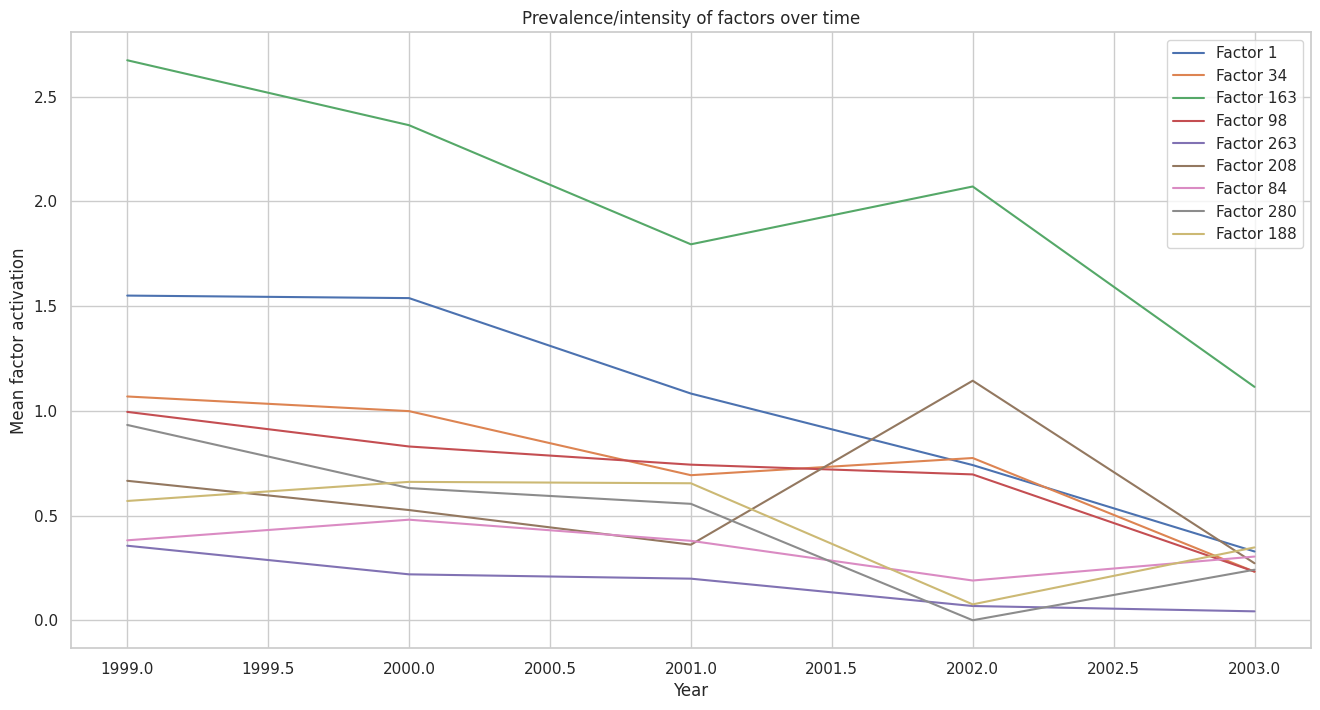

In [62]:
test_years_tcav = years_test[idx_test_tcav_eval]
with torch.no_grad():
    codes_train_tcav = model_sae.activation(model_sae.encoder(torch.tensor(
        test_emb_flat_norm[idx_test_tcav_eval].astype(np.float32)
    ))).numpy()

plt.figure(figsize=(16, 8))

for k in matched_factors:
    activ_by_year = pd.DataFrame({'year': test_years_tcav, 'activation': codes_train_tcav[:,k]})
    activ_mean = activ_by_year.groupby('year')['activation'].mean()
    plt.plot(activ_mean.index, activ_mean.values, label=f'Factor {k}')
plt.legend()
plt.xlabel('Year'); plt.ylabel('Mean factor activation')
plt.title('Prevalence/intensity of factors over time')
plt.savefig('sae_factors_over_time_enhanced.png', dpi=300)
plt.show()


TEMPORAL DRIFT ANALYSIS: PHENOTYPE STABILITY ACROSS TIME


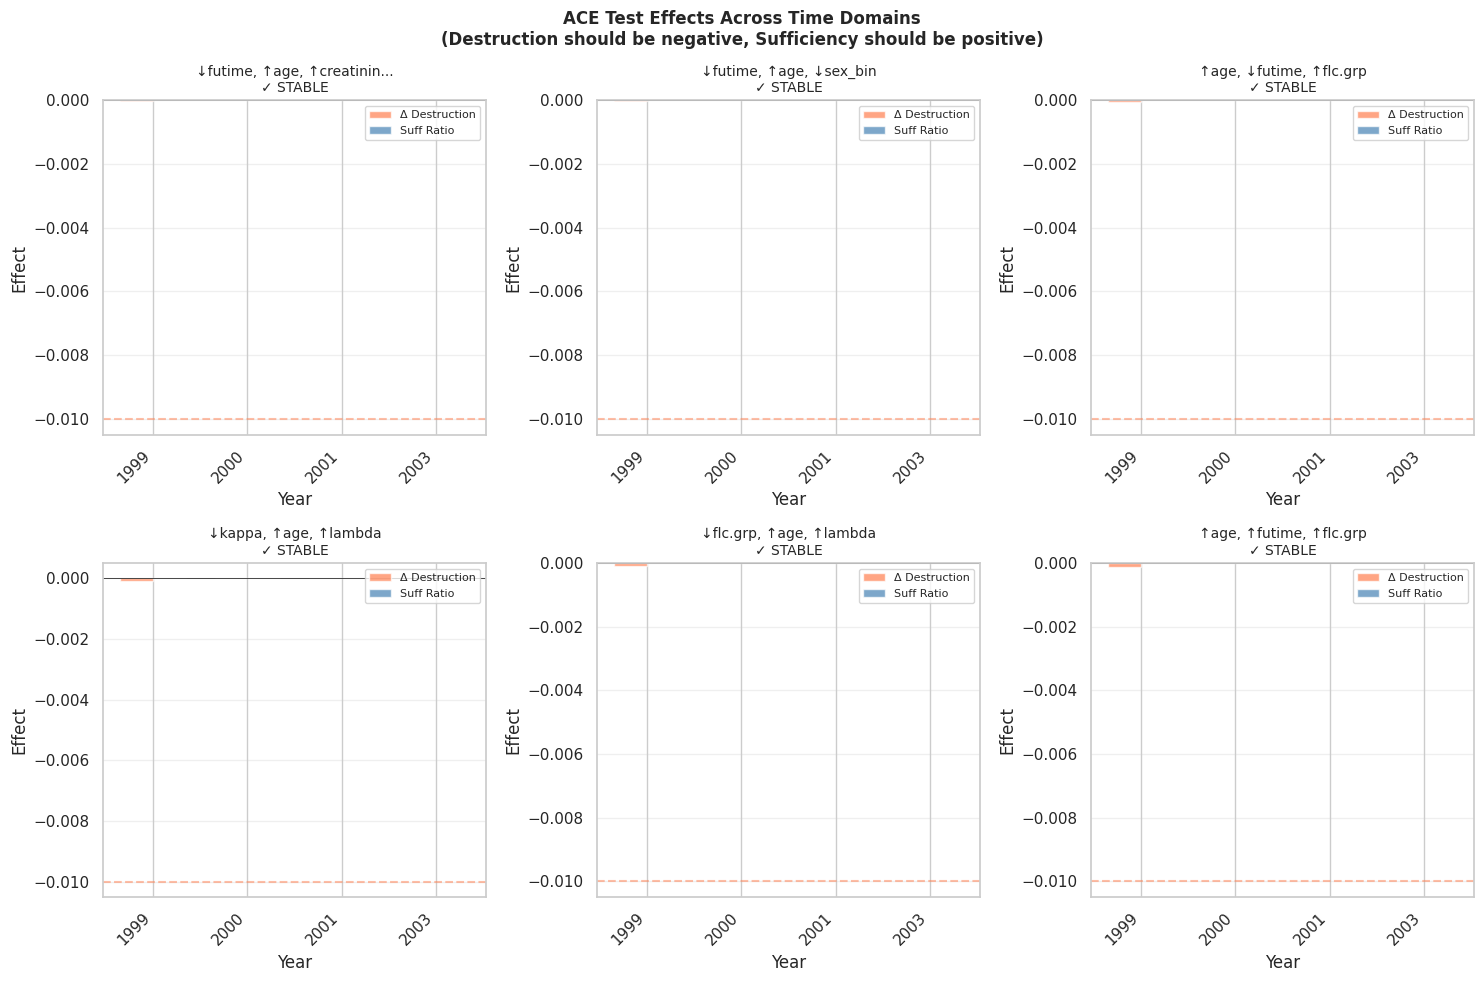


📊 DRIFT SENSITIVITY SUMMARY:
----------------------------------------------------------------------

✓ STABLE phenotypes (9): Consistent across time periods
    Concept 1: ↓futime, ↑age, ↑creatinine
    Concept 34: ↓futime, ↑age, ↓sex_bin
    Concept 163: ↑age, ↓futime, ↑flc.grp
    Concept 98: ↓kappa, ↑age, ↑lambda
    Concept 263: ↓flc.grp, ↑age, ↑lambda

⚠️ DRIFT-SENSITIVE phenotypes (0): Effect varies with time


In [63]:
print("="*70)
print("TEMPORAL DRIFT ANALYSIS: PHENOTYPE STABILITY ACROSS TIME")
print("="*70)

# Create domain-year mapping for better labels
domain_to_years = {v: k for k, v in year_to_domain_combined.items()}

# Select concepts with sufficient domain data
concepts_with_domain_data = [
    (cid, result) for cid, result in ace_results.items()
    if len(result.destruction_by_domain) >= 3
]

if len(concepts_with_domain_data) > 0:
    n_plots = min(6, len(concepts_with_domain_data))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (concept_id, result) in enumerate(concepts_with_domain_data[:n_plots]):
        ax = axes[idx]

        # Get domain-level destruction effects
        domains = sorted(result.destruction_by_domain.keys())
        destruction_values = [result.destruction_by_domain[d] for d in domains]
        sufficiency_values = [result.sufficiency_by_domain.get(d, 0) for d in domains]

        # Convert domains to years for labels
        years = [domain_to_years.get(d, f"D{d}") for d in domains]

        x = np.arange(len(domains))
        width = 0.35

        # Plot bars
        bars1 = ax.bar(x - width/2, destruction_values, width, label='Δ Destruction',
                       color='coral', alpha=0.7)
        bars2 = ax.bar(x + width/2, sufficiency_values, width, label='Suff Ratio',
                       color='steelblue', alpha=0.7)

        # Add reference lines
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
        ax.axhline(DESTRUCTION_THRESHOLD, color='coral', linestyle='--', alpha=0.5)

        # Formatting
        ax.set_xlabel('Year')
        ax.set_ylabel('Effect')

        # Get phenotype name
        phenotype = f"Concept {concept_id}"
        if 'report_df_sae' in dir():
            row = report_df_sae[report_df_sae['Concept'] == concept_id]
            if len(row) > 0:
                sig = row.iloc[0].get('Phenotype Signature', '')
                if sig != 'Not well-defined':
                    phenotype = sig[:25] + '...' if len(str(sig)) > 25 else sig

        drift_label = "⚠️ DRIFT" if result.is_drift_sensitive else "✓ STABLE"
        ax.set_title(f"{phenotype}\n{drift_label}", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45, ha='right')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    # Hide unused subplots
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('ACE Test Effects Across Time Domains\n(Destruction should be negative, Sufficiency should be positive)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Create drift summary
    print("\n📊 DRIFT SENSITIVITY SUMMARY:")
    print("-" * 70)

    drift_sensitive = [cid for cid, r in ace_results.items() if r.is_drift_sensitive]
    stable = [cid for cid, r in ace_results.items() if not r.is_drift_sensitive]

    print(f"\n✓ STABLE phenotypes ({len(stable)}): Consistent across time periods")
    for cid in stable[:5]:
        if 'report_df_sae' in dir():
            row = report_df_sae[report_df_sae['Concept'] == cid]
            if len(row) > 0:
                print(f"    Concept {cid}: {row.iloc[0].get('Phenotype Signature', 'N/A')[:40]}")

    print(f"\n⚠️ DRIFT-SENSITIVE phenotypes ({len(drift_sensitive)}): Effect varies with time")
    for cid in drift_sensitive[:5]:
        if 'report_df_sae' in dir():
            row = report_df_sae[report_df_sae['Concept'] == cid]
            if len(row) > 0:
                print(f"    Concept {cid}: {row.iloc[0].get('Phenotype Signature', 'N/A')[:40]}")

else:
    print("⚠️ Insufficient domain data for temporal analysis")
    print("  Need at least 3 time domains with sufficient samples")

### 3.9 Feature Values Variation Over Years (per factor)

In [64]:
# Lets create a new DF: for each matched cluster, we visualize the mean value of the top features (by the decision tree) per year
concepts_stats_per_year = []
for idx, row in matched_df.iterrows():
    factor_id = int(row['Factor'])
    rule_string = row["Path"]
    concept_acts = tcav_eval_concept_activations[:, factor_id]

    # Parse the rule
    conditions = parse_decision_tree_rule(rule_string)

    top_features = row['Top_features']
    features_on_conditions = [feat for (feat, op, thresh) in conditions]
    selected_features = []
    selected_importances = []
    for (feat, importance) in top_features:
        if feat in features_on_conditions:
            selected_features.append(feat)
            selected_importances.append(importance)

    idx_matched = tree_features_validation_results[factor_id]["idx_matched"]
    rows_on_df = X_held_out_eval_df.iloc[idx_matched]
    rows_on_df['year'] = test_years_held_out[idx_matched]

    for year in sorted(rows_on_df['year'].unique()):
        means = rows_on_df[(rows_on_df['year'] == year)][feature_cols].mean()
        row = {
            "factor": factor_id,
            "year": year,
            "n_samples": int(idx_matched.sum())
        }
        for k, v in means.items():
            row[f"mean_{k}"] = v

        concepts_stats_per_year.append(row)

df_concepts_stats_per_year = pd.DataFrame(concepts_stats_per_year)
display(df_concepts_stats_per_year)

/tmp/ipykernel_244188/2230908285.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_on_df['year'] = test_years_held_out[idx_matched]
/tmp/ipykernel_244188/2230908285.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_on_df['year'] = test_years_held_out[idx_matched]
/tmp/ipykernel_244188/2230908285.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

,factor,year,n_samples,mean_sex_bin,mean_age,mean_kappa,mean_lambda,mean_flc.grp,mean_creatinine,mean_mgus,mean_futime
0,1,1999,42,0.411765,58.235294,0.806824,1.081647,2.058824,1.058824,0.0,3517.823529
1,1,2000,42,0.333333,63.166667,0.881167,1.113000,2.333333,0.966667,0.0,2790.833333
2,1,2001,42,0.454545,63.454545,0.862091,0.911273,1.636364,1.036364,0.0,2299.363636
3,1,2002,42,0.333333,62.000000,0.985000,1.026333,2.333333,1.000000,0.0,2482.333333
4,1,2003,42,0.200000,52.000000,0.881600,1.062800,2.000000,1.280000,0.0,2235.400000
5,34,1999,33,0.400000,73.200000,3.343000,3.267000,9.600000,1.910000,0.0,2620.900000
6,34,2000,33,0.142857,77.571429,2.887143,3.122857,9.428571,1.157143,0.0,1911.428571
7,34,2001,33,0.375000,69.375000,2.723750,3.080000,9.375000,1.137500,0.0,2374.500000
8,34,2003,33,0.500000,67.000000,2.420000,2.590000,9.375000,1.100000,0.0,1952.625000
9,84,1999,41,0.615385,51.846154,1.272385,1.473692,5.000000,0.992308,0.0,3409.076923


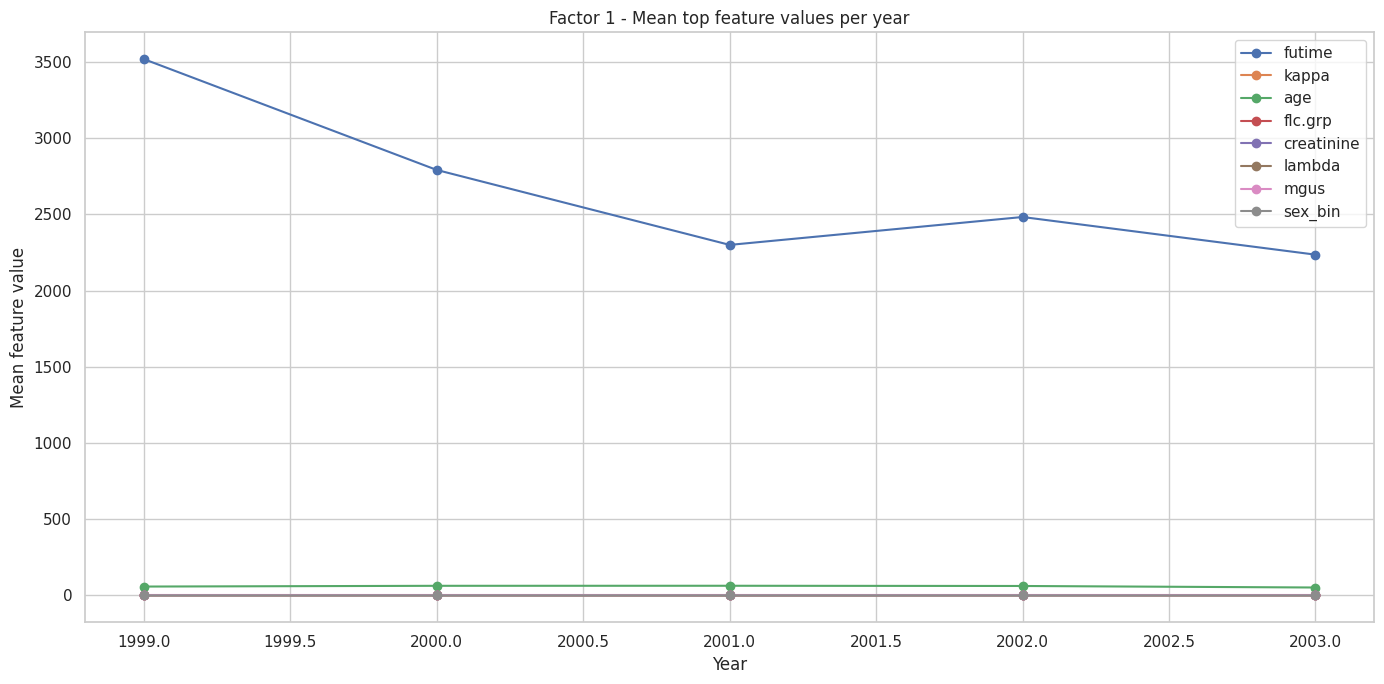

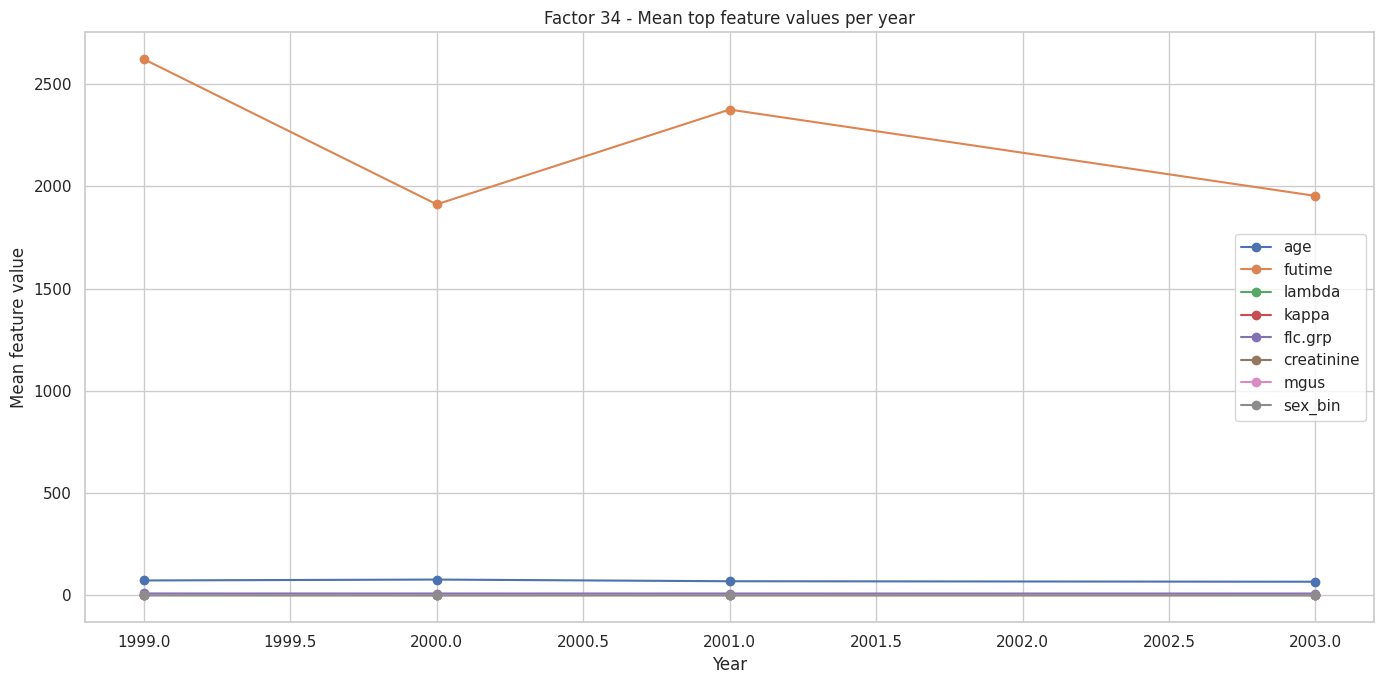

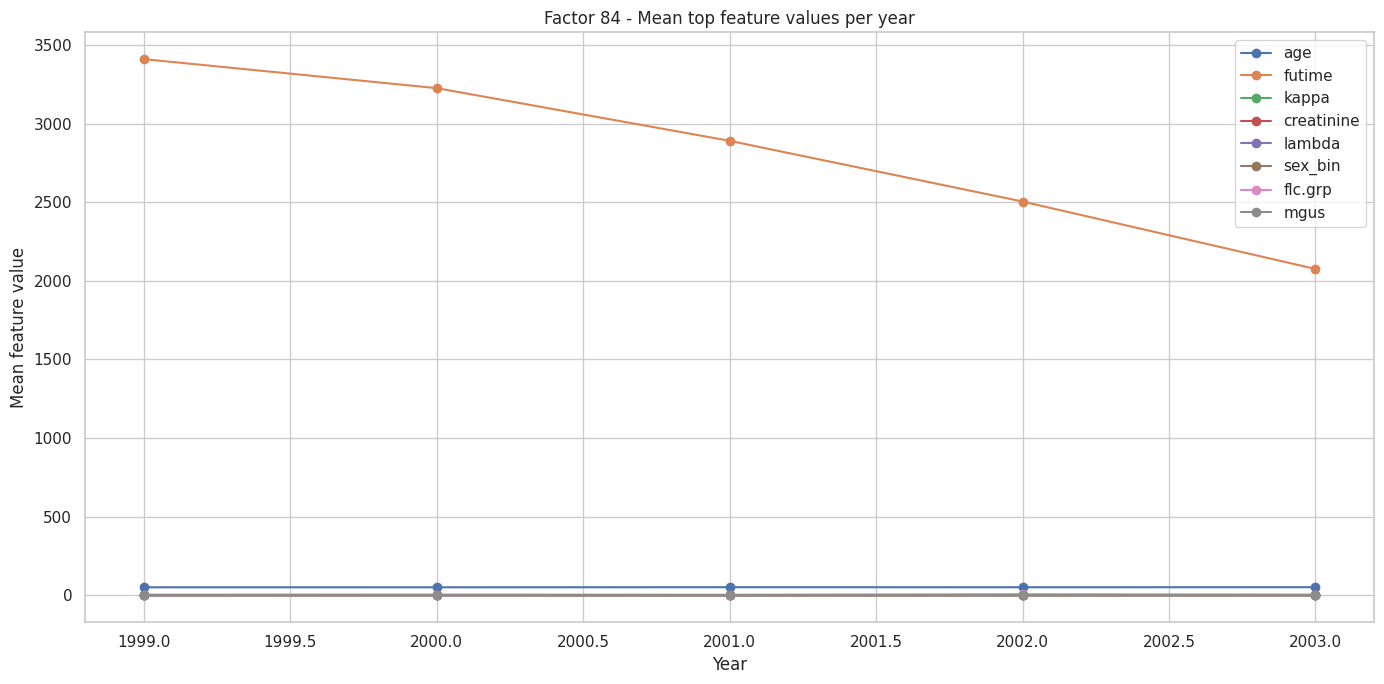

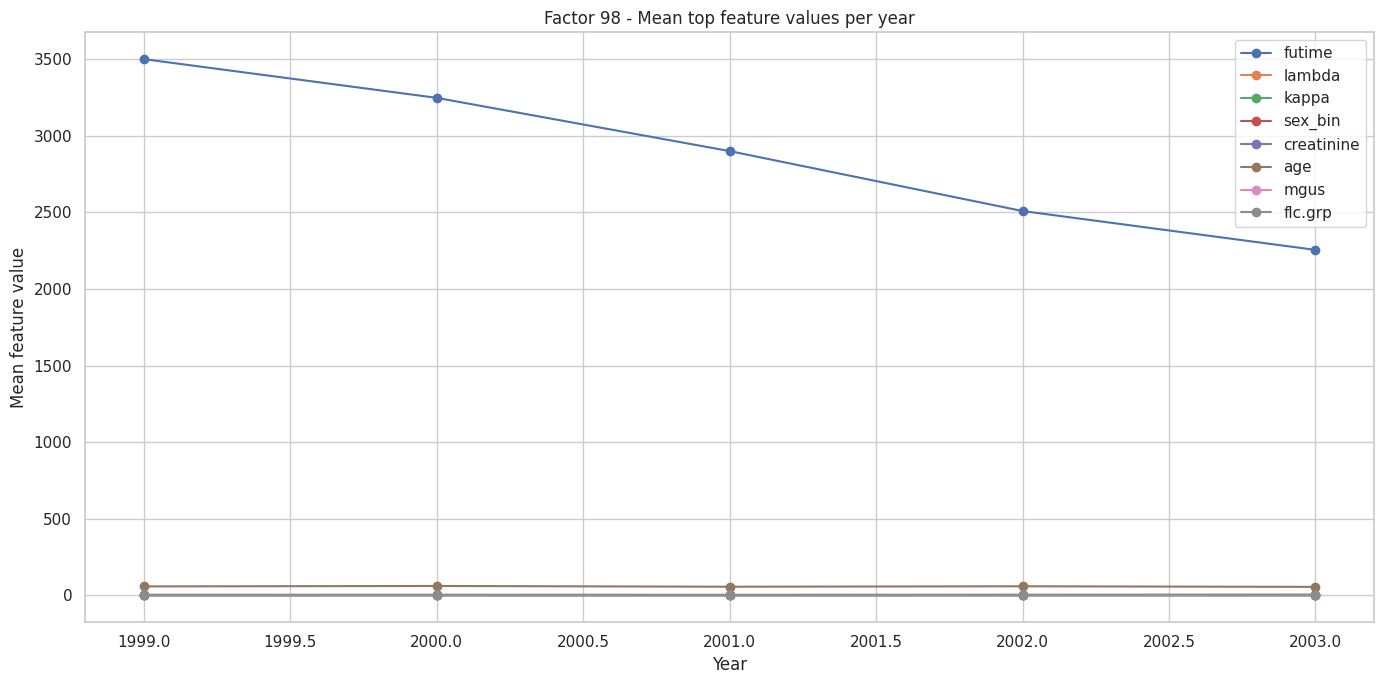

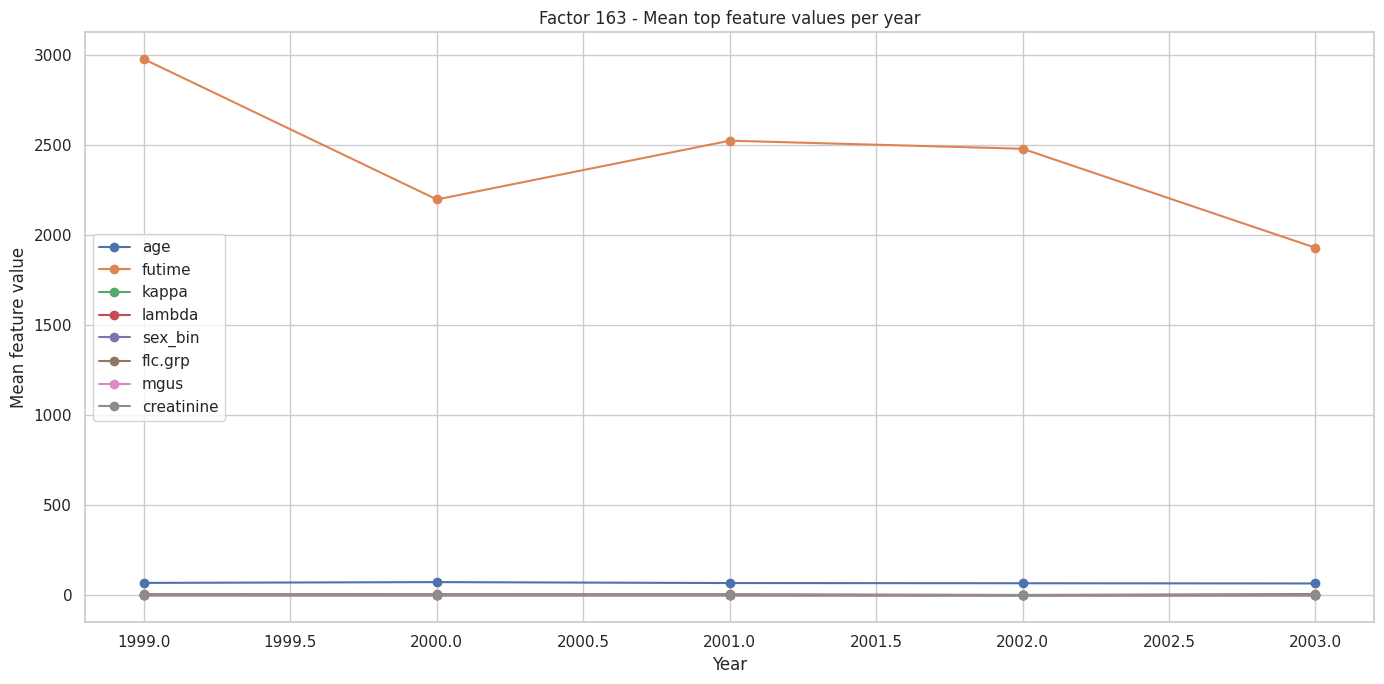

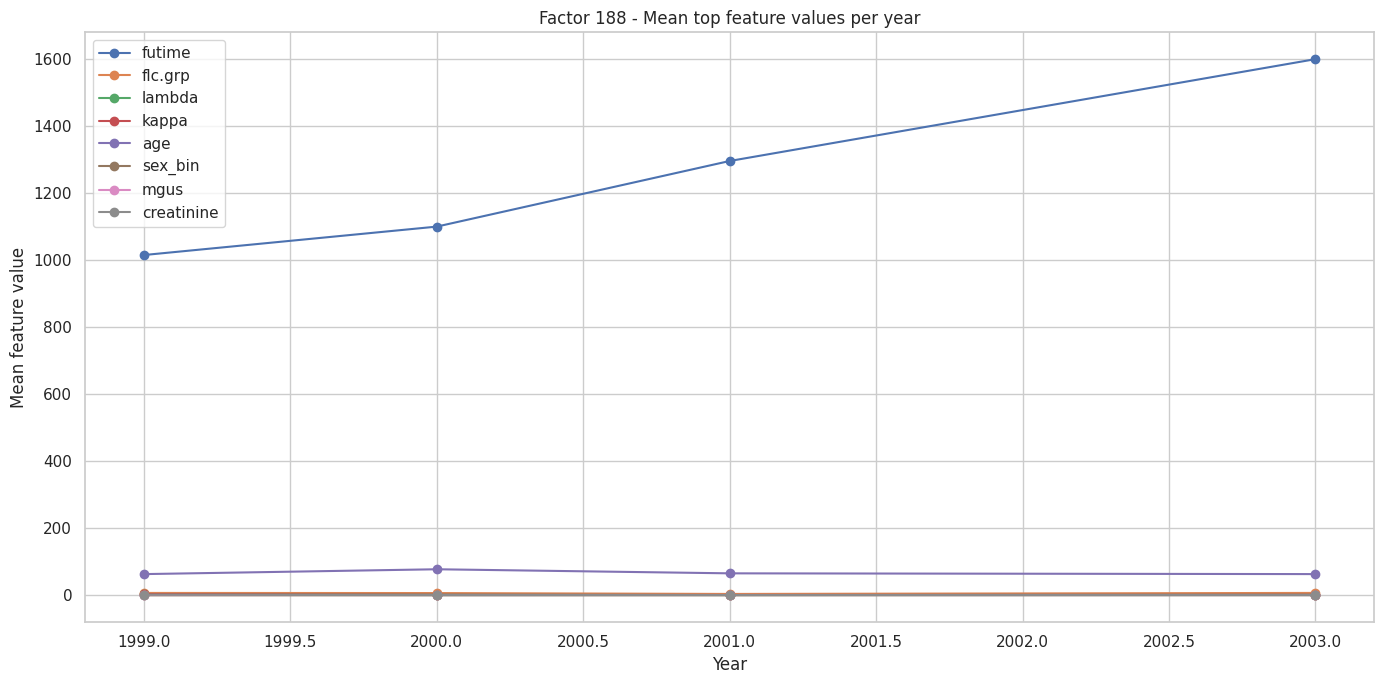

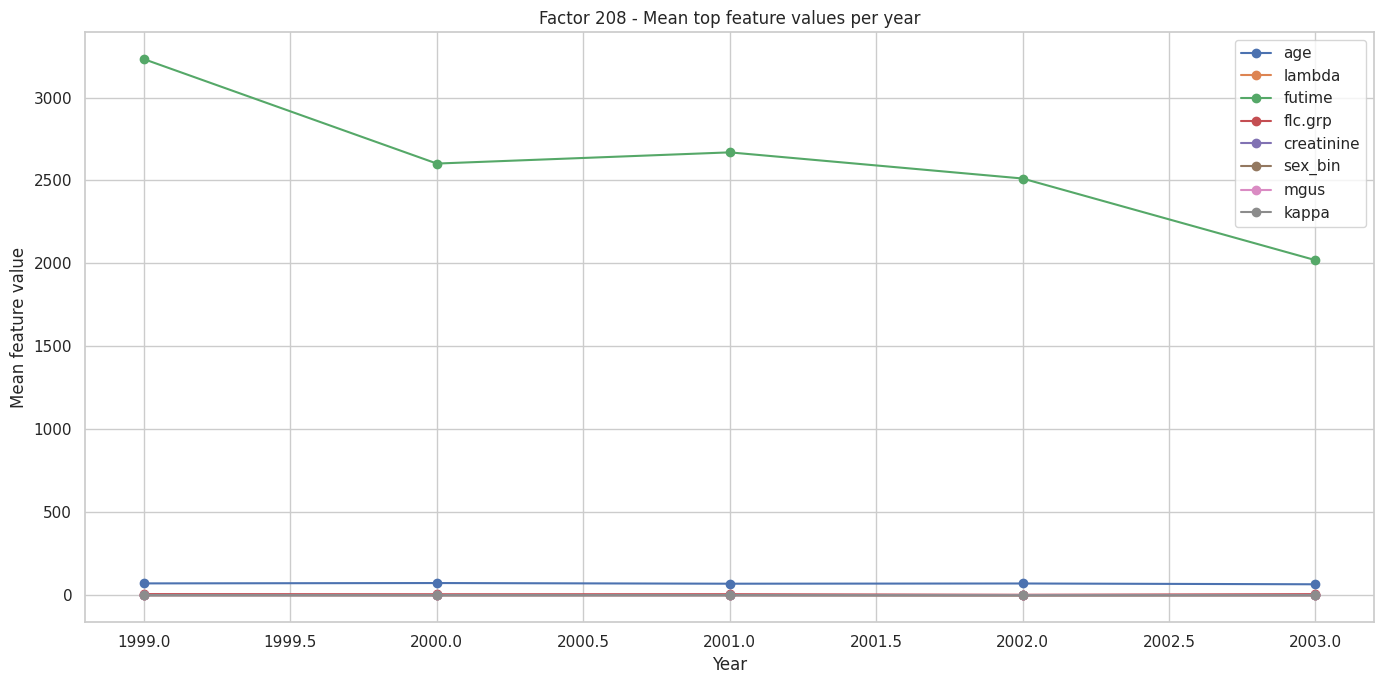

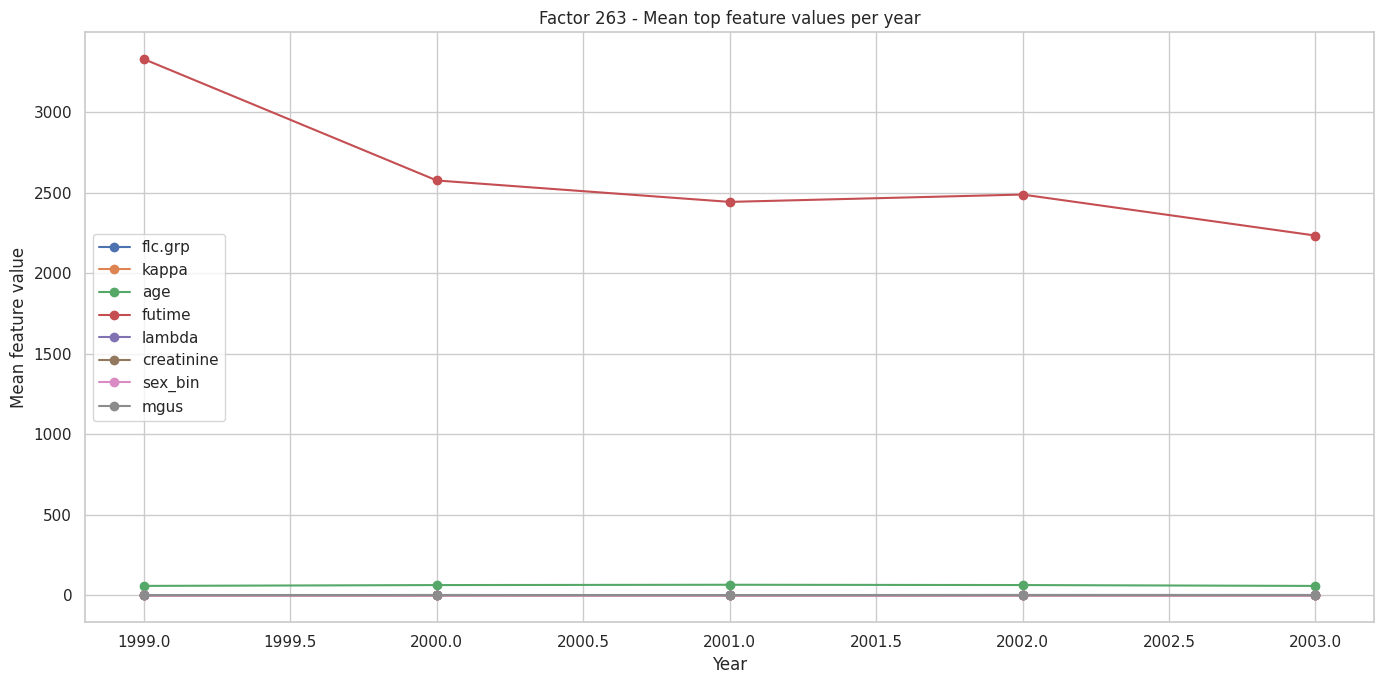

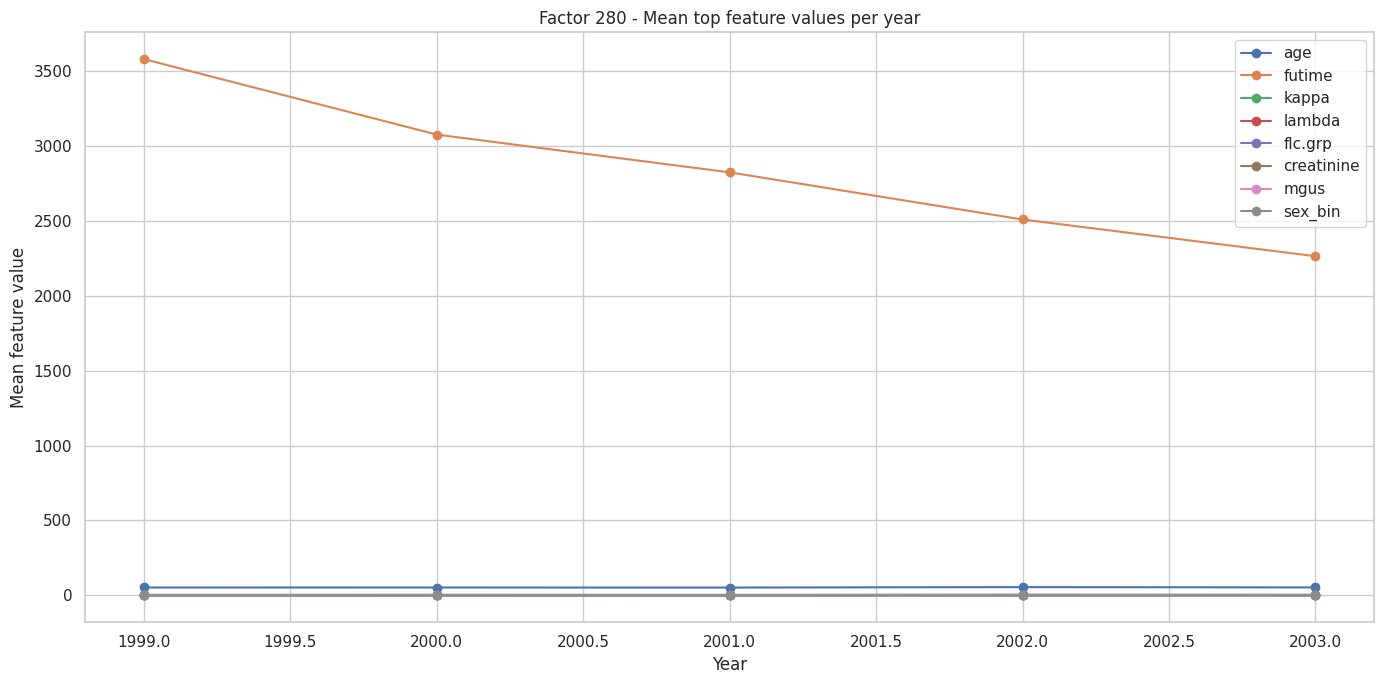

In [65]:
df_plot = df_concepts_stats_per_year.sort_values("year")

# Identify mean feature columns
mean_cols = [c for c in df_plot.columns if c.startswith("mean_")]
MEAN_FEATURE_VALUE_PER_YEAR_PER_SAE_FACTOR = RESULTS_DIR / \
    "mean_feature_value_per_year_per_sae_factor"
MEAN_FEATURE_VALUE_PER_YEAR_PER_SAE_FACTOR.mkdir(exist_ok=True)

for factor_id, df_factor in df_plot.groupby("factor"):
    plt.figure(figsize=(14, 7))
    top_features = matched_df[matched_df["Factor"]
                              == factor_id]['Top_features'].iloc[0]
    top_features_names = [feat for (feat, imp) in top_features]
    sr = sparse_readout_results_sae.get(factor_id, {})
    top_features_2 = sr.get('selected_features', [])[:10]

    for col in top_features_names:
        plt.plot(
            df_factor["year"],
            df_factor[f'mean_{col}'],
            marker="o",
            label=col.replace("mean_", "")
        )
    plt.xlabel("Year")
    plt.ylabel("Mean feature value")
    plt.title(f"Factor {factor_id} - Mean top feature values per year")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.10 TCAV Scores Bar Plot

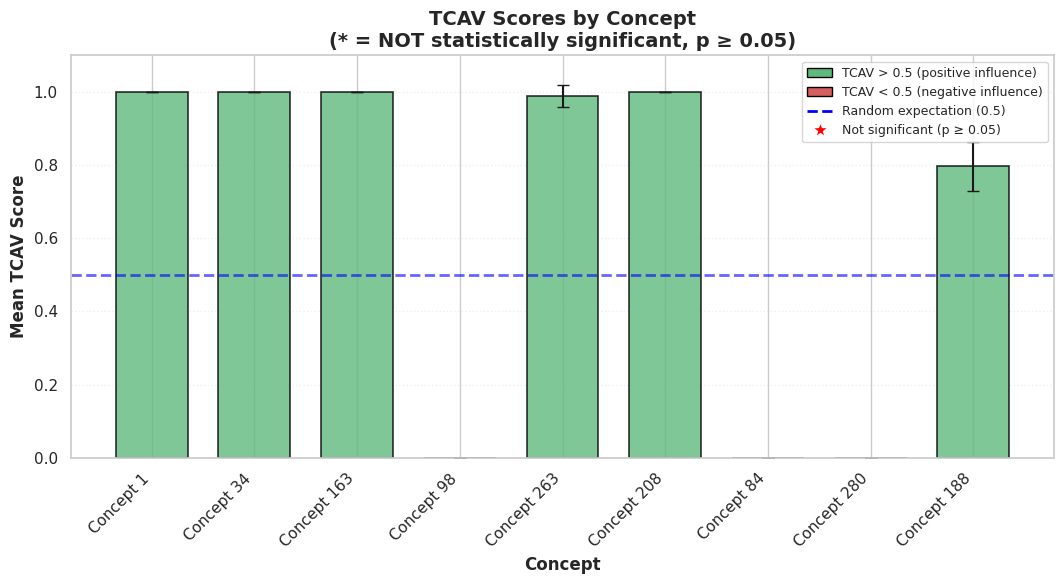


✓ Saved: matched_factors_tcav_barplot.png

Summary:
  Total concepts: 9


In [66]:
# Extract data from robust_tcav_results
mean_tcav_scores = [robust_tcav_results[cid]['mean_concept_tcav']
                    for cid in matched_factors]
std_tcav_scores = [robust_tcav_results[cid]['std_concept_tcav']
                   for cid in matched_factors]

# Create figure
fig, ax = plt.subplots(figsize=(max(8, len(matched_factors) * 1.2), 6))

# Bar positions
x_pos = np.arange(len(matched_factors))
bar_width = 0.7

# Color bars based on TCAV score (above/below 0.5)
colors = ['#5fba7d' if score >
          0.5 else '#d65f5f' for score in mean_tcav_scores]

# Create bars with error bars. Let's show only significant ones AND that have TCAV - 0.5 > 0.1
bars = ax.bar(x_pos, mean_tcav_scores, bar_width,
              yerr=std_tcav_scores, capsize=4,
              color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

# Add reference line at 0.5 (random expectation)
ax.axhline(0.5, color='blue', linestyle='--', linewidth=2,
           alpha=0.6, label='Random expectation (0.5)')

# Customize axes
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f'Concept {cid}' for cid in matched_factors], rotation=45, ha='right')
ax.set_xlabel('Concept', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean TCAV Score', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)

# Add title
ax.set_title('TCAV Scores by Concept\n(* = NOT statistically significant, p ≥ 0.05)',
             fontsize=14, fontweight='bold')

# Add legend
legend_elements = [
    Patch(facecolor='#5fba7d', edgecolor='black',
          label='TCAV > 0.5 (positive influence)'),
    Patch(facecolor='#d65f5f', edgecolor='black',
          label='TCAV < 0.5 (negative influence)'),
    plt.Line2D([0], [0], color='blue', linestyle='--',
               linewidth=2, label='Random expectation (0.5)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12,
               label='Not significant (p ≥ 0.05)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

# Add grid
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/matched_factors_tcav_barplot_def.png",
            dpi=150, bbox_inches='tight')
plt.show()


print(f"\n✓ Saved: matched_factors_tcav_barplot.png")
print(f"\nSummary:")
print(f"  Total concepts: {len(matched_factors)}")